# Great Lakes Basin MODFLOW 6 — Organized workflow

This version is reorganized so that the notebook runs in a clear dependency order:

1. imports and user settings  
2. helper functions only  
3. template grid and aligned rasters  
4. arrays and final model layers  
5. CHD, GHB, DRN, recharge  
6. build and run MODFLOW 6  
7. optional post-processing

Main cleanup changes:
- removed executable GHB/NLDAS code from the helper section
- moved CHD and STRT checks after CHD actually exists
- added a single place for `perioddata_run`, `months_run`, and `model_months`
- grouped optional diagnostics and post-processing at the end


## 0) Imports

In [1]:
import os
import gc
import time
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"  # helps reading NetCDF/HDF5 from network drives on Windows
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="pyogrio")
warnings.filterwarnings("ignore", category=DeprecationWarning)
from pathlib import Path
import re, glob, shutil, tempfile, calendar

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio as rio
from rasterio.transform import from_origin, from_bounds
from rasterio.features import rasterize
from rasterio.warp import reproject, Resampling
import shapely.geos
from shapely.geometry import MultiLineString
import matplotlib.pyplot as plt
import matplotlib as mpl
from rasterio.crs import CRS
import flopy
from flopy.utils.gridintersect import GridIntersect

import xarray as xr

print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {mpl.__version__}")
print(f"flopy version: {flopy.__version__}")

numpy version: 2.3.5
matplotlib version: 3.10.8
flopy version: 3.10.0


## 1) User settings

In [2]:
# --- Model identity ---
nameSim   = "Greatlakes"
nameModel = "Testing_6"  # MF6 model name; package files will be Testing.dis, Testing.rch, etc.

# --- MF6 executable ---
bindir = Path(r"D:\Users\abolmaal\modelling\Modflow\helper")
exe_path = str((bindir / "mf6.exe").resolve())

# --- Simulation workspace (will be RECREATED) ---
dirModelFilesBase = r"D:\Users\abolmaal\modelling\Modflow"
sim_ws = str(Path(dirModelFilesBase) / nameModel)

# --- Boundary polygon (truth) ---
boundary_shp = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Ibound\extended_Bdry_final_GLB_Albers_exported.shp"

IBOUND = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Ibound\Idomain_mask_30m.tif"
# --- Raw rasters (any CRS/resolution; we will warp to template) ---
nameInputTop       = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\DEM\DEM_extended20kmbdr_1000m.tif"

nameInputLayBot    = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Bottom\modelbottom.tif"

nameInputHorizCond = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HK_5band_1000m.tif"


# this is the actual starting head raster
nameInputStrt     = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Wells\starting_heads_clamped_1000m.tif"

#this is your lake/land mask, NOT starting heads
#nameInputMask   = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\domain_water_mask_30m_buff2000m.tif"

# --- CHD / DRN vector inputs ---
pathInputConstHead      = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\CHD_cells_points_dem.shp"
fieldInputConstHeadElev = "head"

# -- GHB ---
OUT_GHB_TABLE = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes_GHB_cells.csv"
OUT_STAGE_TABLE = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes_stage_monthly_for_model.csv"

LAKES_SHP = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes.shp"


# pathInputDrn = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\NHD\streams_3174_clip_to_modelgrid.shp"
# fieldInputDrnWidth = "WIDTH_M"
USE_DRN = True
USE_WETLAND_DRN = False   # separate wetland DRN no longer needed

nameInputDrainElev = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Drains\drain_elevation.tif"
drain_elev_aligned = os.path.join(sim_ws, "drain_elevation_aligned.tif")
drain_presence_raw = os.path.join(sim_ws, "drain_presence_raw.tif")
drain_frac_aligned = os.path.join(sim_ws, "drain_fraction_aligned.tif")


DRN_K_DIVISOR = 1.0       # use 1.0 if you want exactly Kcell
# DRN_K_DIVISOR = 10.0    # use this instead if you want Kcell/10 for vertical leakage

DRN_MIN_THICK = 0.1       # minimum cell thickness used in conductance
DRN_MIN_AREA_FRAC = 0.01  # skip tiny drain fractions
DRN_COND_MULT = 1.0
DRN_ELEV_EPS = 0.01       # keep drain elevation slightly inside the cell

# --- NLDAS monthly Noah (NetCDF) ---
nldas_root = Path(r"T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_2_monthly\NOAH_VIC_average\NLDAS\NLDAS_NOAHVIC_M.2.0")
NLDAS_VAR  = "Qsb"

# --- Model grid definition ---
CELL = 1000       # meters (try 2000 or 1000 later)
EPSG = 3174       # NAD_1983_Great_Lakes_Basin_Albers

# --- Outputs (template + warped rasters) ---
GRID_DIR    = Path(r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\GRID_3174")
ALIGNED_DIR = Path(r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\ALIGNED_3174")
GRID_DIR.mkdir(parents=True, exist_ok=True)
ALIGNED_DIR.mkdir(parents=True, exist_ok=True)

template_tif = str(GRID_DIR / f"template_{CELL}m_epsg{EPSG}.tif")
idomain_tif  = str(GRID_DIR / f"idomain_{CELL}m_epsg{EPSG}.tif")

top_aligned   = str(ALIGNED_DIR / f"TOP_{CELL}m.tif")
botm_aligned  = str(ALIGNED_DIR / f"BOTM_{CELL}m.tif")
hk_aligned    = str(ALIGNED_DIR / f"HK_{CELL}m.tif")
mask_aligned  = str(ALIGNED_DIR / f"MASK_{CELL}m.tif")
strt_aligned  = str(ALIGNED_DIR / f"STRT_{CELL}m.tif")
Ibound_aligned = str(ALIGNED_DIR / f"IBOUND_{CELL}m.tif")

# --- Streams source for DRN build ---
gdb_path = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\NHD\streams_tmp.gdb"
layer_name = "streams_3174"   # change if your FileGDB layer name differs

# --- Time controls ---
START_DATE = "2020-01-01"
END_DATE   = "2023-12-01"

NPER_TEST =13          # set None for full run
USE_FIVE_LAYER_MODEL = True
FORCE_CONSTANT_CHD = False
LAKE_STAGE = 100.0
USE_GHB = True
USE_DRN = True

# =========================================================
# WETLAND DRN SETTINGS
# =========================================================
# USE_WETLAND_DRN = True

# WETLANDS_SHP = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Wetlands\Wetlands_GL_NoLakes.shp"

# WETLAND_TSED_M = 1.0
# WETLAND_KV_DIVISOR = 10.0
# WETLAND_DEPTH_BELOW_LAND_M = 0.1

# Figure_dir 
fig_dir = r"D:\Users\abolmaal\modelling\Figs\testing6"

## 2) Helper functions

In [3]:

def snap_bounds_to_cell(bounds, cell):
    xmin, ymin, xmax, ymax = bounds
    xmin = np.floor(xmin / cell) * cell
    ymin = np.floor(ymin / cell) * cell
    xmax = np.ceil(xmax / cell) * cell
    ymax = np.ceil(ymax / cell) * cell
    return float(xmin), float(ymin), float(xmax), float(ymax)

def build_model_months(start_date, nper):
    return pd.date_range(start=start_date, periods=nper, freq="MS")

def build_monthly_perioddata(start="2000-01-01", end="2025-12-01", nstp=1, tsmult=1.0):
    months = pd.date_range(start=start, end=end, freq="MS")
    pddata = []
    for d in months:
        ndays = calendar.monthrange(d.year, d.month)[1]
        pddata.append((float(ndays), int(nstp), float(tsmult)))
    return pddata, months

def make_template_from_boundary(boundary_shp, out_template_tif, cellsize):
    gdf = gpd.read_file(boundary_shp)

    if gdf.crs is None:
        raise ValueError(f"Boundary file has no CRS: {boundary_shp}")

    xmin, ymin, xmax, ymax = snap_bounds_to_cell(gdf.total_bounds, cellsize)

    width = int(round((xmax - xmin) / cellsize))
    height = int(round((ymax - ymin) / cellsize))

    from rasterio.transform import from_origin
    transform = from_origin(xmin, ymax, cellsize, cellsize)

    profile = {
        "driver": "GTiff",
        "height": height,
        "width": width,
        "count": 1,
        "dtype": "int16",
        "transform": transform,
        "nodata": 0,
        "compress": "deflate",
        "tiled": True,
        "BIGTIFF": "YES",
    }

    if os.path.exists(out_template_tif):
        try:
            os.remove(out_template_tif)
        except PermissionError:
            print("Could not delete locked file:", out_template_tif)

    with rio.open(out_template_tif, "w", **profile) as dst:
        import numpy as np
        dst.write(np.zeros((height, width), dtype=np.int16), 1)

    return out_template_tif


def rasterize_idomain(boundary_shp, template_tif, out_idomain_tif, burn_value=1, all_touched=False):
    """
    Rasterize boundary directly onto template grid.
    Assumes boundary_shp is already in the same CRS as the intended grid.
    """
    gdf = gpd.read_file(boundary_shp)

    if gdf.crs is None:
        raise ValueError(f"Boundary file has no CRS: {boundary_shp}")

    with rio.open(template_tif) as tmp:
        arr = rasterize(
            shapes=[(geom, burn_value) for geom in gdf.geometry if geom is not None and not geom.is_empty],
            out_shape=(tmp.height, tmp.width),
            transform=tmp.transform,
            fill=0,
            dtype="int32",
            all_touched=all_touched
        )

        profile = tmp.profile.copy()
        profile.update(
            driver="GTiff",
            dtype="int32",
            count=1,
            nodata=0,
            compress="deflate",
            tiled=True,
            BIGTIFF="YES"
        )

        # optional: strip fields that sometimes cause trouble when copied through
        profile.pop("blockxsize", None)
        profile.pop("blockysize", None)

    if os.path.exists(out_idomain_tif):
        try:
            os.remove(out_idomain_tif)
        except PermissionError:
            print("Could not delete locked file:", out_idomain_tif)

    with rio.open(out_idomain_tif, "w", **profile) as dst:
        dst.write(arr, 1)

    return out_idomain_tif

def assert_match_template_no_crs(raster_tif, template_tif, name="Raster"):
    """
    Check shape and transform only. Skip CRS because Rasterio cannot
    reliably read CRS in the current environment.
    """
    with rio.open(raster_tif) as a, rio.open(template_tif) as b:
        if (a.height, a.width) != (b.height, b.width):
            raise AssertionError(
                f"{name} shape mismatch: {(a.height, a.width)} vs {(b.height, b.width)}"
            )
        if a.transform != b.transform:
            raise AssertionError(
                f"{name} transform mismatch:\n{a.transform}\nvs\n{b.transform}"
            )
    print(f"{name} matches template in shape and transform.")




def warp_raster_to_template(src_path, template_path, out_path, resampling, dst_nodata=-9999.0):
    with rio.open(template_path) as tmpl, rio.open(src_path) as src:
        dst_meta = src.meta.copy()
        dst_meta.update(
            driver="GTiff",
            crs=tmpl.crs,
            transform=tmpl.transform,
            width=tmpl.width,
            height=tmpl.height,
            nodata=dst_nodata,
            compress="deflate",
            tiled=True,
            BIGTIFF="YES",
            blockxsize=256,
            blockysize=256,
        )
        with rio.open(out_path, "w", **dst_meta) as dst:
            for b in range(1, src.count + 1):
                reproject(
                    source=rio.band(src, b),
                    destination=rio.band(dst, b),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    src_nodata=src.nodata,
                    dst_transform=tmpl.transform,
                    dst_crs=tmpl.crs,
                    dst_nodata=dst_nodata,
                    resampling=resampling,
                )
    return out_path

def assert_match_template(path, template_path, name):
    with rio.open(template_path) as t, rio.open(path) as s:
        assert (s.height, s.width) == (t.height, t.width), f"{name} shape mismatch"
        assert s.crs == t.crs, f"{name} CRS mismatch"
        assert s.transform == t.transform, f"{name} transform mismatch"

def read_band1(path, dtype="float32"):
    with rio.open(path) as src:
        return src.read(1).astype(dtype, copy=False), src.nodata

def read_all_bands(path, dtype="float32"):
    with rio.open(path) as src:
        return src.read().astype(dtype, copy=False), src.nodata

def clean_continuous(a, nodata, fill=0.0):
    a = a.astype("float32", copy=False)
    a = np.nan_to_num(a, nan=fill, posinf=fill, neginf=fill)
    if nodata is not None:
        a = np.where(a == nodata, fill, a)
    return a

def make_gridintersect(modelgrid):
    try:
        return GridIntersect(modelgrid, method="vertex")
    except TypeError:
        try:
            return GridIntersect(modelgrid, "vertex")
        except TypeError:
            return GridIntersect(modelgrid)

def update_ghb_k_from_idomain(ghb_cells_df, idomain):
    """
    Update GHB layer k so each boundary cell is assigned to the first active layer
    at its (i, j) location based on the final DIS idomain.
    """
    df = ghb_cells_df.copy()

    if {"i", "j"}.issubset(df.columns):
        i_col, j_col = "i", "j"
    elif {"row", "col"}.issubset(df.columns):
        i_col, j_col = "row", "col"
        if "i" not in df.columns:
            df["i"] = df["row"]
        if "j" not in df.columns:
            df["j"] = df["col"]
    else:
        raise ValueError("ghb_cells_df must contain either (i, j) or (row, col) columns.")

    if idomain.ndim == 2:
        active = idomain > 0
        keep_idx = []
        new_k = []
        for idx, r in enumerate(df.itertuples(index=False)):
            i = int(getattr(r, i_col))
            j = int(getattr(r, j_col))
            if 0 <= i < active.shape[0] and 0 <= j < active.shape[1] and active[i, j]:
                keep_idx.append(idx)
                new_k.append(0)
        df = df.iloc[keep_idx].copy()
        df["k"] = new_k
        return df.reset_index(drop=True)

    if idomain.ndim == 3:
        nlay, nrow, ncol = idomain.shape
        keep_idx = []
        new_k = []
        for idx, r in enumerate(df.itertuples(index=False)):
            i = int(getattr(r, i_col))
            j = int(getattr(r, j_col))
            if not (0 <= i < nrow and 0 <= j < ncol):
                continue
            active_layers = np.where(idomain[:, i, j] > 0)[0]
            if len(active_layers) == 0:
                continue
            keep_idx.append(idx)
            new_k.append(int(active_layers[0]))
        df = df.iloc[keep_idx].copy()
        df["k"] = new_k
        return df.reset_index(drop=True)

    raise ValueError(f"idomain must be 2D or 3D, got shape {idomain.shape}")

def assign_ghb_k_from_stage_floor(ghb_cells_df, idomain, botm3d, stage_floor_by_name, stage_margin=0.05):
    """
    Choose the shallowest active layer whose bottom is below the minimum
    stage for that lake/stage_name.

    Parameters
    ----------
    ghb_cells_df : DataFrame
        Must contain stage_name, i, j
    idomain : ndarray
        3D array (nlay, nrow, ncol)
    botm3d : ndarray
        3D bottom array (nlay, nrow, ncol)
    stage_floor_by_name : pandas Series or dict
        Minimum stage for each stage_name across the modeled period
    stage_margin : float
        Small safety margin so stage > bottom + margin
    """
    if idomain.ndim != 3:
        raise ValueError("assign_ghb_k_from_stage_floor expects 3D idomain")

    df = ghb_cells_df.copy()
    keep_rows = []
    new_k = []
    dropped = []

    nlay, nrow, ncol = idomain.shape

    for idx, r in enumerate(df.itertuples(index=False)):
        i = int(r.i)
        j = int(r.j)
        sname = str(r.stage_name)

        if sname not in stage_floor_by_name:
            dropped.append((idx, "missing_stage_name"))
            continue

        if not (0 <= i < nrow and 0 <= j < ncol):
            dropped.append((idx, "out_of_bounds"))
            continue

        stage_floor = float(stage_floor_by_name[sname])

        active_layers = np.where(idomain[:, i, j] > 0)[0]
        if len(active_layers) == 0:
            dropped.append((idx, "no_active_layers"))
            continue

        valid_layers = [
            int(k) for k in active_layers
            if float(botm3d[k, i, j]) < (stage_floor - stage_margin)
        ]

        if len(valid_layers) == 0:
            dropped.append((idx, "no_layer_below_stage"))
            continue

        keep_rows.append(idx)
        new_k.append(valid_layers[0])   # shallowest valid layer

    out = df.iloc[keep_rows].copy().reset_index(drop=True)
    out["k"] = new_k

    print("GHB cells kept after stage-aware layer assignment:", len(out))
    print("GHB cells dropped:", len(dropped))
    if len(dropped) > 0:
        print(pd.Series([d[1] for d in dropped]).value_counts())

    return out


# ---- NLDAS indexing ----
def index_blend_qsb_monthlies(root: Path):
    files = sorted(root.rglob("BLEND_Qsb_A*.nc"))
    rows = []
    for f in files:
        m = re.search(r"_A(\d{6})\.nc$", f.name)
        if not m:
            continue
        yyyymm = m.group(1)
        dt = pd.Timestamp(int(yyyymm[:4]), int(yyyymm[4:6]), 1)
        rows.append((dt, str(f)))
    df = pd.DataFrame(rows, columns=["date", "path"]).sort_values("date").reset_index(drop=True)
    return df

def copy_to_local_cached(src_path: str) -> str:
    src = Path(src_path)
    cache_dir = Path(tempfile.gettempdir()) / "nldas_nc_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    dst = cache_dir / src.name
    if (not dst.exists()) or (dst.stat().st_size != src.stat().st_size) or (dst.stat().st_mtime < src.stat().st_mtime):
        shutil.copy2(src, dst)
    return str(dst)

def read_qsb_lat_lon_attrs(nc_path: str, var="Qsb"):
    local_path = copy_to_local_cached(nc_path)

    last_err = None
    for engine in ("h5netcdf", "netcdf4"):
        try:
            ds = xr.open_dataset(local_path, engine=engine, decode_times=False)
            da = ds[var]
            if "time" in da.dims:
                da = da.isel(time=0)

            units = (da.attrs.get("units") or "").strip()
            cell_methods = (da.attrs.get("cell_methods") or "").strip()

            qsb = da.values.astype("float32")
            lat = da["lat"].values
            lon = da["lon"].values
            ds.close()
            return qsb, lat, lon, units, cell_methods
        except Exception as e:
            last_err = e

    raise RuntimeError(f"Failed to read {nc_path}. Last error: {last_err}")

def parse_yyyymm_from_filename(fname: str):
    base = Path(fname).name
    m = re.search(r"\.A(\d{6})\.", base)
    if not m:
        m = re.search(r"_A(\d{6})\.nc$", base)
    if not m:
        raise ValueError(f"Cannot parse YYYYMM from {fname}")
    yyyymm = m.group(1)
    return int(yyyymm[:4]), int(yyyymm[4:6])

def qsb_month_to_rech_mday_on_template(
    nc_path: str,
    template_tif: str,
    var: str = "Qsb",
    id2d: np.ndarray | None = None,
    clamp_negative_to_zero: bool = True,
    src_crs: str = "EPSG:4326",
    resampling=Resampling.average,
):
    qsb, lat, lon, units, cell_methods = read_qsb_lat_lon_attrs(nc_path, var=var)

    if lat[0] < lat[-1]:
        lat = lat[::-1]
        qsb = qsb[::-1, :]

    dx = float(np.abs(lon[1] - lon[0]))
    dy = float(np.abs(lat[0] - lat[1]))
    left   = float(lon.min() - dx / 2)
    right  = float(lon.max() + dx / 2)
    bottom = float(lat.min() - dy / 2)
    top    = float(lat.max() + dy / 2)
    src_transform = from_bounds(left, bottom, right, top, qsb.shape[1], qsb.shape[0])

    y, mo = parse_yyyymm_from_filename(nc_path)
    days = calendar.monthrange(y, mo)[1]

    qsb = np.nan_to_num(qsb, nan=0.0, posinf=0.0, neginf=0.0).astype("float32")
    if clamp_negative_to_zero:
        qsb = np.maximum(qsb, 0.0)

    u = (units or "").lower().replace(" ", "")
    cm = (cell_methods or "").lower().replace(" ", "")

    if ("kgm-2" in u or "kg/m2" in u or "kgm^-2" in u) and ("time:sum" in cm or "sum" in cm):
        rech_src = (qsb / 1000.0) / float(days)
    elif ("s-1" in u) or ("/s" in u) or ("kgm-2s-1" in u) or ("kg/m2/s" in u):
        rech_src = qsb * 86400.0 / 1000.0
    else:
        rech_src = (qsb / 1000.0) / float(days)

    with rio.open(template_tif) as tmp:
        dst = np.zeros((tmp.height, tmp.width), dtype="float32")
        reproject(
            source=rech_src,
            destination=dst,
            src_transform=src_transform,
            src_crs=src_crs,
            dst_transform=tmp.transform,
            dst_crs=tmp.crs,
            resampling=resampling,
            dst_nodata=0.0,
        )

    dst = np.nan_to_num(dst, nan=0.0, posinf=0.0, neginf=0.0).astype("float32")
    dst[dst < 0] = 0.0
    if id2d is not None:
        dst[id2d == 0] = 0.0

    return dst

def build_rch_spd_from_index(
    df_nc,                  # columns ["date", "path"]
    months_run,             # DatetimeIndex of model months
    template_tif: str,
    id2d=None,
    var: str = "Qsb",
):
    """
    Returns:
      rch_spd : dict {per:int -> 2D float32 array (m/day)}
    """

    # normalize all file dates to month-start
    path_by_month = {
        pd.Timestamp(d).to_period("M").to_timestamp(how="start"): p
        for d, p in zip(df_nc["date"], df_nc["path"])
    }

    rch_spd = {}
    for per, d in enumerate(months_run):
        d0 = pd.Timestamp(d).to_period("M").to_timestamp(how="start")
        nc_path = path_by_month.get(d0, None)

        if nc_path is None:
            with rio.open(template_tif) as tmp:
                rch_spd[per] = np.zeros((tmp.height, tmp.width), dtype="float32")
            continue

        rch_spd[per] = qsb_month_to_rech_mday_on_template(
            nc_path=nc_path,
            template_tif=template_tif,
            var=var,
            id2d=id2d,
        )

    return rch_spd

def intersect_grid_feature(ix, pathFeature, lay=0, addFields=None, grid_crs=None):
    addFields = addFields or []
    try:
        gdf = gpd.read_file(pathFeature, engine="fiona")
    except Exception:
        gdf = gpd.read_file(pathFeature)
        
    if gdf.empty:
        return pd.DataFrame()

    if grid_crs is not None and gdf.crs is not None and gdf.crs != grid_crs:
        gdf = gdf.to_crs(grid_crs)

    try:
        gdf = gdf.explode(index_parts=False).reset_index(drop=True)
    except TypeError:
        gdf = gdf.explode().reset_index(drop=True)

    gdf = gdf[gdf.geometry.notna() & (~gdf.geometry.is_empty)].copy()

    try:
        gdf["geometry"] = gdf.geometry.buffer(0)
    except Exception:
        pass

    parts = []
    for i in range(len(gdf)):
        geom = gdf.geometry.iloc[i]
        if geom is None or geom.is_empty:
            continue
        try:
            df = pd.DataFrame(ix.intersect(geom, geo_dataframe=False))
        except TypeError:
            df = pd.DataFrame(ix.intersect(geom))
        if df.empty:
            continue

        for f in addFields:
            if f in gdf.columns:
                df[f] = gdf[f].iloc[i]

        df["cellids"] = df["cellids"].apply(lambda rc: (lay, rc[0], rc[1]))
        df["row"] = df["cellids"].apply(lambda x: x[1])
        df["col"] = df["cellids"].apply(lambda x: x[2])
        parts.append(df)

    if not parts:
        return pd.DataFrame()
    return pd.concat(parts, ignore_index=True)

def compute_thickness(top2d, botm3d):
    thick = np.zeros_like(botm3d, dtype=float)
    thick[0] = top2d - botm3d[0]
    for k in range(1, botm3d.shape[0]):
        thick[k] = botm3d[k - 1] - botm3d[k]
    return thick

def ensure_3d(arr, nlay, nrow, ncol):
    arr = np.asarray(arr)
    if arr.ndim == 0:
        return np.full((nlay, nrow, ncol), float(arr))
    elif arr.ndim == 2:
        return np.repeat(arr[np.newaxis, :, :], nlay, axis=0)
    elif arr.ndim == 3:
        return arr
    else:
        raise ValueError(f"Unexpected array ndim: {arr.ndim}")

def get_extent(xorigin, yorigin, delr, delc, nrow, ncol):
    xmin = xorigin
    xmax = xorigin + np.sum(delr)
    ymin = yorigin
    ymax = yorigin + np.sum(delc)
    return [xmin, xmax, ymin, ymax]

def mask_model_array(arr2d, idomain_layer):
    out = np.array(arr2d, dtype=float)
    out[idomain_layer <= 0] = np.nan
    return out

def get_date_labels(start_date, nper):
    return pd.date_range(start=start_date, periods=nper, freq="MS")

def get_water_table(head_t, idomain, huge=1e20):
    nlay, nrow, ncol = head_t.shape
    wt = np.full((nrow, ncol), np.nan, dtype=float)
    for k in range(nlay):
        hk = np.array(head_t[k], dtype=float)
        hk[(idomain[k] <= 0) | (hk > huge)] = np.nan
        take = np.isnan(wt) & np.isfinite(hk)
        wt[take] = hk[take]
    return wt

def plot_bc_masks(chd_rec, drn_rec, xorigin, yorigin, delr, delc, nrow, ncol, idomain=None):
    extent = get_extent(xorigin, yorigin, delr, delc, nrow, ncol)

    if idomain is not None:
        bg = np.where(idomain[0] > 0, 1.0, np.nan)
    else:
        bg = np.ones((nrow, ncol), dtype=float)

    chd_mask = np.full((nrow, ncol), np.nan, dtype=float)
    drn_mask = np.full((nrow, ncol), np.nan, dtype=float)

    for (k, r, c), _ in chd_rec:
        if int(k) == 0:
            chd_mask[int(r), int(c)] = 1.0

    for rec in drn_rec:
        (k, r, c), elev, cond = rec
        if int(k) == 0:
            drn_mask[int(r), int(c)] = 1.0

    plt.figure(figsize=(10, 8))
    plt.imshow(bg, origin="upper", extent=extent, alpha=0.15, cmap="Greys")
    plt.imshow(chd_mask, origin="upper", extent=extent, alpha=0.9, cmap="Blues")
    plt.imshow(drn_mask, origin="upper", extent=extent, alpha=0.8, cmap="Reds")
    plt.title("Boundary-condition cells (CHD=blue, DRN=red)")
    plt.xlabel("Easting (m)")
    plt.ylabel("Northing (m)")
    plt.tight_layout()
    plt.show()

def safe_rmtree(folder, tries=10, wait=1.0):
    folder = Path(folder)
    if not folder.exists():
        return
    gc.collect()
    time.sleep(0.2)
    last_err = None
    for _ in range(tries):
        try:
            shutil.rmtree(folder)
            return
        except Exception as e:
            last_err = e
            gc.collect()
            time.sleep(wait)
    raise last_err

def extract_kij(rec_list):
    """
    Extract (k, i, j) from MODFLOW-style boundary record lists.

    Supports records like:
      ((k, i, j), head, cond, ...)
      ((k, i, j), elev, cond, ...)
    """
    if rec_list is None or len(rec_list) == 0:
        return np.empty((0, 3), dtype=int)

    out = []
    for rec in rec_list:
        try:
            cellid = rec[0]
            k, i, j = cellid
            out.append((int(k), int(i), int(j)))
        except Exception:
            # skip malformed records
            continue

    if len(out) == 0:
        return np.empty((0, 3), dtype=int)

    return np.array(out, dtype=int)


def build_lake_mask(LAKES_SHP, grid_crs, xorigin, yorigin, delr, delc, nrow, ncol):
    lakes = gpd.read_file(LAKES_SHP)

    if lakes.crs is not None:
        try:
            lakes = lakes.to_crs(grid_crs)
        except Exception:
            lakes = lakes.to_crs(str(grid_crs))

    ymax = yorigin + np.sum(delc)
    transform = from_origin(xorigin, ymax, float(delr[0]), float(delc[0]))

    lake_mask = rasterize(
        [(geom, 1) for geom in lakes.geometry if geom is not None and not geom.is_empty],
        out_shape=(nrow, ncol),
        transform=transform,
        fill=0,
        default_value=1,
        dtype="uint8",
    ).astype(bool)

    return lake_mask

def save_or_show(fig_dir, filename):
    if save_figs:
        outpath = os.path.join(fig_dir, filename)
        fig.savefig(outpath, dpi=300, bbox_inches="tight")
        print("Saved figure:", outpath)
    plt.show()
    
    
    
# function for wetlands 
def build_wetland_drn(
    pathWetlands,
    ix,
    grid_crs,
    idomain,
    top2d,
    botm3d,
    hk3d,
    delr,
    delc,
    WETLAND_TSED_M=1.0,
    WETLAND_KV_DIVISOR=10.0,
    WETLAND_DEPTH_BELOW_LAND_M=0.1,
    MIN_KV=1e-8,
):
    """
    Build wetland drain cells from wetland polygons intersected with model grid.

    Conductance:
        C = K * Af / Tsed
    where
        K   = proxy vertical K from top layer = hk3d[0] / WETLAND_KV_DIVISOR
        Af  = wetland overlap area in the cell
        Tsed= assumed wetland-bottom sediment thickness

    Drain elevation:
        top2d - WETLAND_DEPTH_BELOW_LAND_M,
        but never below cell bottom + 0.1 m
    """
    import numpy as np
    import pandas as pd

    wet = intersect_grid_feature(
        ix=ix,
        pathFeature=pathWetlands,
        lay=0,
        addFields=[],
        grid_crs=grid_crs,
    )

    if wet.empty:
        raise ValueError("Wetland-grid intersection returned no cells.")

    # overlap area
    if "areas" in wet.columns:
        wet["Af"] = pd.to_numeric(wet["areas"], errors="coerce")
    elif "area" in wet.columns:
        wet["Af"] = pd.to_numeric(wet["area"], errors="coerce")
    else:
        raise ValueError("Could not find overlap area column ('areas' or 'area').")

    wet = wet[wet["Af"].notna() & (wet["Af"] > 0)].copy()

    # current grid indices
    wet["i"] = wet["row"].astype(int)
    wet["j"] = wet["col"].astype(int)
    wet["k"] = 0

    # keep active top-layer cells only
    rr = wet["i"].to_numpy(dtype=int)
    cc = wet["j"].to_numpy(dtype=int)
    keep = (
        (rr >= 0) & (rr < idomain.shape[1]) &
        (cc >= 0) & (cc < idomain.shape[2]) &
        (idomain[0, rr, cc] > 0)
    )
    wet = wet.loc[keep].copy()

    if wet.empty:
        raise ValueError("All wetland intersections were removed by top-layer idomain.")

    rr = wet["i"].to_numpy(dtype=int)
    cc = wet["j"].to_numpy(dtype=int)

    # K proxy
    kv = hk3d[0, rr, cc].astype(float) / float(WETLAND_KV_DIVISOR)
    kv = np.maximum(kv, MIN_KV)

    # drain elevation
    elev = top2d[rr, cc].astype(float) - float(WETLAND_DEPTH_BELOW_LAND_M)
    elev = np.maximum(elev, botm3d[0, rr, cc].astype(float) + 0.1)

    # conductance
    cond = kv * wet["Af"].to_numpy(dtype=float) / float(WETLAND_TSED_M)

    wet["elev"] = elev
    wet["kv"] = kv
    wet["cond"] = cond

    # collapse duplicates by cell
    dfWetDrn = (
        wet.groupby(["k", "i", "j"], as_index=False)
        .agg(
            Af=("Af", "sum"),
            elev=("elev", "min"),
            kv=("kv", "first"),
            cond=("cond", "sum"),
        )
    )

    dfWetDrn = dfWetDrn[dfWetDrn["cond"] > 0].copy()

    wet_drn_rec = [
        ((int(r.k), int(r.i), int(r.j)), float(r.elev), float(r.cond))
        for r in dfWetDrn.itertuples(index=False)
    ]

    return dfWetDrn, wet_drn_rec





## 3) Build template grid + idomain

In [4]:
make_template_from_boundary(boundary_shp, template_tif, CELL)
rasterize_idomain(boundary_shp, template_tif, idomain_tif, burn_value=1, all_touched=False)
assert_match_template_no_crs(idomain_tif, template_tif, "IDOMAIN")

Could not delete locked file: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\GRID_3174\idomain_1000m_epsg3174.tif
IDOMAIN matches template in shape and transform.


In [5]:
with rio.open(idomain_tif) as src:
    print("driver:", src.driver)
    print("shape:", (src.height, src.width))
    print("transform:", src.transform)

driver: LIBERTIFF
shape: (1319, 1527)
transform: | 1000.00, 0.00, 298000.00|
| 0.00,-1000.00, 1674000.00|
| 0.00, 0.00, 1.00|


In [6]:
id2d, _ = read_band1(idomain_tif, dtype="int32")
id2d = (id2d > 0).astype(np.int32)
print("Active cells:", int(np.count_nonzero(id2d)))

with rio.open(template_tif) as tmp:
    print("Template shape:", (tmp.height, tmp.width), "CRS:", tmp.crs, "transform:", tmp.transform)
    nrow, ncol = tmp.height, tmp.width
    delr = np.full(ncol, tmp.transform.a, dtype=float)
    delc = np.full(nrow, abs(tmp.transform.e), dtype=float)
    xorigin = tmp.bounds.left
    yorigin = tmp.bounds.bottom
    grid_crs = tmp.crs

Active cells: 990144
Template shape: (1319, 1527) CRS: None transform: | 1000.00, 0.00, 298000.00|
| 0.00,-1000.00, 1674000.00|
| 0.00, 0.00, 1.00|


In [16]:
# lake_mask = build_lake_mask(
#     LAKES_SHP=LAKES_SHP,
#     grid_crs=grid_crs,
#     xorigin=xorigin,
#     yorigin=yorigin,
#     delr=delr,
#     delc=delc,
#     nrow=nrow,
#     ncol=ncol,
# )

# print("Lake cells in mask:", int(lake_mask.sum()))
# print("Active lake cells (initial):", int((lake_mask & (id2d > 0)).sum()))

In [18]:
# Lake footprint from the classification raster:
# mask2d: -1 = lake, 0 = outside basin, 1 = land
# This covers ALL lake cells (both the GHB ring and the deep interiors),
# which is what we want for zeroing recharge.
# lake_mask = (mask2d == -1)
# print(f"lake_mask cells: {lake_mask.sum():,}")

In [19]:
# plot the lake mask
# extent = get_extent(xorigin, yorigin, delr, delc, nrow, ncol)
# plt.figure(figsize=(10, 8))
# plt.imshow(lake_mask, origin="upper", extent=extent, alpha=0.5, cmap="Blues")
# plt.title("Lake Mask")

## 4) Warp TOP/BOTM/HK/MASK/STRT to the template

In [61]:
import os
import rasterio as rio
import numpy as np

drain_presence_raw = os.path.join(sim_ws, "drain_presence_raw.tif")

with rio.open(nameInputDrainElev) as src:
    nd = src.nodata
    meta = src.meta.copy()

    meta.update(
        driver="GTiff",
        dtype="uint8",
        count=1,
        nodata=0,
        compress="lzw"
    )

    meta.pop("blockxsize", None)
    meta.pop("blockysize", None)

    with rio.open(drain_presence_raw, "w", **meta) as dst:
        for _, window in src.block_windows(1):
            arr = src.read(1, window=window)

            if nd is not None:
                pres = (
                    np.isfinite(arr) &
                    (arr != nd) &
                    (arr != 0)
                ).astype("uint8")
            else:
                pres = (
                    np.isfinite(arr) &
                    (arr != 0)
                ).astype("uint8")

            dst.write(pres, 1, window=window)

print("Created drain presence raster:", drain_presence_raw)

Created drain presence raster: D:\Users\abolmaal\modelling\Modflow\Testing_6\drain_presence_raw.tif


In [62]:
# Continuous rasters
warp_raster_to_template(nameInputTop,       template_tif, top_aligned,    Resampling.bilinear, dst_nodata=-9999.0)
warp_raster_to_template(nameInputLayBot,    template_tif, botm_aligned,   Resampling.bilinear, dst_nodata=-9999.0)
warp_raster_to_template(nameInputHorizCond, template_tif, hk_aligned,     Resampling.nearest,  dst_nodata=-9999.0)

# Skip old IBOUND completely
# Ibound_aligned = IBOUND

# Starting heads
warp_raster_to_template(nameInputStrt, template_tif, strt_aligned, Resampling.bilinear, dst_nodata=-9999.0)

# Drains
warp_raster_to_template(nameInputDrainElev, template_tif, drain_elev_aligned, Resampling.nearest, dst_nodata=-9999.0)

warp_raster_to_template(
    drain_presence_raw,
    template_tif,
    drain_frac_aligned,
    Resampling.average,
    dst_nodata=0.0
)

# Assertions
assert_match_template(top_aligned,         template_tif, "TOP")
assert_match_template(botm_aligned,        template_tif, "BOTM")
assert_match_template(hk_aligned,          template_tif, "HK")
assert_match_template(strt_aligned,        template_tif, "STRT")
assert_match_template(idomain_tif,         template_tif, "IDOMAIN")
assert_match_template(drain_elev_aligned,  template_tif, "DRAIN_ELEV")
assert_match_template(drain_frac_aligned,  template_tif, "DRAIN_FRAC")

print("All required rasters aligned to template ✅")

All required rasters aligned to template ✅


In [9]:
#Ibound_aligned = idomain_tif
import shutil
shutil.copyfile(idomain_tif, Ibound_aligned)

'D:\\Users\\abolmaal\\modelling\\Modflow\\Prep\\GreatLakes\\model_Layers\\ALIGNED_3174\\IBOUND_1000m.tif'

In [11]:
# Add this right after the warp call:
# with rio.open(drain_frac_aligned, "r+") as ds:
#     arr = ds.read(1)
#     arr = np.clip(arr, 0.0, 1.0)          # kill any > 1.0 artifacts
#     arr[arr < DRN_MIN_AREA_FRAC] = 0.0    # zero out noise below threshold
#     ds.write(arr, 1)
# print("drain_frac_aligned clipped to [0, 1] ✅")

## 5) Read arrays, sanitize, and finalize model layers

In [11]:
top2d, top_nd     = read_band1(top_aligned, dtype="float32")
botm_raw, botm_nd = read_all_bands(botm_aligned, dtype="float32")
hk_raw, hk_nd     = read_all_bands(hk_aligned, dtype="float32")

# starting-head raster: interpolated heads
strt2d_raw, strt_nd = read_band1(strt_aligned, dtype="float32")

# ---------------------------------------------------------
# clean continuous rasters
# ---------------------------------------------------------
top2d  = clean_continuous(top2d,    top_nd,  fill=np.nan)
botm3d = clean_continuous(botm_raw, botm_nd, fill=np.nan)
hk_raw = clean_continuous(hk_raw,   hk_nd,   fill=0.0)

# explicit cleanup for bad sentinel values that may survive metadata cleaning
top2d = np.array(top2d, dtype=float)
top2d[~np.isfinite(top2d)] = np.nan
top2d[top2d <= -9000] = np.nan

botm3d = np.array(botm3d, dtype=float)
botm3d[~np.isfinite(botm3d)] = np.nan
botm3d[botm3d <= -9000] = np.nan

hk_raw = np.array(hk_raw, dtype=float)
hk_raw[~np.isfinite(hk_raw)] = 0.0
hk_raw[hk_raw <= -9000] = 0.0

# No lake/land classification in this workflow
# Keep placeholders so later code that expects these variables will still work
mask2d = np.zeros_like(id2d, dtype="float32")
water_mask = np.zeros_like(id2d, dtype=bool)

# keep missing starting heads as NaN so you can fill them later
strt2d_raw = clean_continuous(strt2d_raw, strt_nd, fill=np.nan)
strt2d_raw = np.array(strt2d_raw, dtype=float)
strt2d_raw[~np.isfinite(strt2d_raw)] = np.nan
strt2d_raw[strt2d_raw <= -9000] = np.nan

nlay = botm3d.shape[0]
print("nlay from BOTM bands:", nlay, "| HK bands:", hk_raw.shape[0])

# ---------------------------------------------------------
# read drain rasters
# ---------------------------------------------------------
drain_elev2d, drain_nd = read_band1(drain_elev_aligned, dtype="float32")
drain_frac2d, frac_nd  = read_band1(drain_frac_aligned, dtype="float32")

drain_elev2d = np.array(drain_elev2d, dtype=float)
drain_elev2d[~np.isfinite(drain_elev2d)] = np.nan
if drain_nd is not None:
    drain_elev2d[drain_elev2d == drain_nd] = np.nan
drain_elev2d[drain_elev2d <= -9000] = np.nan

drain_frac2d = np.array(drain_frac2d, dtype=float)
drain_frac2d[~np.isfinite(drain_frac2d)] = 0.0
if frac_nd is not None:
    drain_frac2d[drain_frac2d == frac_nd] = 0.0
drain_frac2d[drain_frac2d <= -9000] = 0.0
drain_frac2d = np.clip(drain_frac2d, 0.0, 1.0)

# keep drains only inside active model cells
drain_frac2d[id2d <= 0] = 0.0
drain_elev2d[id2d <= 0] = np.nan

# ---------------------------------------------------------
# Map HK to layers
# ---------------------------------------------------------
if hk_raw.shape[0] == nlay:
    hk3d = hk_raw.copy()
elif nlay == 1 and hk_raw.shape[0] >= 1:
    hk3d = hk_raw[0:1, :, :].copy()
elif hk_raw.shape[0] == 1 and nlay > 1:
    hk3d = np.repeat(hk_raw, nlay, axis=0)
else:
    hk3d = np.zeros((nlay, nrow, ncol), dtype="float32")
    for k in range(nlay):
        hk3d[k] = hk_raw[min(k, hk_raw.shape[0] - 1)]

# ---------------------------------------------------------
# Inactive -> 0
# ---------------------------------------------------------
top2d[id2d == 0] = 0.0
botm3d[:, id2d == 0] = np.nan
hk3d[:, id2d == 0] = 0.0

# ---------------------------------------------------------
# clamp HK in active
# ---------------------------------------------------------
hk_min, hk_max = 1e-6, 1e4
m = (id2d == 1)
for k in range(nlay):
    hk3d[k, m] = np.clip(hk3d[k, m], hk_min, hk_max)
    hk3d[k, ~m] = 0.0

# ---------------------------------------------------------
# Thickness checks -> deactivate bad cells
# ---------------------------------------------------------
bad = np.zeros_like(id2d, dtype=bool)

thk1 = top2d - botm3d[0]
bad |= (id2d == 1) & (~np.isfinite(thk1) | (thk1 <= 0))

for k in range(1, nlay):
    thk = botm3d[k - 1] - botm3d[k]
    bad |= (id2d == 1) & (~np.isfinite(thk) | (thk <= 0))

print("Bad thickness cells:", int(bad.sum()))

id2d = id2d.copy()
id2d[bad] = 0
idomain = np.repeat(id2d[np.newaxis, :, :], nlay, axis=0).astype(np.int32)
print("Active after thickness:", int(np.count_nonzero(id2d)))

# zero-out inactive arrays after bad-cell removal
top2d[id2d == 0] = 0.0
hk3d[:, id2d == 0] = 0.0
drain_frac2d[id2d <= 0] = 0.0
drain_elev2d[id2d <= 0] = np.nan

# ---------------------------------------------------------
# Starting heads: if start looks like a mask, use top; else use start
# ---------------------------------------------------------
active_start = strt2d_raw[id2d == 1]
if active_start.size == 0 or np.all(~np.isfinite(active_start)):
    use_start = False
else:
    uvals = np.unique(active_start[np.isfinite(active_start)])[:10]
    use_start = not (
        np.all(np.isin(uvals, [0.0, 1.0])) or
        (np.nanmax(active_start) <= 2.0)
    )

# fill missing starting-head cells with top as fallback
strt2d = np.where(np.isfinite(strt2d_raw), strt2d_raw, top2d)

# expand to 3D
strt = np.repeat(strt2d[np.newaxis, :, :], nlay, axis=0).astype("float32")
strt[idomain == 0] = 0.0

print("Using START raster for heads?", use_start)

# quick diagnostics for sentinel cleanup
print("Bottom min after cleanup:", np.nanmin(botm3d))
print("Any bottom <= -9000 left?", bool(np.any(botm3d <= -9000)))

if USE_FIVE_LAYER_MODEL:
    print("\nSwitching to 5-layer structure to match 5 HK bands ...")
    botm_base = botm3d[0].copy()
    thk_total = top2d - botm_base

    fractions = np.array([0.15, 0.20, 0.25, 0.20, 0.20], dtype="float32")
    fractions = fractions / fractions.sum()
    min_thk = 5.0

    bad_total = (id2d == 1) & (~np.isfinite(thk_total) | (thk_total <= (min_thk * 5)))
    print("Cells with insufficient total thickness:", int(bad_total.sum()))
    id2d = id2d.copy()
    id2d[bad_total] = 0

    thk_total = top2d - botm_base
    thk_layers = fractions[:, None, None] * thk_total[None, :, :]
    thk_layers = np.maximum(thk_layers, min_thk)

    cum = np.cumsum(thk_layers, axis=0)
    botm3d = top2d[None, :, :] - cum
    botm3d[-1, :, :] = botm_base

    nlay = hk_raw.shape[0]
    hk3d = hk_raw.copy()
    idomain = np.repeat(id2d[np.newaxis, :, :], nlay, axis=0).astype(np.int32)

    top2d[id2d == 0] = 0.0
    botm3d[:, id2d == 0] = np.nan
    hk3d[:, id2d == 0] = 0.0

    hk_min, hk_max = 1e-8, 1e4
    m = (id2d == 1)
    for k in range(nlay):
        hk3d[k, m] = np.clip(hk3d[k, m], hk_min, hk_max)
        hk3d[k, ~m] = 0.0

    bad = np.zeros_like(id2d, dtype=bool)
    thk1 = top2d - botm3d[0]
    bad |= (id2d == 1) & (~np.isfinite(thk1) | (thk1 <= 0))

    for k in range(1, nlay):
        thk = botm3d[k - 1] - botm3d[k]
        bad |= (id2d == 1) & (~np.isfinite(thk) | (thk <= 0))

    print("Bad thickness cells (after building 5 layers):", int(bad.sum()))
    id2d[bad] = 0
    idomain = np.repeat(id2d[np.newaxis, :, :], nlay, axis=0).astype(np.int32)

    top2d[id2d == 0] = 0.0
    botm3d[:, id2d == 0] = np.nan
    hk3d[:, id2d == 0] = 0.0
    drain_frac2d[id2d <= 0] = 0.0
    drain_elev2d[id2d <= 0] = np.nan

    strt2d = np.where(np.isfinite(strt2d_raw), strt2d_raw, top2d)
    strt = np.repeat(strt2d[np.newaxis, :, :], nlay, axis=0).astype("float32")
    strt[idomain == 0] = 0.0

    print("Using nlay =", nlay, "to match HK bands")
    print("Active after 5-layer build:", int(np.count_nonzero(id2d)))

    total_thk = top2d - botm3d[-1]
    vals = total_thk[id2d > 0]
    vals = vals[np.isfinite(vals)]
    if vals.size > 0:
        print("\nTotal thickness summary (m)")
        print("  min :", vals.min())
        print("  p1  :", np.percentile(vals, 1))
        print("  p5  :", np.percentile(vals, 5))
        print("  p50 :", np.percentile(vals, 50))
        print("  p95 :", np.percentile(vals, 95))
        print("  p99 :", np.percentile(vals, 99))
        print("  max :", vals.max())

nlay from BOTM bands: 1 | HK bands: 5
Bad thickness cells: 135
Active after thickness: 990009
Using START raster for heads? True
Bottom min after cleanup: -1158.403076171875
Any bottom <= -9000 left? False

Switching to 5-layer structure to match 5 HK bands ...
Cells with insufficient total thickness: 0
Bad thickness cells (after building 5 layers): 0
Using nlay = 5 to match HK bands
Active after 5-layer build: 990009

Total thickness summary (m)
  min : 173.14104461669922
  p1  : 528.0847970581054
  p5  : 545.2138275146484
  p50 : 577.4792175292969
  p95 : 773.7902099609374
  p99 : 875.9038214111329
  max : 1342.0123138427734


In [12]:
print("Bottom min after cleanup:", np.nanmin(botm3d))
print("Any bottom <= -9000 left?", bool(np.any(botm3d <= -9000)))

Bottom min after cleanup: -1158.403076171875
Any bottom <= -9000 left? False


In [13]:
total_thk = top2d - botm3d[-1]
vals = total_thk[id2d > 0]
vals = vals[np.isfinite(vals)]

print("Total thickness summary (m)")
print("  min :", vals.min())
print("  p1  :", np.percentile(vals, 1))
print("  p5  :", np.percentile(vals, 5))
print("  p50 :", np.percentile(vals, 50))
print("  p95 :", np.percentile(vals, 95))
print("  p99 :", np.percentile(vals, 99))
print("  max :", vals.max())

imax = np.nanargmax(np.where(id2d > 0, total_thk, np.nan))
imax_2d = np.unravel_index(imax, total_thk.shape)

print("Max thickness cell (i, j):", imax_2d)
print("Top there:", top2d[imax_2d])
print("Bottom there:", botm3d[-1][imax_2d])
print("Total thickness there:", total_thk[imax_2d])

Total thickness summary (m)
  min : 173.14104461669922
  p1  : 528.0847970581054
  p5  : 545.2138275146484
  p50 : 577.4792175292969
  p95 : 773.7902099609374
  p99 : 875.9038214111329
  max : 1342.0123138427734
Max thickness cell (i, j): (np.int64(465), np.int64(197))
Top there: 183.60923767089844
Bottom there: -1158.403076171875
Total thickness there: 1342.0123138427734


In [143]:
# =========================================================
# DEACTIVATE ZERO-RECHARGE ISOLATED LAND CELLS
# Safe version: works even if ghb_cells_df is not built yet
# =========================================================

import numpy as np

# ---------------------------------------------------------
# mean recharge across all stress periods
# ---------------------------------------------------------
rch_keys = sorted(rch_spd.keys())
rch_all_arr = np.array([np.asarray(rch_spd[p], dtype=float) for p in rch_keys], dtype=float)
rch_mean = np.nanmean(rch_all_arr, axis=0)
rch_mean[~np.isfinite(rch_mean)] = 0.0

if rch_mean.shape != (nrow, ncol):
    raise ValueError(f"rch_mean shape {rch_mean.shape} does not match grid {(nrow, ncol)}")

# ---------------------------------------------------------
# stream / wetland drain footprint
# use drain fraction raster directly
# ---------------------------------------------------------
stream_mask = (np.asarray(drain_frac2d, dtype=float) > 0.0) & (id2d == 1)

# ---------------------------------------------------------
# GHB footprint
# if ghb_cells_df does not exist yet, use empty mask
# ---------------------------------------------------------
ghb_mask_2d = np.zeros((nrow, ncol), dtype=bool)

if "ghb_cells_df" in globals():
    for r in ghb_cells_df.itertuples(index=False):
        i, j = int(r.i), int(r.j)
        if (0 <= i < nrow) and (0 <= j < ncol):
            ghb_mask_2d[i, j] = True
    print(f"GHB cells protected from deactivation: {int(ghb_mask_2d.sum()):,}")
else:
    print("ghb_cells_df not found; using empty GHB mask in this step.")

# ---------------------------------------------------------
# lake footprint
# keep lake interior cells active even if recharge = 0
# ---------------------------------------------------------
if "lake_mask_2d" in globals():
    lake_mask = np.asarray(lake_mask_2d, dtype=bool) & (id2d == 1)
    print(f"Lake cells protected from deactivation: {int(lake_mask.sum()):,}")
else:
    lake_mask = np.zeros((nrow, ncol), dtype=bool)
    print("lake_mask_2d not found; no lake cells protected in this step.")

# ---------------------------------------------------------
# problem cells = active LAND cells with near-zero recharge,
# no drain, and no GHB
# ---------------------------------------------------------
MIN_RCH = 1e-6

problem_cells = (
    (id2d == 1) &
    (~lake_mask_2d) &
    (rch_mean < MIN_RCH) &
    (~stream_mask) &
    (~ghb_mask_2d)
)

n_active_before = int(np.sum(id2d == 1))
n_problem = int(problem_cells.sum())

print(f"Problem cells to deactivate: {n_problem:,}")
print(f"Percent of active domain:    {100 * n_problem / max(n_active_before, 1):.2f}%")

# ---------------------------------------------------------
# deactivate in 2D + 3D idomain
# ---------------------------------------------------------
id2d = id2d.copy()
id2d[problem_cells] = 0

idomain = idomain.copy()
for k in range(nlay):
    idomain[k, problem_cells] = 0

print(f"Active cells after deactivation: {int(np.sum(id2d == 1)):,}")

# ---------------------------------------------------------
# keep other arrays consistent with new inactive cells
# ---------------------------------------------------------
top2d[id2d == 0] = 0.0
hk3d[:, id2d == 0] = 0.0
drain_frac2d[id2d == 0] = 0.0
drain_elev2d[id2d == 0] = np.nan
strt[idomain == 0] = 0.0

# optionally zero recharge in newly deactivated cells
for p in rch_spd:
    arr = np.asarray(rch_spd[p], dtype=float).copy()
    if arr.shape == (nrow, ncol):
        arr[problem_cells] = 0.0
        rch_spd[p] = arr

# ---------------------------------------------------------
# optional cleanup of record lists if they already exist
# ---------------------------------------------------------
problem_ij = set(zip(*np.where(problem_cells)))

if "surf_rec" in globals():
    surf_rec = [
        rec for rec in surf_rec
        if (int(rec[0][1]), int(rec[0][2])) not in problem_ij
    ]
    print(f"Updated surf_rec: {len(surf_rec):,}")
else:
    print("surf_rec not found; skipped surf_rec cleanup")

if "drn_rec_clean" in globals():
    drn_rec_clean = [
        rec for rec in drn_rec_clean
        if (int(rec[0][1]), int(rec[0][2])) not in problem_ij
    ]
    print(f"Updated drn_rec_clean: {len(drn_rec_clean):,}")
elif "drn_rec" in globals():
    drn_rec = [
        rec for rec in drn_rec
        if (int(rec[0][1]), int(rec[0][2])) not in problem_ij
    ]
    print(f"Updated drn_rec: {len(drn_rec):,}")
else:
    print("No DRN record list found; skipped DRN record cleanup")

if ("drn_rec_clean" in globals()) and ("surf_rec" in globals()):
    drn_rec = drn_rec_clean + surf_rec
    print(f"Final drn_rec: {len(drn_rec):,}")

GHB cells protected from deactivation: 30,603
Lake cells protected from deactivation: 35,673
Problem cells to deactivate: 0
Percent of active domain:    0.00%
Active cells after deactivation: 731,320
Updated surf_rec: 0
Updated drn_rec_clean: 689,594
Final drn_rec: 689,594


In [15]:
import numpy as np
from scipy.ndimage import median_filter

# ---------------------------------------------------------
# CLEAN HK FLOOR SPECKLES
# ---------------------------------------------------------
HK_FLOOR = 1e-6
HK_REPLACEMENT_MIN = 0.199584   # your low-K class from percentiles

hk3d_clean = hk3d.copy()

for k in range(nlay):
    active = idomain[k] > 0
    arr = hk3d_clean[k].copy()

    # identify suspicious floor cells
    bad = active & (arr <= HK_FLOOR * 1.0001)

    # neighborhood median from active cells
    work = arr.copy()
    work[~active] = np.nan

    # median filter on a filled version
    fill_val = np.nanmedian(work[active & (arr > HK_FLOOR * 1.0001)])
    work_filled = np.where(np.isfinite(work), work, fill_val)

    med = median_filter(work_filled, size=3, mode="nearest")

    # replace only floor-valued cells
    arr[bad] = med[bad]

    # keep a reasonable minimum
    arr[active] = np.maximum(arr[active], HK_REPLACEMENT_MIN)

    hk3d_clean[k] = arr

hk3d = hk3d_clean

# check
hk1 = hk3d[0][idomain[0] > 0]
print("HK cleaned.")
print("HK min/max:", np.nanmin(hk1), np.nanmax(hk1))
print("Cells <= 1e-6:", np.sum(hk1 <= 1e-6))
print("Percent <= 1e-6:", 100 * np.mean(hk1 <= 1e-6))

HK cleaned.
HK min/max: 0.199584 100.0
Cells <= 1e-6: 0
Percent <= 1e-6: 0.0


In [16]:

print("top2d shape:", top2d.shape)
print("botm3d shape:", botm3d.shape)
print("hk3d shape:", hk3d.shape)
print("idomain shape:", idomain.shape)
print("strt shape:", strt.shape)

thk = compute_thickness(top2d, botm3d)
vals = thk[:, id2d == 1]
print("Thickness percentiles (m):", np.percentile(vals[np.isfinite(vals)], [0, 1, 5, 50, 95, 99, 100]))


top2d shape: (1319, 1527)
botm3d shape: (5, 1319, 1527)
hk3d shape: (5, 1319, 1527)
idomain shape: (5, 1319, 1527)
strt shape: (5, 1319, 1527)
Thickness percentiles (m): [ 25.97115772  81.78142081  83.79545758 115.84831105 164.71694741
 196.0473291  335.50307846]


In [17]:
# =========================================================
# VERTICAL HYDRAULIC CONDUCTIVITY (anisotropy)
# Kv = Kh / KV_ANISOTROPY_RATIO  per layer band
# Each layer's Kv uses the same ratio applied to its own Kh,
# consistent with the 5-band HK structure.
# =========================================================

KV_ANISOTROPY_RATIO = 10.0    # Kv = Kh / 10 for all layers

k33_3d = hk3d / KV_ANISOTROPY_RATIO

# enforce same floor/ceil as horizontal K, inactive cells = 0
k33_min = 1e-8 / KV_ANISOTROPY_RATIO   # slightly below hk_min/10
k33_max = 1e4  / KV_ANISOTROPY_RATIO

m = (id2d == 1)
for k in range(nlay):
    k33_3d[k, m]  = np.clip(k33_3d[k, m], k33_min, k33_max)
    k33_3d[k, ~m] = 0.0

k33_3d = k33_3d.astype("float32")

print("k33 (Kv) shape:", k33_3d.shape)
print("k33 Layer 1 min/max (active):",
      float(k33_3d[0, m].min()), float(k33_3d[0, m].max()))
print("Ratio check (Kh/Kv):",
      round(float(hk3d[0, m].mean() / k33_3d[0, m].mean()), 2),
      "— should be", KV_ANISOTROPY_RATIO)

k33 (Kv) shape: (5, 1319, 1527)
k33 Layer 1 min/max (active): 0.01995839923620224 10.0
Ratio check (Kh/Kv): 10.0 — should be 10.0


## 6) Build model grid + GridIntersect

In [18]:
structuredGrid = flopy.discretization.StructuredGrid(
    nlay=nlay, nrow=nrow, ncol=ncol,
    delr=delr, delc=delc,
    xoff=xorigin, yoff=yorigin, angrot=0.0
)
ix = make_gridintersect(structuredGrid)
print("GridIntersect ready.")


GridIntersect ready.


## 7) Constant-head boundary (CHD)

In [ ]:
# HEAD_FIELD = "head"
# # --- read only what we need (big speed-up) ---
# gdf = gpd.read_file(pathInputConstHead)[[HEAD_FIELD, "geometry"]].copy()

# # ensure numeric
# gdf[HEAD_FIELD] = pd.to_numeric(gdf[HEAD_FIELD], errors="coerce")
# gdf = gdf[gdf[HEAD_FIELD].notna() & gdf.geometry.notna() & (~gdf.geometry.is_empty)].copy()

# # extract x/y
# x = gdf.geometry.x.to_numpy(dtype="float64")
# y = gdf.geometry.y.to_numpy(dtype="float64")
# h = gdf[HEAD_FIELD].to_numpy(dtype="float64")

# with rio.open(template_tif) as tmp:
#     tr = tmp.transform
#     nrow, ncol = tmp.height, tmp.width
#     dx = tr.a
#     dy = -tr.e
#     xll = tr.c
#     yul = tr.f

# # point -> grid indices
# col = ((x - xll) / dx).astype(np.int64)
# row = ((yul - y) / dy).astype(np.int64)

# # keep points inside grid
# inside = (row >= 0) & (row < nrow) & (col >= 0) & (col < ncol)
# row = row[inside]; col = col[inside]; h = h[inside]

# print("Points used inside grid:", len(h))

# # average head per (row,col)
# df = pd.DataFrame({"row": row, "col": col, "head": h})
# df_cell = df.groupby(["row", "col"], as_index=False)["head"].mean()

# # keep only active cells
# rr = df_cell["row"].to_numpy(dtype=int)
# cc = df_cell["col"].to_numpy(dtype=int)
# keep = (id2d[rr, cc] == 1)
# df_cell = df_cell.loc[keep].copy()

# print("CHD cells after idomain:", df_cell.shape)

# # optional: drop CHD where head below layer 1 bottom
# eps = 0.01
# if "botm3d" in globals():
#     rr = df_cell["row"].to_numpy(dtype=int)
#     cc = df_cell["col"].to_numpy(dtype=int)
#     ok = df_cell["head"].to_numpy(dtype=float) >= (botm3d[0, rr, cc] + eps)
#     df_cell = df_cell.loc[ok].copy()
#     print("CHD cells after botm filter:", df_cell.shape)

# # Build MF6 CHD records (layer 0 only)
# chd_rec = [((0, int(r), int(c)), float(head))
#            for r, c, head in zip(df_cell["row"], df_cell["col"], df_cell["head"])]

# print("✅ chd_rec:", len(chd_rec), "head min/max:", float(df_cell["head"].min()), float(df_cell["head"].max()))

# # keep a dataframe copy for later package writing / checks
# dfChd = df_cell.copy()
# dfChd["lay"] = 0
# dfChd = dfChd[["lay", "row", "col", "head"]]

# if FORCE_CONSTANT_CHD:
#     dfChd["head"] = float(LAKE_STAGE)
#     chd_rec = [((0, int(r), int(c)), float(LAKE_STAGE))
#                for r, c in zip(dfChd["row"], dfChd["col"])]
#     print("Forced constant CHD stage =", LAKE_STAGE)


In [ ]:
# print("CHD records:", len(chd_rec))

# chd_vals = np.array([h for (_, h) in chd_rec], dtype=float)
# print("CHD head min/max:", chd_vals.min(), chd_vals.max())

# #Compare STRT and CHD at CHD cells after final STRT gets built below


In [19]:
# No CHD in this model
USE_CHD = False
chd_rec = []
dfChd = pd.DataFrame(columns=["row", "col", "head"])

print("Skipping CHD. chd_rec is empty.")

Skipping CHD. chd_rec is empty.


## 8) Final starting heads

In [30]:
import numpy as np

# =========================================================
# PART 8 — REVISED STARTING HEADS
# =========================================================

TOP_BUFFER = 0.5               # keep heads slightly below land surface
MIN_ABOVE_BOT = 2.0            # minimum head above cell bottom
MIN_SAT_FRAC = 0.30            # at least 30% of layer thickness above bottom

# layer 1 thickness
thk1 = np.maximum(top2d - botm3d[0], 0.1)

# raw starting-head target:
# use interpolated starting head if available, otherwise top - 2 m
raw_strt1 = np.where(np.isfinite(strt2d_raw), strt2d_raw, top2d - 2.0)

# cap below land surface
strt1 = np.minimum(raw_strt1, top2d - TOP_BUFFER)

# push heads upward if too close to bottom
bottom_floor = botm3d[0] + np.maximum(MIN_ABOVE_BOT, MIN_SAT_FRAC * thk1)
strt1 = np.maximum(strt1, bottom_floor)

# keep only active top-layer cells
strt1 = np.where(idomain[0] > 0, strt1, 0.0)

# OPTIONAL: enforce GHB stage on GHB cells for first period
if USE_GHB and "ghb_cells_df" in globals() and "monthly_stages_model" in globals():
    model_months = build_model_months("2000-01-01", len(perioddata_run))
    first_dt = model_months[0]
    stage_lookup = monthly_stages_model.loc[first_dt].to_dict()

    for r in ghb_cells_df.itertuples(index=False):
        i = int(r.i)
        j = int(r.j)
        stg = float(stage_lookup[r.stage_name])
        strt1[i, j] = np.clip(
            stg,
            botm3d[0, i, j] + MIN_ABOVE_BOT,
            top2d[i, j] - TOP_BUFFER
        )

# build 3D strt
strt3d = np.zeros((nlay, nrow, ncol), dtype="float32")
strt3d[0] = strt1

for k in range(1, nlay):
    lay_thk = np.maximum(botm3d[k - 1] - botm3d[k], 0.1)
    lower_floor = botm3d[k] + np.maximum(1.0, 0.20 * lay_thk)
    strt3d[k] = np.maximum(
        np.minimum(strt3d[k - 1] - 0.5, botm3d[k - 1] - 0.5),
        lower_floor
    )
    strt3d[k] = np.where(idomain[k] > 0, strt3d[k], 0.0)

strt = strt3d.copy()

# diagnostics
active = idomain[0] > 0
diff_bottom = strt[0][active] - botm3d[0][active]
diff_top = top2d[active] - strt[0][active]

print("REVISED STRT - BOT min/max:", np.nanmin(diff_bottom), np.nanmax(diff_bottom))
print("REVISED TOP - STRT min/max:", np.nanmin(diff_top), np.nanmax(diff_top))
print("Cells within 0.5 m of bottom:", np.sum(diff_bottom <= 0.5))
print("Percent within 0.5 m of bottom:", 100 * np.mean(diff_bottom <= 0.5))
print("Cells above top:", np.sum(strt[0][active] > top2d[active]))

REVISED STRT - BOT min/max: 16.630795175677804 136.9697114681435
REVISED TOP - STRT min/max: 0.5 92.16986083984375
Cells within 0.5 m of bottom: 0
Percent within 0.5 m of bottom: 0.0
Cells above top: 0


In [125]:
import geopandas as gpd
import rasterio as rio
from rasterio.features import rasterize
import numpy as np

pathLakePoly = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes.shp"

def build_full_lake_mask(path_lake_poly, template_tif):
    gdf = gpd.read_file(path_lake_poly)

    with rio.open(template_tif) as tmp:
        lake_mask = rasterize(
            [(geom, 1) for geom in gdf.geometry if geom is not None and not geom.is_empty],
            out_shape=(tmp.height, tmp.width),
            transform=tmp.transform,
            fill=0,
            dtype="uint8",
            all_touched=False
        ).astype(bool)

    return lake_mask

# full lake polygon on model grid
lake_mask_full = build_full_lake_mask(pathLakePoly, template_tif)

print("Total lake polygon cells:", int(lake_mask_full.sum()))
print("Currently active lake cells:", int(np.sum((id2d == 1) & lake_mask_full)))
print("Currently inactive lake cells:", int(np.sum((id2d == 0) & lake_mask_full)))

# keep only lake cells with valid thickness in all layers
lake_keep_mask = lake_mask_full.copy()

thk1 = top2d - botm3d[0]
lake_keep_mask &= np.isfinite(thk1) & (thk1 > 0)

for k in range(1, nlay):
    thk = botm3d[k - 1] - botm3d[k]
    lake_keep_mask &= np.isfinite(thk) & (thk > 0)

print("Lake cells with valid thickness:", int(lake_keep_mask.sum()))

# reactivate them
id2d = id2d.copy()
id2d[lake_keep_mask] = 1

idomain = np.repeat(id2d[np.newaxis, :, :], nlay, axis=0).astype(np.int32)

# this is the ACTIVE lake mask for later steps
lake_mask_2d = lake_mask_full & (id2d == 1)

print("Active lake cells after reactivation:", int(np.sum((id2d == 1) & lake_mask_full)))
print("Inactive lake cells after reactivation:", int(np.sum((id2d == 0) & lake_mask_full)))
print("Active cells total after reactivation:", int(np.sum(id2d == 1)))

Total lake polygon cells: 244693
Currently active lake cells: 35673
Currently inactive lake cells: 209020
Lake cells with valid thickness: 35673
Active lake cells after reactivation: 35673
Inactive lake cells after reactivation: 209020
Active cells total after reactivation: 731320


## 9) Time discretization and recharge

In [126]:
perioddata, months = build_monthly_perioddata(START_DATE, END_DATE)
nper = len(perioddata)
print("Stress periods in full run:", nper)

df_nc = index_blend_qsb_monthlies(nldas_root)
expected = pd.date_range(START_DATE, END_DATE, freq="MS")
missing = expected.difference(df_nc["date"])
print("Missing NLDAS months:", len(missing))
if len(missing) > 0:
    print("First missing months:", list(missing[:10]))

if NPER_TEST is not None:
    perioddata_run = perioddata[:NPER_TEST]
    months_run = months[:NPER_TEST]
else:
    perioddata_run = perioddata
    months_run = months

print("Running nper =", len(perioddata_run))
print("Run dates:", months_run[0], "to", months_run[-1])

df_nc_run = df_nc[df_nc["date"].isin(months_run)].copy()

rch_spd = build_rch_spd_from_index(
    df_nc=df_nc_run,
    months_run=months_run,
    template_tif=template_tif,
    id2d=id2d,
    var=NLDAS_VAR,
)

print("Recharge stress periods built:", len(rch_spd))
first_key = sorted(rch_spd.keys())[0]
print(
    "Recharge sample min/max:",
    float(np.nanmin(rch_spd[first_key])),
    float(np.nanmax(rch_spd[first_key]))
)

# ---------------------------------------------------------
# PREPEND STEADY-STATE SPIN-UP PERIOD
# This must come AFTER rch_spd is built so we can compute
# the mean annual recharge for the SS period
# ---------------------------------------------------------

# mean annual recharge across all transient periods
rch_all_arr = np.array([rch_spd[p] for p in range(len(rch_spd))],
                        dtype=float)
rch_mean_ss = np.nanmean(rch_all_arr, axis=0)
rch_mean_ss[id2d <= 0] = 0.0
rch_mean_ss[~np.isfinite(rch_mean_ss)] = 0.0

# steady-state period: 10 years, 1 timestep, multiplier 1.0
# SS_YEARS = 1
# ss_period = (365.0 * SS_YEARS, 1, 1.0)

# # prepend SS period to perioddata_run
# perioddata_run = [ss_period] + list(perioddata_run)

# shift all existing rch_spd keys up by 1, add SS period as key 0
# rch_spd_new = {0: rch_mean_ss}
# for old_per, arr in rch_spd.items():
#     rch_spd_new[old_per + 1] = arr
# rch_spd = rch_spd_new

print("\n--- Steady-state spin-up added ---")
#print(f"SS period 0: {SS_YEARS} years, mean annual recharge")
print(f"Total stress periods (SS + transient): {len(perioddata_run)}")
print(f"rch_spd periods: {len(rch_spd)}")
print(f"Recharge SS period min/max: "
      f"{float(np.nanmin(rch_mean_ss[id2d>0])):.2e} / "
      f"{float(np.nanmax(rch_mean_ss[id2d>0])):.2e} m/day")

Stress periods in full run: 48
Missing NLDAS months: 48
First missing months: [Timestamp('2020-01-01 00:00:00'), Timestamp('2020-02-01 00:00:00'), Timestamp('2020-03-01 00:00:00'), Timestamp('2020-04-01 00:00:00'), Timestamp('2020-05-01 00:00:00'), Timestamp('2020-06-01 00:00:00'), Timestamp('2020-07-01 00:00:00'), Timestamp('2020-08-01 00:00:00'), Timestamp('2020-09-01 00:00:00'), Timestamp('2020-10-01 00:00:00')]
Running nper = 13
Run dates: 2020-01-01 00:00:00 to 2021-01-01 00:00:00
Recharge stress periods built: 13
Recharge sample min/max: 0.0 0.0

--- Steady-state spin-up added ---
Total stress periods (SS + transient): 13
rch_spd periods: 13
Recharge SS period min/max: 0.00e+00 / 0.00e+00 m/day


In [127]:
print("rch_spd keys:", sorted(rch_spd.keys())[:5], "...", sorted(rch_spd.keys())[-1])
print("shape first array:", rch_spd[0].shape)
print("active-cell recharge min/max:",
      np.nanmin(np.where(id2d > 0, rch_spd[0], np.nan)),
      np.nanmax(np.where(id2d > 0, rch_spd[0], np.nan)))

rch_spd keys: [0, 1, 2, 3, 4] ... 12
shape first array: (1319, 1527)
active-cell recharge min/max: 0.0 0.0


In [128]:
print("Recharge stress periods built:", len(rch_spd))
first_key = sorted(rch_spd.keys())[0]
print("Recharge sample min/max:", float(np.nanmin(rch_spd[first_key])), float(np.nanmax(rch_spd[first_key])))

Recharge stress periods built: 13
Recharge sample min/max: 0.0 0.0


In [129]:
# Add lake recharge removal
# ---------------------------------------------------------
# ZERO RECHARGE OVER GREAT LAKES
# ---------------------------------------------------------
for per in rch_spd:
    arr = np.array(rch_spd[per], dtype=float).copy()
    arr[lake_mask] = 0.0
    rch_spd[per] = arr.astype("float32")

print("Recharge over lake cells set to 0 for all periods.")

Recharge over lake cells set to 0 for all periods.


In [ ]:
# ---------------------------------------------------------
# REACTIVATE VALID LAKE CELLS
# Run after thickness cleanup, before GHB/DRN/deactivation
# ---------------------------------------------------------

# # keep only lake cells with valid thickness in all layers
# lake_keep_mask = lake_mask_full.copy()

# thk1 = top2d - botm3d[0]
# lake_keep_mask &= np.isfinite(thk1) & (thk1 > 0)

# for k in range(1, nlay):
#     thk = botm3d[k - 1] - botm3d[k]
#     lake_keep_mask &= np.isfinite(thk) & (thk > 0)

# print("Lake cells to reactivate:", int(lake_keep_mask.sum()))

# id2d = id2d.copy()
# id2d[lake_keep_mask] = 1

# idomain = np.repeat(id2d[np.newaxis, :, :], nlay, axis=0).astype(np.int32)

# # this is the ACTIVE lake mask to use later for recharge/drains
# lake_mask_2d = lake_mask_full & (id2d == 1)

# print("Active lake cells after reactivation:", int(np.sum((id2d == 1) & lake_mask_full)))
# print("Inactive lake cells after reactivation:", int(np.sum((id2d == 0) & lake_mask_full)))

Lake cells to reactivate: 35673
Active lake cells after reactivation: 35673
Inactive lake cells after reactivation: 209020


## 10) General-head boundary (GHB)

In [130]:
# =========================================================
# PART 9.5 — GHB SOURCE SETTINGS
# =========================================================

# This must be the ORIGINAL GIS feature used to define the GHB footprint
# (for example: shoreline band polygon / lake band polygon / lake-edge polygon)
# DO NOT use the old GreatLakes_GHB_cells.csv here
pathInputGHBFeature = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes_buffer10km.shp"

# field in that GIS layer that contains lake names
lake_name_field = "lake_name"   # change if needed

# output files
OUT_GHB_TABLE = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes_GHB_cells_currentGrid.csv"
OUT_STAGE_TABLE = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes_stage_monthly_for_model.csv"

# conductance assumptions
GHB_BED_THICKNESS_M = 1.0
GHB_KV_DIVISOR = 10.0

print("GHB source feature:", pathInputGHBFeature)
print("Lake name field:", lake_name_field)
print("OUT_GHB_TABLE:", OUT_GHB_TABLE)
print("OUT_STAGE_TABLE:", OUT_STAGE_TABLE)
print("GHB_BED_THICKNESS_M:", GHB_BED_THICKNESS_M)
print("GHB_KV_DIVISOR:", GHB_KV_DIVISOR)

GHB source feature: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes_buffer10km.shp
Lake name field: lake_name
OUT_GHB_TABLE: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes_GHB_cells_currentGrid.csv
OUT_STAGE_TABLE: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes_stage_monthly_for_model.csv
GHB_BED_THICKNESS_M: 1.0
GHB_KV_DIVISOR: 10.0


In [131]:
# =========================================================
# PART 9.6 — REBUILD GHB CELL TABLE ON CURRENT GRID
# =========================================================

import numpy as np
import pandas as pd
import flopy

# ---------------------------------------------------------
# build current model grid + GridIntersect
# ---------------------------------------------------------
structuredGrid = flopy.discretization.StructuredGrid(
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    delr=delr,
    delc=delc,
    xoff=xorigin,
    yoff=yorigin,
    angrot=0.0,
)

ix = make_gridintersect(structuredGrid)

# ---------------------------------------------------------
# intersect current GHB source feature with current grid
# ---------------------------------------------------------
ghb_src = intersect_grid_feature(
    ix=ix,
    pathFeature=pathInputGHBFeature,
    lay=0,
    addFields=[lake_name_field],
    grid_crs=grid_crs,
)

if ghb_src.empty:
    raise ValueError("No intersections found. Check pathInputGHBFeature, lake_name_field, and CRS.")

print("Raw GHB intersections:", len(ghb_src))
print("Columns:", ghb_src.columns.tolist())

# ---------------------------------------------------------
# standardize lake names
# ---------------------------------------------------------
if lake_name_field not in ghb_src.columns:
    raise ValueError(f"Field '{lake_name_field}' not found in source feature.")

ghb_src = ghb_src.copy()
ghb_src["lake_name"] = ghb_src[lake_name_field].astype(str).str.strip()

valid_lakes = {"Superior", "Michigan", "Huron", "Erie", "Ontario"}
ghb_src = ghb_src[ghb_src["lake_name"].isin(valid_lakes)].copy()

if ghb_src.empty:
    raise ValueError("No valid Great Lakes names found in source feature.")

# ---------------------------------------------------------
# get overlap area
# ---------------------------------------------------------
if "areas" in ghb_src.columns:
    ghb_src["overlap_m2"] = pd.to_numeric(ghb_src["areas"], errors="coerce")
elif "area" in ghb_src.columns:
    ghb_src["overlap_m2"] = pd.to_numeric(ghb_src["area"], errors="coerce")
else:
    raise ValueError(
        "No polygon overlap area column found. "
        "Your GHB source feature should be a polygon/band feature, not a line."
    )

ghb_src = ghb_src[ghb_src["overlap_m2"].notna() & (ghb_src["overlap_m2"] > 0)].copy()

# ---------------------------------------------------------
# assign current grid indices
# ---------------------------------------------------------
ghb_src["i"] = ghb_src["row"].astype(int)
ghb_src["j"] = ghb_src["col"].astype(int)
ghb_src["k"] = 0

# ---------------------------------------------------------
# keep only active top-layer cells
# ---------------------------------------------------------
if idomain.ndim == 3:
    active_top = idomain[0] > 0
else:
    active_top = idomain > 0

rr = ghb_src["i"].to_numpy(dtype=int)
cc = ghb_src["j"].to_numpy(dtype=int)

keep = (
    (rr >= 0) & (rr < nrow) &
    (cc >= 0) & (cc < ncol) &
    active_top[rr, cc]
)

ghb_src = ghb_src.loc[keep].copy()

if ghb_src.empty:
    raise ValueError("All GHB cells were removed by current idomain.")

# ---------------------------------------------------------
# hydraulic properties from current grid
# ---------------------------------------------------------
rr = ghb_src["i"].to_numpy(dtype=int)
cc = ghb_src["j"].to_numpy(dtype=int)

ghb_src["cell_area_m2"] = delr[cc] * delc[rr]
ghb_src["hk_mday"] = hk3d[0, rr, cc].astype(float)
ghb_src["kv_mday"] = np.maximum(ghb_src["hk_mday"] / GHB_KV_DIVISOR, 1e-8)

# conductance
ghb_src["cond"] = (
    ghb_src["kv_mday"] * ghb_src["overlap_m2"] / float(GHB_BED_THICKNESS_M)
).astype(float)

# ---------------------------------------------------------
# map stage names to stage-table columns
# ---------------------------------------------------------
ghb_src["stage_name"] = ghb_src["lake_name"].replace({
    "Superior": "Superior",
    "Michigan": "Michigan-Huron",
    "Huron": "Michigan-Huron",
    "Erie": "Erie",
    "Ontario": "Ontario",
})

ghb_src["bname"] = ghb_src.apply(
    lambda r: f"{r['lake_name']}_{int(r['i'])}_{int(r['j'])}",
    axis=1,
)

# ---------------------------------------------------------
# collapse duplicates per cell
# ---------------------------------------------------------
ghb_cells_df = (
    ghb_src.groupby(["lake_name", "stage_name", "k", "i", "j", "bname"], as_index=False)
    .agg(
        overlap_m2=("overlap_m2", "sum"),
        cell_area_m2=("cell_area_m2", "first"),
        hk_mday=("hk_mday", "first"),
        kv_mday=("kv_mday", "first"),
        cond=("cond", "sum"),
    )
)

ghb_cells_df = ghb_cells_df[ghb_cells_df["cond"] > 0].copy()

# save
ghb_cells_df.to_csv(OUT_GHB_TABLE, index=False)

print("Saved rebuilt GHB table:")
print(OUT_GHB_TABLE)
print()
print("Rebuilt GHB lakes:", sorted(ghb_cells_df["lake_name"].unique()))
print(ghb_cells_df["lake_name"].value_counts().sort_index())
print()
print("Rebuilt i range:", int(ghb_cells_df["i"].min()), int(ghb_cells_df["i"].max()))
print("Rebuilt j range:", int(ghb_cells_df["j"].min()), int(ghb_cells_df["j"].max()))
print("Current grid shape:", (nrow, ncol))

Raw GHB intersections: 99100
Columns: ['cellids', 'cellid', 'row', 'col', 'ixshapes', 'areas', 'lake_name']
Saved rebuilt GHB table:
D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes_GHB_cells_currentGrid.csv

Rebuilt GHB lakes: ['Erie', 'Huron', 'Michigan', 'Ontario', 'Superior']
lake_name
Erie        2564
Huron       9175
Michigan    2299
Ontario     9122
Superior    7444
Name: count, dtype: int64

Rebuilt i range: 286 1137
Rebuilt j range: 107 1373
Current grid shape: (1319, 1527)


In [132]:
# =========================================================
# PART 10 — BUILD TRANSIENT GHB STRESS-PERIOD DATA
# =========================================================

import numpy as np
import pandas as pd

# ---------------------------------------------------------
# read rebuilt GHB cells + monthly stage table
# ---------------------------------------------------------
ghb_cells_df = pd.read_csv(OUT_GHB_TABLE, low_memory=False)
monthly_stages_model = pd.read_csv(OUT_STAGE_TABLE, index_col=0, parse_dates=True)

# normalize monthly stage index to month-start
monthly_stages_model.index = (
    pd.DatetimeIndex(monthly_stages_model.index)
    .to_period("M")
    .to_timestamp(how="start")
)

# use same months as TDIS — subtract 1 because period 0 is SS not a calendar month
model_months = build_model_months("2000-01-01", len(perioddata_run) - 1)

# ---------------------------------------------------------
# standardize lake / stage names
# ---------------------------------------------------------
ghb_cells_df["lake_name"] = ghb_cells_df["lake_name"].astype(str).str.strip()
ghb_cells_df["stage_name"] = ghb_cells_df["lake_name"].replace({
    "Superior": "Superior",
    "Michigan": "Michigan-Huron",
    "Huron": "Michigan-Huron",
    "Erie": "Erie",
    "Ontario": "Ontario",
})

# ---------------------------------------------------------
# check stage columns exist
# ---------------------------------------------------------
needed_stage_names = sorted(set(ghb_cells_df["stage_name"]))
missing_stage_names = [nm for nm in needed_stage_names
                       if nm not in monthly_stages_model.columns]
if missing_stage_names:
    raise ValueError(f"Missing stage columns in stage table: {missing_stage_names}")

# ---------------------------------------------------------
# check month coverage
# ---------------------------------------------------------
missing_months = [dt for dt in model_months
                  if dt not in monthly_stages_model.index]
if missing_months:
    raise ValueError(
        f"Stage table is missing {len(missing_months)} model months. "
        f"First missing month: {missing_months[0]}"
    )

# ---------------------------------------------------------
# choose GHB layer k using minimum lake stage over modeled period
# ---------------------------------------------------------
stage_floor_by_name = monthly_stages_model.loc[
    model_months, needed_stage_names
].min()

print("Minimum stage by lake used for GHB layer assignment:")
print(stage_floor_by_name)

ghb_cells_df = assign_ghb_k_from_stage_floor(
    ghb_cells_df=ghb_cells_df,
    idomain=idomain,
    botm3d=botm3d,
    stage_floor_by_name=stage_floor_by_name,
    stage_margin=0.05,
)

print("Prepared GHB cells after stage-aware update:", len(ghb_cells_df))
print("GHB lakes:", sorted(ghb_cells_df["lake_name"].unique()))
print("Per-lake counts after k assignment:")
print(ghb_cells_df["lake_name"].value_counts().sort_index())

# ---------------------------------------------------------
# sanity check: every GHB cell bottom must be below stage floor
# ---------------------------------------------------------
bad = []
for r in ghb_cells_df.itertuples(index=False):
    stg = float(stage_floor_by_name[r.stage_name])
    btm = float(botm3d[int(r.k), int(r.i), int(r.j)])
    if not (stg > btm):
        bad.append((r.stage_name, int(r.k), int(r.i), int(r.j), stg, btm))

print("Bad GHB cells after reassignment:", len(bad))
if len(bad) > 0:
    print("First 10 bad cells:")
    print(bad[:10])
    raise ValueError("Some GHB cells still have stage <= cell bottom")

# ---------------------------------------------------------
# REDUCE GHB CONDUCTANCE
# ---------------------------------------------------------
GHB_COND_MULT = 0.5
ghb_cells_df["cond"] = ghb_cells_df["cond"] * GHB_COND_MULT

print("GHB conductance multiplied by", GHB_COND_MULT)
print("GHB cond min/max:",
      ghb_cells_df["cond"].min(),
      ghb_cells_df["cond"].max())

# ---------------------------------------------------------
# ADD top_cap to ghb_cells_df
# ---------------------------------------------------------
rr = ghb_cells_df["i"].to_numpy(dtype=int)
cc = ghb_cells_df["j"].to_numpy(dtype=int)
ghb_cells_df["top_cap"] = top2d[rr, cc]

print("top_cap min/max:",
      ghb_cells_df["top_cap"].min(),
      ghb_cells_df["top_cap"].max())

print("Cells where stage_floor > top_cap:",
      int(np.sum(
          stage_floor_by_name[ghb_cells_df["stage_name"].values].values
          > ghb_cells_df["top_cap"].values
      )))

# ---------------------------------------------------------
# BUILD TRANSIENT ghb_spd — one entry per modeled month
# temporary keys 0..N-1 for transient months only
# ---------------------------------------------------------
STAGE_CAP_OFFSET = 0.10

ghb_spd_transient = {}
for iper, dt in enumerate(model_months):
    recs = []
    for r in ghb_cells_df.itertuples(index=False):
        raw_stage = float(monthly_stages_model.loc[dt, r.stage_name])
        stage = min(raw_stage, float(r.top_cap) - STAGE_CAP_OFFSET)
        recs.append((
            (int(r.k), int(r.i), int(r.j)),
            stage,
            float(r.cond),
            str(r.bname),
        ))
    ghb_spd_transient[iper] = recs

print("\nGHB stress periods (transient only):", len(ghb_spd_transient))
print("GHB maxbound:", max(len(v) for v in ghb_spd_transient.values()))
print("Same GHB count each period?",
      all(len(v) == len(ghb_spd_transient[0]) for v in ghb_spd_transient.values()))

n_capped = sum(
    1 for r in ghb_cells_df.itertuples(index=False)
    if float(monthly_stages_model.loc[model_months[0], r.stage_name])
       > float(r.top_cap) - STAGE_CAP_OFFSET
)
print(f"GHB cells with stage capped in first transient month: {n_capped:,} of {len(ghb_cells_df):,}")

# ---------------------------------------------------------
# SHIFT ghb_spd TO ACCOUNT FOR STEADY-STATE PERIOD 0
# Period 0 = SS spin-up -> use first transient month stage
# Periods 1..N = transient months shifted by +1
# ---------------------------------------------------------
ghb_spd = {0: ghb_spd_transient[0]}

for old_per, recs in ghb_spd_transient.items():
    ghb_spd[old_per + 1] = recs

print("\nGHB stress periods after SS shift:", len(ghb_spd))
print("ghb_spd keys (first 5):", sorted(ghb_spd.keys())[:5])
print("ghb_spd keys (last):", sorted(ghb_spd.keys())[-1])

# ---------------------------------------------------------
# FINAL CONSISTENCY CHECK
# ---------------------------------------------------------
print("\n--- Period count consistency check ---")
print(f"perioddata_run: {len(perioddata_run)}")
print(f"ghb_spd:        {len(ghb_spd)}")

if len(ghb_spd) != len(perioddata_run):
    raise ValueError(
        f"ghb_spd has {len(ghb_spd)} periods but "
        f"perioddata_run has {len(perioddata_run)}. "
        f"They must match."
    )

print("✅ Period counts match")

Minimum stage by lake used for GHB layer assignment:
Erie              173.75
Michigan-Huron    175.81
Ontario            74.45
Superior          183.06
dtype: float64
GHB cells kept after stage-aware layer assignment: 30604
GHB cells dropped: 0
Prepared GHB cells after stage-aware update: 30604
GHB lakes: ['Erie', 'Huron', 'Michigan', 'Ontario', 'Superior']
Per-lake counts after k assignment:
lake_name
Erie        2564
Huron       9175
Michigan    2299
Ontario     9122
Superior    7444
Name: count, dtype: int64
Bad GHB cells after reassignment: 0
GHB conductance multiplied by 0.5
GHB cond min/max: 9.838581481875657e-09 5000000.0
top_cap min/max: 0.0 441.79779052734375
Cells where stage_floor > top_cap: 8070

GHB stress periods (transient only): 12
GHB maxbound: 30604
Same GHB count each period? True
GHB cells with stage capped in first transient month: 14,486 of 30,604

GHB stress periods after SS shift: 13
ghb_spd keys (first 5): [0, 1, 2, 3, 4]
ghb_spd keys (last): 12

--- Period co

In [133]:
# =========================================================
# POST-GHB CHECKS
# Run this AFTER Part 10
# =========================================================

import numpy as np

# ---------------------------------------------------------
# sanity check: every assigned GHB cell must have bottom below that lake's minimum stage
# ---------------------------------------------------------
bad = []
for r in ghb_cells_df.itertuples(index=False):
    stg = float(stage_floor_by_name[r.stage_name])
    btm = float(botm3d[int(r.k), int(r.i), int(r.j)])
    if not (stg > btm):
        bad.append((r.stage_name, int(r.k), int(r.i), int(r.j), stg, btm))

print("Bad GHB cells after reassignment:", len(bad))
if len(bad) > 0:
    print("First 10 bad cells:")
    print(bad[:10])
    raise ValueError("Some GHB cells still have stage <= cell bottom")

# ---------------------------------------------------------
# Build ring mask directly from rebuilt GHB cells
# ---------------------------------------------------------
ring_mask_2d = np.zeros((nrow, ncol), dtype=bool)
for r in ghb_cells_df.itertuples(index=False):
    i, j = int(r.i), int(r.j)
    if (0 <= i < nrow) and (0 <= j < ncol):
        ring_mask_2d[i, j] = True

print(f"Ring cells: {int(ring_mask_2d.sum()):,}")

# ---------------------------------------------------------
# Check recharge over ring across all periods
# ---------------------------------------------------------
if ring_mask_2d.sum() == 0:
    print("No ring cells found on current grid; skipping recharge-over-ring check.")
    ring_rch_max = np.nan
    ring_rch_any_nonzero = False
else:
    ring_max_list = []
    ring_rch_any_nonzero = False

    for p in rch_spd:
        arr = np.asarray(rch_spd[p], dtype=float)

        if arr.shape != ring_mask_2d.shape:
            print(f"Skipping period {p}: recharge shape {arr.shape} does not match grid {ring_mask_2d.shape}")
            continue

        vals = arr[ring_mask_2d]
        vals = vals[np.isfinite(vals)]

        if vals.size > 0:
            ring_max_list.append(vals.max())
            ring_rch_any_nonzero = ring_rch_any_nonzero or np.any(vals > 0)

    ring_rch_max = max(ring_max_list) if len(ring_max_list) > 0 else np.nan

print(f"Max recharge over ring across all periods: {ring_rch_max}")
print(f"Any non-zero recharge over ring: {ring_rch_any_nonzero}")

Bad GHB cells after reassignment: 0
Ring cells: 30,603
Max recharge over ring across all periods: 0.0
Any non-zero recharge over ring: False


In [43]:

lake_rch_max = np.nan
lake_rch_any_nonzero = False

if "lake_mask_2d" not in globals():
    print("lake_mask_2d not found")
else:
    max_list = []
    for p in rch_spd:
        arr = np.asarray(rch_spd[p], dtype=float)

        if arr.shape != lake_mask_2d.shape:
            print(f"Skipping period {p}: shape mismatch {arr.shape} vs {lake_mask_2d.shape}")
            continue

        vals = arr[lake_mask_2d]
        vals = vals[np.isfinite(vals)]

        if vals.size > 0:
            max_list.append(vals.max())
            lake_rch_any_nonzero = lake_rch_any_nonzero or np.any(vals > 0)

    if len(max_list) > 0:
        lake_rch_max = max(max_list)

print("Max recharge over lake cells:", lake_rch_max)
print("Any non-zero recharge over lake cells:", lake_rch_any_nonzero)

lake_mask_2d not found
Max recharge over lake cells: nan
Any non-zero recharge over lake cells: False


In [134]:
print(f"perioddata_run periods: {len(perioddata_run)}")
print(f"rch_spd keys:           {sorted(rch_spd.keys())}")
print(f"ghb_spd keys:           {sorted(ghb_spd.keys())[:3]} ... {sorted(ghb_spd.keys())[-3:]}")

perioddata_run periods: 13
rch_spd keys:           [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
ghb_spd keys:           [0, 1, 2] ... [10, 11, 12]


In [87]:
ghb_mask_2d = np.zeros((nrow, ncol), dtype=bool)
for r in ghb_cells_df.itertuples(index=False):
    i, j = int(r.i), int(r.j)
    if 0 <= i < nrow and 0 <= j < ncol:
        ghb_mask_2d[i, j] = True

DRN_DEPTH_M = 0.5

drain_frac2d_clean = np.array(drain_frac2d, dtype=float, copy=True)
drain_stage2d = np.full((nrow, ncol), np.nan, dtype=float)

cand = (id2d == 1) & np.isfinite(drain_frac2d_clean) & (drain_frac2d_clean > 0)
drain_stage2d[cand] = top2d[cand] - DRN_DEPTH_M

drain_frac2d_clean[lake_mask_2d] = 0.0
drain_stage2d[lake_mask_2d] = np.nan

drain_frac2d_clean[ghb_mask_2d] = 0.0
drain_stage2d[ghb_mask_2d] = np.nan

drain_frac2d_clean[id2d <= 0] = 0.0
drain_stage2d[id2d <= 0] = np.nan

drain_frac2d_clean = np.clip(drain_frac2d_clean, 0.0, 1.0)

## 11) Drains (DRN)

### Streams and wetland in a same raster 

In [135]:
# Force reset before rebuilding
drn_rec = []
surf_drn_rec = []
print("drn_rec and surf_drn_rec reset to empty")

drn_rec and surf_drn_rec reset to empty


In [136]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio as rio
import fiona

def build_cellid_set_from_df(df):
    if df is None or len(df) == 0:
        return set()
    d = df.copy()
    if "cellids" not in d.columns:
        d["cellids"] = list(zip(d["lay"].astype(int), d["row"].astype(int), d["col"].astype(int)))
    return set(d["cellids"])

def build_cellid_set_from_rec(rec):
    out = set()
    if rec is None:
        return out
    for r in rec:
        cellid = r[0]
        if isinstance(cellid, tuple) and len(cellid) == 3:
            out.add((int(cellid[0]), int(cellid[1]), int(cellid[2])))
    return out

def get_template_info(template_tif):
    with rio.open(template_tif) as src:
        b = src.bounds
        transform = src.transform
        dx = abs(transform.a)
        dy = abs(transform.e)
    return (b.left, b.bottom, b.right, b.top), dx, dy

def build_drn_from_streams_glb(
    ix,
    gdb_path,
    layer_name,
    template_tif,
    id2d,
    top2d,
    botm3d,
    hk3d=None,
    lay=0,

    width_field="WIDTH_M",
    fcode_field="FCODE",
    permanency_field="PERMANENCY",
    flowclass_field="FLOW_CLASS",

    default_width=10.0,

    min_width=None,               # e.g. 25.0 or 10.0
    keep_permanency=None,         # e.g. ["Perennial"] after checking actual values
    keep_flowclass=None,          # e.g. ["StreamRiver"] after checking actual values
    keep_fcodes=None,
    drop_fcodes=None,

    simplify_tol=100.0,
    min_len=None,
    min_len_frac=0.30,

    elev_offset=0.5,
    bed_thick=1.0,
    bed_k=0.1,
    cond_mult=1.0,
    cond_cap=5e4,

    dfChd=None,
    chd_rec=None,
    report_every=1000,
):
    bbox_tuple, dx, dy = get_template_info(template_tif)
    cellsize = float(min(dx, dy))

    if min_len is None:
        min_len = float(min_len_frac) * cellsize

    print("Template cell size:", cellsize)
    print("Using min_len:", min_len)

    print("Available layers in GDB (first 30):")
    print(fiona.listlayers(gdb_path)[:30])

    gdf = gpd.read_file(
        gdb_path,
        layer=layer_name,
        bbox=bbox_tuple,
        engine="fiona",
    )

    if gdf.empty:
        raise RuntimeError("No stream features read in model bbox.")

    print("Loaded features:", len(gdf))
    print("Columns:", gdf.columns.tolist())

    gdf = gdf[gdf.geometry.notna() & (~gdf.geometry.is_empty)].copy()
    gdf = gdf[gdf.geometry.geom_type.isin(["LineString", "MultiLineString"])].copy()

    if gdf.empty:
        raise RuntimeError("No valid LineString/MultiLineString features remain.")

    if simplify_tol is not None and simplify_tol > 0:
        gdf["geometry"] = gdf.geometry.simplify(simplify_tol, preserve_topology=False)
        gdf = gdf[gdf.geometry.notna() & (~gdf.geometry.is_empty)].copy()

    # width
    if width_field in gdf.columns:
        gdf["width_m"] = pd.to_numeric(gdf[width_field], errors="coerce")
    else:
        gdf["width_m"] = np.nan

    gdf["width_m"] = gdf["width_m"].fillna(default_width)
    gdf.loc[~np.isfinite(gdf["width_m"]), "width_m"] = float(default_width)
    gdf.loc[gdf["width_m"] <= 0, "width_m"] = float(default_width)

    print("Width unique:", np.unique(gdf["width_m"])[:20])

    if min_width is not None:
        before = len(gdf)
        gdf = gdf[gdf["width_m"] >= float(min_width)].copy()
        print(f"Filter width >= {min_width}: {before} -> {len(gdf)}")

    # permanency
    if keep_permanency is not None and permanency_field in gdf.columns:
        before = len(gdf)
        gdf = gdf[gdf[permanency_field].isin(keep_permanency)].copy()
        print(f"Filter PERMANENCY in {keep_permanency}: {before} -> {len(gdf)}")

    # flow class
    if keep_flowclass is not None and flowclass_field in gdf.columns:
        before = len(gdf)
        gdf = gdf[gdf[flowclass_field].isin(keep_flowclass)].copy()
        print(f"Filter FLOW_CLASS in {keep_flowclass}: {before} -> {len(gdf)}")

    # fcode
    if fcode_field in gdf.columns:
        if keep_fcodes is not None:
            before = len(gdf)
            gdf = gdf[gdf[fcode_field].isin(list(keep_fcodes))].copy()
            print(f"Keep FCodes {keep_fcodes}: {before} -> {len(gdf)}")

        if drop_fcodes is not None:
            before = len(gdf)
            gdf = gdf[~gdf[fcode_field].isin(list(drop_fcodes))].copy()
            print(f"Drop FCodes {drop_fcodes}: {before} -> {len(gdf)}")

    if gdf.empty:
        raise RuntimeError("All stream features were removed by filtering.")

    # intersect feature-by-feature
    acc = {}
    geoms = gdf.geometry.values
    widths = gdf["width_m"].to_numpy(dtype=float)

    print("Intersecting filtered stream features with grid...")
    for n, (geom, width_m) in enumerate(zip(geoms, widths), start=1):
        if geom is None or geom.is_empty:
            continue

        try:
            out = ix.intersect(geom, geo_dataframe=False)
        except TypeError:
            out = ix.intersect(geom)

        df = pd.DataFrame(out)
        if df.empty:
            continue

        if "lengths" in df.columns:
            length_col = "lengths"
        elif "length" in df.columns:
            length_col = "length"
        else:
            raise RuntimeError(f"No line length column returned. Got: {df.columns.tolist()}")

        if "cellids" in df.columns:
            cellid_col = "cellids"
        elif "cellid" in df.columns:
            cellid_col = "cellid"
        else:
            raise RuntimeError(f"No cellid column returned. Got: {df.columns.tolist()}")

        lens = pd.to_numeric(df[length_col], errors="coerce").fillna(0.0).to_numpy(dtype=float)
        cellids = df[cellid_col].tolist()

        for cellid, L in zip(cellids, lens):
            if L <= 0:
                continue

            if isinstance(cellid, tuple):
                if len(cellid) == 2:
                    row, col = int(cellid[0]), int(cellid[1])
                elif len(cellid) == 3:
                    row, col = int(cellid[-2]), int(cellid[-1])
                else:
                    continue
            else:
                continue

            key = (int(lay), row, col)
            if key not in acc:
                acc[key] = {"lengths": 0.0, "wlen": 0.0}

            acc[key]["lengths"] += float(L)
            acc[key]["wlen"] += float(width_m) * float(L)

        if n % report_every == 0:
            print(f"  intersected {n}/{len(gdf)} features...")

    if len(acc) == 0:
        raise RuntimeError("No DRN intersections found after filtering.")

    rows_out = []
    for (lay_i, row_i, col_i), vals in acc.items():
        total_len = vals["lengths"]
        avg_width = vals["wlen"] / total_len if total_len > 0 else default_width
        rows_out.append((lay_i, row_i, col_i, total_len, avg_width))

    dfDrn = pd.DataFrame(rows_out, columns=["lay", "row", "col", "lengths", "width_m"])

    before = len(dfDrn)
    dfDrn = dfDrn[dfDrn["lengths"] >= float(min_len)].copy()
    print(f"Drop cells with stream length < {min_len} m: {before} -> {len(dfDrn)}")

    if dfDrn.empty:
        raise RuntimeError("All DRN cells removed by min_len.")

    rr = dfDrn["row"].to_numpy(dtype=int)
    cc = dfDrn["col"].to_numpy(dtype=int)

    before = len(dfDrn)
    dfDrn = dfDrn[np.asarray(id2d)[rr, cc] == 1].copy()
    print(f"Keep only active cells: {before} -> {len(dfDrn)}")

    if dfDrn.empty:
        raise RuntimeError("No active DRN cells remain.")

    chd_set = set()
    chd_set |= build_cellid_set_from_df(dfChd)
    chd_set |= build_cellid_set_from_rec(chd_rec)

    dfDrn["cellids"] = list(zip(dfDrn["lay"].astype(int), dfDrn["row"].astype(int), dfDrn["col"].astype(int)))

    if len(chd_set) > 0:
        before = len(dfDrn)
        dfDrn = dfDrn[~dfDrn["cellids"].isin(chd_set)].copy()
        print(f"Remove DRN cells overlapping CHD: {before} -> {len(dfDrn)}")

    rr = dfDrn["row"].to_numpy(dtype=int)
    cc = dfDrn["col"].to_numpy(dtype=int)

    TOP = np.asarray(top2d, dtype=float)[rr, cc]
    BOT = np.asarray(botm3d, dtype=float)[lay, rr, cc]
    W = dfDrn["width_m"].to_numpy(dtype=float)
    L = dfDrn["lengths"].to_numpy(dtype=float)

    elev = np.maximum(BOT + 0.1, TOP - float(elev_offset))
    Kbed = np.full(len(dfDrn), float(bed_k), dtype=float)

    cond = Kbed * (W * L) / float(bed_thick)
    cond = cond * float(cond_mult)

    if cond_cap is not None:
        cond = np.minimum(cond, float(cond_cap))

    dfDrn["elev"] = np.nan_to_num(elev, nan=0.0, posinf=0.0, neginf=0.0)
    dfDrn["cond"] = np.nan_to_num(cond, nan=0.0, posinf=0.0, neginf=0.0)

    dfDrn = dfDrn[dfDrn["cond"] > 0].copy()

    drn_rec = [
        ((int(r.lay), int(r.row), int(r.col)), float(r.elev), float(r.cond))
        for r in dfDrn.itertuples(index=False)
    ]

    print("Final DRN records:", len(drn_rec))
    print("cond min/max:", float(dfDrn["cond"].min()), float(dfDrn["cond"].max()))

    return dfDrn, drn_rec


def build_drn_from_raster(
    drain_elev2d,
    drain_frac2d,
    idomain,
    top2d,
    botm3d,
    hk3d,
    delr,
    delc,
    k_divisor=1.0,
    cond_mult=1.0,
    min_thick=0.1,
    min_area_frac=0.01,
    elev_eps=0.01,
):
    recs = []
    rows = []

    nlay, nrow, ncol = idomain.shape

    ii, jj = np.where(np.isfinite(drain_elev2d) & (drain_frac2d >= min_area_frac))

    for i, j in zip(ii, jj):
        active_k = np.where(idomain[:, i, j] > 0)[0]
        if len(active_k) == 0:
            continue
        k = int(active_k[0])

        cell_top = float(top2d[i, j] if k == 0 else botm3d[k - 1, i, j])
        cell_bot = float(botm3d[k, i, j])
        cell_thick = max(cell_top - cell_bot, min_thick)

        elev = float(drain_elev2d[i, j])

        # keep drain elevation inside the cell
        if elev >= cell_top:
            elev = cell_top - elev_eps
        if elev <= cell_bot:
            continue
        # calculate the conductance based on the fraction of the cell area covered by the drain and the cell's hydraulic conductivity 
        area = float(delr[j] * delc[i] * drain_frac2d[i, j])
        if area <= 0:
            continue

        kcell = float(hk3d[k, i, j]) / k_divisor
        cond = float(kcell * area / cell_thick * cond_mult)

        if not np.isfinite(cond) or cond <= 0:
            continue

        rec = ((k, int(i), int(j)), elev, cond)
        recs.append(rec)

        rows.append({
            "lay": k,
            "row": int(i),
            "col": int(j),
            "elev": elev,
            "cond": cond,
            "area_m2": area,
            "area_frac": float(drain_frac2d[i, j]),
            "kcell": kcell,
            "cell_thick": cell_thick,
        })

    df = pd.DataFrame(rows)
    return df, recs

In [137]:
# =========================================================
# PREP CLEAN DRAIN INPUTS
# Run AFTER:
#   - lake_mask_2d exists
#   - ghb_cells_df exists
# and BEFORE build_drn_from_raster(...)
# =========================================================

import numpy as np

DRN_DEPTH_M = 0.5   # drain stage 0.5 m below land surface

# -----------------------------
# GHB mask on model grid
# -----------------------------
ghb_mask_2d = np.zeros((nrow, ncol), dtype=bool)
for r in ghb_cells_df.itertuples(index=False):
    i, j = int(r.i), int(r.j)
    if (0 <= i < nrow) and (0 <= j < ncol):
        ghb_mask_2d[i, j] = True

# -----------------------------
# Lake mask
# -----------------------------
if "lake_mask_2d" in globals():
    lake_mask = np.asarray(lake_mask_2d, dtype=bool) & (id2d == 1)
else:
    lake_mask = np.zeros((nrow, ncol), dtype=bool)

# -----------------------------
# Start from your current drain rasters
# -----------------------------
drain_frac2d_clean = np.array(drain_frac2d, dtype=float, copy=True)
drain_stage2d = np.full((nrow, ncol), np.nan, dtype=float)

# only where drain fraction exists in active cells
cand = (id2d == 1) & np.isfinite(drain_frac2d_clean) & (drain_frac2d_clean > 0)

# rebuild drain stage from land surface, not from raw drain_elev2d
drain_stage2d[cand] = top2d[cand] - DRN_DEPTH_M

# remove drains from lake cells
drain_frac2d_clean[lake_mask] = 0.0
drain_stage2d[lake_mask] = np.nan

# remove drains from GHB cells
drain_frac2d_clean[ghb_mask_2d] = 0.0
drain_stage2d[ghb_mask_2d] = np.nan

# remove inactive cells
drain_frac2d_clean[id2d <= 0] = 0.0
drain_stage2d[id2d <= 0] = np.nan

# clip area fraction
drain_frac2d_clean = np.clip(drain_frac2d_clean, 0.0, 1.0)

print("Drain candidate cells before exclusions:",
      int(np.count_nonzero((np.asarray(drain_frac2d, dtype=float) > 0) & (id2d == 1))))
print("Lake cells removed from drains:",
      int(np.count_nonzero((np.asarray(drain_frac2d, dtype=float) > 0) & lake_mask)))
print("GHB cells removed from drains:",
      int(np.count_nonzero((np.asarray(drain_frac2d, dtype=float) > 0) & ghb_mask_2d)))
print("Drain cells remaining:",
      int(np.count_nonzero((drain_frac2d_clean > 0) & np.isfinite(drain_stage2d))))

Drain candidate cells before exclusions: 714277
Lake cells removed from drains: 18630
GHB cells removed from drains: 24051
Drain cells remaining: 689641


In [138]:
dfDrn, drn_rec = build_drn_from_raster(
    drain_elev2d=drain_stage2d,
    drain_frac2d=drain_frac2d_clean,
    idomain=idomain,
    top2d=top2d,
    botm3d=botm3d,
    hk3d=hk3d,
    delr=delr,
    delc=delc,
    k_divisor=DRN_K_DIVISOR,
    cond_mult=DRN_COND_MULT,
    min_thick=DRN_MIN_THICK,
    min_area_frac=DRN_MIN_AREA_FRAC,
    elev_eps=DRN_ELEV_EPS,
)


In [ ]:
# # ---------------------------------------------------------
# # STRENGTHEN DRN CONDUCTANCE
# # ---------------------------------------------------------
# DRN_COND_MULT = 2.0

# drn_rec = [
#     (rec[0], rec[1], rec[2] * DRN_COND_MULT) if len(rec) == 3
#     else (rec[0], rec[1], rec[2] * DRN_COND_MULT, *rec[3:])
#     for rec in drn_rec
# ]

# print("DRN conductance multiplied by", DRN_COND_MULT)
# print("Updated DRN cells:", len(drn_rec))

In [139]:
# =========================================================
# SURFACE SEEPAGE FACES (horizontal surface drains)
# Eq. 13: Csurf = K * Ac / Tsoil
# Specified in every active land cell WITHOUT a river,
# wetland drain, or GHB (lake) cell.
# Cells with zero recharge are excluded to prevent
# draining cells that have no recharge source.
# =========================================================

TSOIL_M          = 10.0    # soil thickness (m) — calibration parameter
SURF_AREA_FRAC   = 0.01    # fraction of cell area for seepage paths
SURF_COND_CAP    = 1e6     # m²/day hard cap on conductance
SURF_ELEV_OFFSET = 0.10    # drain sits 10 cm below land surface
SURF_DRN_LAY     = 0       # always top layer

# Minimum recharge threshold to qualify for a surface drain
# Cells below this have no recharge source and must not have a drain
# 1e-6 m/day = ~0.37 mm/yr — effectively zero

MIN_RECHARGE_MDAY = 1e-4   # below this = weak drain zone
SURF_COND_WEAK    = 100.0   # m²/day — prevents artesian, won't drain aquifer

# ---- save stream/wetland count before merging ----
n_stream_wet = len(drn_rec)

# ---- excluded cell set ----
def rec_to_ij_set(rec_list):
    s = set()
    for rec in rec_list:
        try:
            k, i, j = rec[0]
            s.add((int(i), int(j)))
        except Exception:
            continue
    return s

def ghb_to_ij_set(df):
    s = set()
    for r in df.itertuples(index=False):
        s.add((int(r.i), int(r.j)))
    return s

existing_drn_ij = rec_to_ij_set(drn_rec)
existing_ghb_ij = ghb_to_ij_set(ghb_cells_df)

lake_ij = set()
if "lake_mask_2d" in globals():
    li, lj = np.where(np.asarray(lake_mask_2d, dtype=bool))
    lake_ij = set(zip(li.astype(int), lj.astype(int)))

excluded_ij = existing_drn_ij | existing_ghb_ij | lake_ij

# ---- mean annual recharge across all periods ----
rch_all = np.array([rch_spd[p] for p in range(len(rch_spd))],
                   dtype=float)
rch_mean_annual = np.nanmean(rch_all, axis=0)
rch_mean_annual[~np.isfinite(rch_mean_annual)] = 0.0

# ---- build surface seepage records ----
surf_drn_rec = []
surf_rows    = []
n_skipped_inactive = 0
n_skipped_excluded = 0
n_weak_drain       = 0
n_normal_drain     = 0
for i in range(nrow):
    for j in range(ncol):
        if idomain[SURF_DRN_LAY, i, j] <= 0:
            n_skipped_inactive += 1
            continue
        if (i, j) in excluded_ij:
            n_skipped_excluded += 1
            continue

        elev = float(top2d[i, j]) - SURF_ELEV_OFFSET
        K    = float(hk3d[0, i, j])
        Ac   = float(delr[j] * delc[i])

        if rch_mean_annual[i, j] < MIN_RECHARGE_MDAY:
            n_weak_drain += 1
            continue
        else:
            Csurf_physical = K * (Ac * SURF_AREA_FRAC) / TSOIL_M
            rch_flux  = rch_mean_annual[i, j] * Ac
            Csurf_min = rch_flux * 10.0

            Csurf = max(Csurf_physical, Csurf_min)
            Csurf = min(Csurf, SURF_COND_CAP)
            n_normal_drain += 1

        if not np.isfinite(Csurf) or Csurf <= 0:
            continue

        surf_drn_rec.append(((SURF_DRN_LAY, i, j), elev, Csurf))
        surf_rows.append({
            "lay": SURF_DRN_LAY, "row": i, "col": j,
            "elev": elev, "K": K, "Ac": Ac, "cond": Csurf,
        })

dfSurfDrn = pd.DataFrame(surf_rows)
drn_rec = drn_rec + surf_drn_rec

print(f"Stream/wetland DRN cells:          {n_stream_wet:,}")
print(f"Skipped — inactive:                {n_skipped_inactive:,}")
print(f"Skipped — existing drain or GHB:   {n_skipped_excluded:,}")
print(f"Normal surface seepage cells:      {n_normal_drain:,}")
print(f"Weak drain cells (low recharge):   {n_weak_drain:,}")
print(f"Total surface seepage cells:       {len(surf_drn_rec):,}")
if len(dfSurfDrn) > 0:
    print(f"Csurf min/max: "
          f"{dfSurfDrn['cond'].min():.3e} / {dfSurfDrn['cond'].max():.3e}")
print(f"Total DRN records:                 {len(drn_rec):,}")

Stream/wetland DRN cells:          689,641
Skipped — inactive:                1,282,793
Skipped — existing drain or GHB:   731,320
Normal surface seepage cells:      0
Weak drain cells (low recharge):   0
Total surface seepage cells:       0
Total DRN records:                 689,641


In [140]:
import numpy as np
import pandas as pd
from scipy.ndimage import label

# ---------------------------------------------------------
# HELPER FUNCTIONS
# ---------------------------------------------------------
def rec_list_to_bool_mask(rec_list, nrow, ncol):
    mask = np.zeros((nrow, ncol), dtype=bool)
    if rec_list is None:
        return mask
    for rec in rec_list:
        try:
            k, i, j = rec[0]
            mask[int(i), int(j)] = True
        except Exception:
            continue
    return mask

def ghb_df_to_bool_mask(df, nrow, ncol):
    mask = np.zeros((nrow, ncol), dtype=bool)
    if df is None or len(df) == 0:
        return mask
    for r in df.itertuples(index=False):
        mask[int(r.i), int(r.j)] = True
    return mask

# ---------------------------------------------------------
# GUARDS
# ---------------------------------------------------------
if "drn_rec" not in globals():
    raise RuntimeError("drn_rec is not defined. Run the DRN build cell first.")
if "surf_drn_rec" not in globals():
    raise RuntimeError("surf_drn_rec is not defined. Run the surface seepage cell first.")
if "ghb_cells_df" not in globals():
    raise RuntimeError("ghb_cells_df is not defined. Run the GHB cell first.")

# ---------------------------------------------------------
# SPLIT: stream/wetland vs surface seepage
# n_stream_wet was saved in the surface seepage cell
# ---------------------------------------------------------
stream_wet_rec = drn_rec[:n_stream_wet]   # raster drains only
surf_rec       = drn_rec[n_stream_wet:]   # surface seepage only

print("Stream/wetland records before cleanup:", len(stream_wet_rec))
print("Surface seepage records (not cleaned):", len(surf_rec))

# ---------------------------------------------------------
# BUILD MASKS FOR STREAM/WETLAND ONLY
# ---------------------------------------------------------
drn_mask = rec_list_to_bool_mask(stream_wet_rec, nrow, ncol)
ghb_mask = ghb_df_to_bool_mask(ghb_cells_df, nrow, ncol)

if "lake_mask_2d" in globals():
    lake_mask = np.asarray(lake_mask_2d, dtype=bool)
else:
    lake_mask = np.zeros((nrow, ncol), dtype=bool)

# remove GHB and lake overlap from stream/wetland drains
drn_mask = drn_mask & (~ghb_mask) & (~lake_mask)

# ---------------------------------------------------------
# REMOVE TINY ISOLATED COMPONENTS (stream/wetland only)
# ---------------------------------------------------------
structure = np.ones((3, 3), dtype=int)
labels, nlab = label(drn_mask, structure=structure)
sizes = np.bincount(labels.ravel())

MIN_CLUSTER_SIZE = 3
keep_labels = np.where(sizes >= MIN_CLUSTER_SIZE)[0]
keep_labels = keep_labels[keep_labels != 0]
drn_mask_clean = np.isin(labels, keep_labels)

print("Stream/wetland cells before cluster filter:", int(drn_mask.sum()))
print("Stream/wetland cells after  cluster filter:", int(drn_mask_clean.sum()))
print("Removed:", int(drn_mask.sum() - drn_mask_clean.sum()))

# ---------------------------------------------------------
# REBUILD STREAM/WETLAND RECORDS FROM CLEAN MASK
# ---------------------------------------------------------
drn_rec_clean = []
for rec in stream_wet_rec:
    try:
        cellid, elev, cond = rec[:3]
        k, i, j = cellid
        if drn_mask_clean[int(i), int(j)]:
            drn_rec_clean.append(rec)
    except Exception:
        continue

# ---------------------------------------------------------
# FINAL MERGE: cleaned stream/wetland + surface seepage unchanged
# surface seepage covers the whole domain so cluster filter
# is not needed and must not be applied to it
# ---------------------------------------------------------
drn_rec = drn_rec_clean + surf_rec

# ---------------------------------------------------------
# CLEAN dfDrn DATAFRAME (stream/wetland rows only)
# ---------------------------------------------------------
if "dfDrn" in globals() and isinstance(dfDrn, pd.DataFrame) and len(dfDrn) > 0:
    if {"row", "col"}.issubset(dfDrn.columns):
        keep = [drn_mask_clean[int(i), int(j)]
                for i, j in zip(dfDrn["row"], dfDrn["col"])]
        dfDrn = dfDrn.loc[keep].copy()
    elif {"i", "j"}.issubset(dfDrn.columns):
        keep = [drn_mask_clean[int(i), int(j)]
                for i, j in zip(dfDrn["i"], dfDrn["j"])]
        dfDrn = dfDrn.loc[keep].copy()

# ---------------------------------------------------------
# SUMMARY
# ---------------------------------------------------------
print("\nStream/wetland DRN after cleanup:", len(drn_rec_clean))
print("Surface seepage DRN (unchanged): ", len(surf_rec))
print("Total final DRN records:         ", len(drn_rec))
if "dfDrn" in globals():
    print("dfDrn rows after cleanup:        ", len(dfDrn))

Stream/wetland records before cleanup: 689641
Surface seepage records (not cleaned): 0
Stream/wetland cells before cluster filter: 689641
Stream/wetland cells after  cluster filter: 689594
Removed: 47

Stream/wetland DRN after cleanup: 689594
Surface seepage DRN (unchanged):  0
Total final DRN records:          689594
dfDrn rows after cleanup:         689594


In [141]:
# DEACTIVATION PART A — identify problem cells
# Uses drn_rec_clean and ghb_cells_df which are now available

stream_mask = np.zeros((nrow, ncol), dtype=bool)
for rec in drn_rec_clean:
    k, i, j = rec[0]
    stream_mask[i, j] = True

ghb_mask_2d = np.zeros((nrow, ncol), dtype=bool)
for r in ghb_cells_df.itertuples(index=False):
    ghb_mask_2d[int(r.i), int(r.j)] = True

# cells with no stream drain and no GHB — candidates for deactivation
no_outlet_cells = (
    (id2d == 1) &
    (~stream_mask) &
    (~ghb_mask_2d)
)
print(f"Cells with no stream drain or GHB: {no_outlet_cells.sum():,}")
print("Run perioddata cell to get rch_spd, then run Part B")

Cells with no stream drain or GHB: 11,123
Run perioddata cell to get rch_spd, then run Part B


In [113]:
# DEACTIVATION PART B — corrected

rch_all_arr = np.array([rch_spd[p] for p in range(len(rch_spd))],
                        dtype=float)
rch_mean = np.nanmean(rch_all_arr, axis=0)
rch_mean[~np.isfinite(rch_mean)] = 0.0

# check recharge distribution in no-outlet cells
rch_no_outlet = rch_mean[no_outlet_cells]
print("Recharge in no-outlet cells:")
print(f"  Zero (exactly 0):          {np.sum(rch_no_outlet == 0):,}")
print(f"  < 1e-6 m/day:              {np.sum(rch_no_outlet < 1e-6):,}")
print(f"  < 1e-5 m/day (~3.6 mm/yr): {np.sum(rch_no_outlet < 1e-5):,}")
print(f"  < 1e-4 m/day (~36 mm/yr):  {np.sum(rch_no_outlet < 1e-4):,}")
print(f"  mean: {rch_no_outlet.mean():.2e} m/day")
print(f"  median: {np.median(rch_no_outlet):.2e} m/day")

Recharge in no-outlet cells:
  Zero (exactly 0):          11,123
  < 1e-6 m/day:              11,123
  < 1e-5 m/day (~3.6 mm/yr): 11,123
  < 1e-4 m/day (~36 mm/yr):  11,123
  mean: 0.00e+00 m/day
  median: 0.00e+00 m/day


In [54]:
# active = idomain[0] > 0

# print("DTW distribution in active cells:")
# for pct in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
#     val = np.nanpercentile(dtw_final[active], pct)
#     print(f"  p{pct:2d}: {val:8.1f} m")

# print(f"\nCells with DTW between -10 and +200 m: "
#       f"{np.sum((dtw_final[active] >= -10) & (dtw_final[active] <= 200)):,}")
# print(f"Percent of domain in normal range:     "
#       f"{100*np.mean((dtw_final[active] >= -10) & (dtw_final[active] <= 200)):.1f}%")

Active cells:                   731320
Stream/wetland DRN cells:       689594
Surface seepage DRN cells:      0
Total DRN cells:                689594
Percent stream/wetland:         94.29 %
Percent surface seepage:        0.0 %
Percent total DRN:              94.29 %

Stream/wetland DRN sample:


,lay,row,col,elev,cond,area_m2,area_frac,kcell,cell_thick
0,0,0,415,283.342041,2402.417832,1000000.0,1.0,0.199584,83.076309
1,0,0,416,282.693298,2406.129586,1000000.0,1.0,0.199584,82.948154
2,0,0,417,285.618744,2407.418171,1000000.0,1.0,0.199584,82.903755
3,0,1,411,283.299530,2403.939013,1000000.0,1.0,0.199584,83.023740
4,0,1,412,288.598053,2403.370795,1000000.0,1.0,0.199584,83.043369



Surface seepage DRN sample:


""


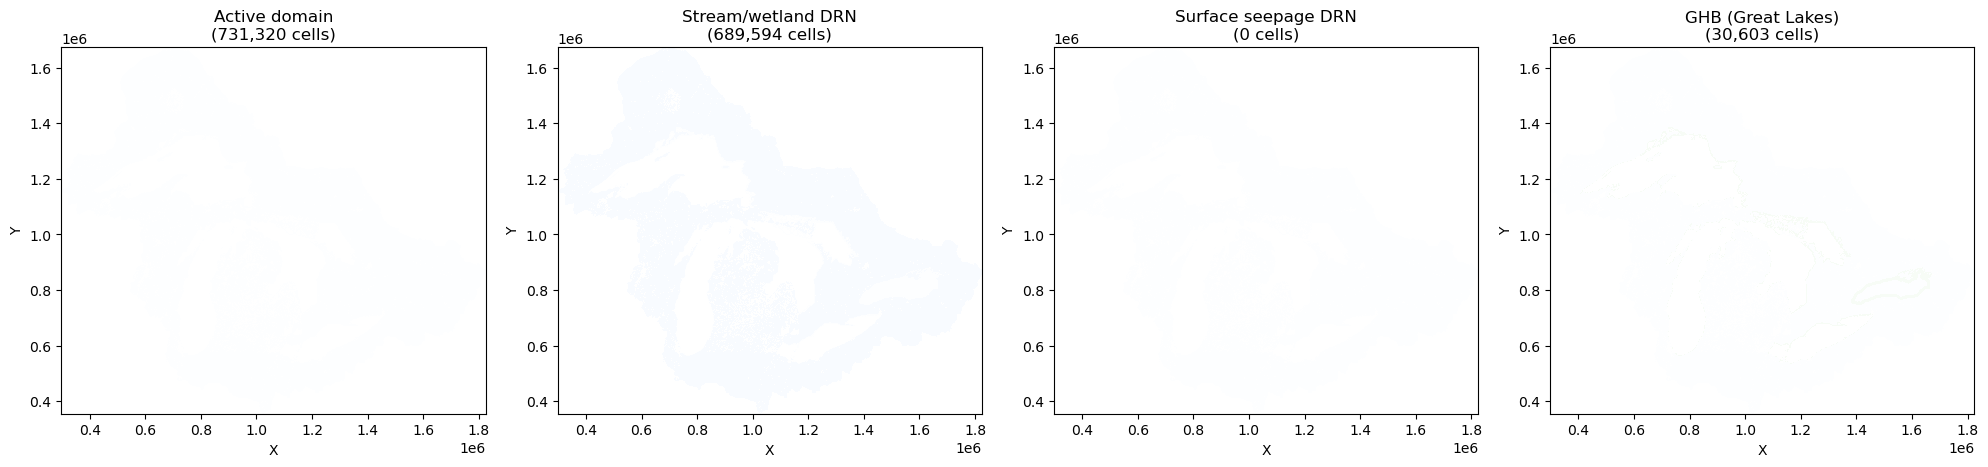


Overlap checks:
Stream/wetland ∩ surface seepage: 0 ← should be 0
Stream/wetland ∩ GHB:             0 ← should be 0
Surface seepage ∩ GHB:            0 ← should be 0


In [142]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ---------------------------------------------------------
# COMBINE dfDrn + dfSurfDrn for accurate statistics
# ---------------------------------------------------------
# Standardise dfSurfDrn columns to match dfDrn where possible
dfSurfDrn_plot = dfSurfDrn.rename(columns={"row": "row", "col": "col"}).copy()

# Use row/col naming consistently
if "row" not in dfSurfDrn_plot.columns and "i" in dfSurfDrn_plot.columns:
    dfSurfDrn_plot = dfSurfDrn_plot.rename(columns={"i": "row", "j": "col"})

dfDrn_all = pd.concat([dfDrn, dfSurfDrn_plot], ignore_index=True)

n_active    = int(np.sum(id2d == 1))
n_stream    = len(dfDrn)
n_surf      = len(dfSurfDrn)
n_drn_total = len(dfDrn_all)

print("Active cells:                  ", n_active)
print("Stream/wetland DRN cells:      ", n_stream)
print("Surface seepage DRN cells:     ", n_surf)
print("Total DRN cells:               ", n_drn_total)
print("Percent stream/wetland:        ", round(100.0 * n_stream    / n_active, 2), "%")
print("Percent surface seepage:       ", round(100.0 * n_surf      / n_active, 2), "%")
print("Percent total DRN:             ", round(100.0 * n_drn_total / n_active, 2), "%")

print("\nStream/wetland DRN sample:")
display(dfDrn.head())
print("\nSurface seepage DRN sample:")
display(dfSurfDrn.head())

# ---------------------------------------------------------
# GUARDS
# ---------------------------------------------------------
if "chd_rec" not in globals():
    chd_rec = []

# ---------------------------------------------------------
# BUILD SPATIAL MASKS FOR EACH DRAIN TYPE SEPARATELY
# ---------------------------------------------------------
def make_mask(rec_list, nrow, ncol):
    mask = np.full((nrow, ncol), np.nan, dtype=float)
    for rec in rec_list:
        try:
            k, i, j = rec[0]
            mask[int(i), int(j)] = 1.0
        except Exception:
            continue
    return mask

def get_extent(xorigin, yorigin, delr, delc, nrow, ncol):
    return [xorigin,
            xorigin + np.sum(delr),
            yorigin,
            yorigin + np.sum(delc)]

extent = get_extent(xorigin, yorigin, delr, delc, nrow, ncol)

# background active domain
bg = np.where(idomain[0] > 0, 1.0, np.nan)

# three separate masks
stream_wet_mask = make_mask(drn_rec_clean,  nrow, ncol)   # stream/wetland only
surf_mask       = make_mask(surf_rec,        nrow, ncol)   # surface seepage only
chd_mask        = make_mask(chd_rec,         nrow, ncol)   # CHD (empty if not used)

# GHB mask for reference
ghb_mask_plot = np.full((nrow, ncol), np.nan, dtype=float)
if "ghb_cells_df" in globals():
    for r in ghb_cells_df.itertuples(index=False):
        ghb_mask_plot[int(r.i), int(r.j)] = 1.0

# ---------------------------------------------------------
# PLOT — 4 panels so each boundary type is readable
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

titles  = ["Active domain", "Stream/wetland DRN", "Surface seepage DRN", "GHB (Great Lakes)"]
masks   = [bg, stream_wet_mask, surf_mask, ghb_mask_plot]
cmaps   = ["Greys", "Blues", "Reds", "Greens"]
alphas  = [0.4,  0.8,  0.7,  0.9]

for ax, mask, title, cmap, alpha in zip(axes, masks, titles, cmaps, alphas):
    # always draw active domain as light background
    ax.imshow(np.ma.masked_invalid(bg),
              origin="upper", extent=extent,
              cmap="Blues", alpha=0.15, interpolation="nearest")
    ax.imshow(np.ma.masked_invalid(mask),
              origin="upper", extent=extent,
              cmap=cmap, alpha=alpha, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    n = int(np.isfinite(mask).sum()) if mask is not bg else int(np.isfinite(bg).sum())
    ax.set_title(f"{title}\n({n:,} cells)")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# OVERLAP CHECKS
# ---------------------------------------------------------
sw_ij  = {(int(r[0][1]), int(r[0][2])) for r in drn_rec_clean}
sf_ij  = {(int(r[0][1]), int(r[0][2])) for r in surf_rec}
ghb_ij = {(int(r.i), int(r.j)) for r in ghb_cells_df.itertuples()} \
         if "ghb_cells_df" in globals() else set()

print("\nOverlap checks:")
print("Stream/wetland ∩ surface seepage:", len(sw_ij & sf_ij),  "← should be 0")
print("Stream/wetland ∩ GHB:            ", len(sw_ij & ghb_ij), "← should be 0")
print("Surface seepage ∩ GHB:           ", len(sf_ij & ghb_ij), "← should be 0")

In [ ]:
USE_WETLAND_DRN = False

In [ ]:
# Confirm weak drain cells exist with low conductance
weak_conds = [r[2] for r in surf_drn_rec if r[2] <= 1000.0]
normal_conds = [r[2] for r in surf_drn_rec if r[2] > 1000.0]
print(f"Weak drain cells (cond <= 1000):  {len(weak_conds):,}")
print(f"Normal drain cells (cond > 1000): {len(normal_conds):,}")
print(f"Weak cond min/max: {min(weak_conds):.1f} / {max(weak_conds):.1f}")

# Plot Inputs 

#### checking some inputs 

In [46]:
# Build lake mask 
import geopandas as gpd
import rasterio as rio
from rasterio.features import rasterize
import numpy as np

# use the real lake polygon, not the 10 km GHB ring
pathLakePoly = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes.shp"

def build_lake_mask_from_polygon(path_lake_poly, template_tif):
    gdf = gpd.read_file(path_lake_poly)

    if gdf.empty:
        raise ValueError("Lake polygon file is empty.")

    with rio.open(template_tif) as tmp:
        shapes = [(geom, 1) for geom in gdf.geometry if geom is not None and not geom.is_empty]

        lake_mask = rasterize(
            shapes=shapes,
            out_shape=(tmp.height, tmp.width),
            transform=tmp.transform,
            fill=0,
            dtype="uint8",
            all_touched=False
        ).astype(bool)

    return lake_mask

lake_mask_2d = build_lake_mask_from_polygon(pathLakePoly, template_tif)

# keep only active model cells
lake_mask_2d &= (id2d > 0)

print("Lake cells in active domain:", int(lake_mask_2d.sum()))

Lake cells in active domain: 244693


In [47]:
# set recharge = 0 over lake cells for all stress periods
for p in rch_spd:
    arr = np.array(rch_spd[p], dtype=float, copy=True)

    if arr.shape != lake_mask_2d.shape:
        raise ValueError(
            f"rch_spd[{p}] shape {arr.shape} does not match lake mask shape {lake_mask_2d.shape}"
        )

    arr[lake_mask_2d] = 0.0
    rch_spd[p] = arr

print("Recharge set to 0 over lake cells for all periods.")

Recharge set to 0 over lake cells for all periods.


In [48]:
rch_lake_max = max(np.nanmax(rch_spd[p][lake_mask_2d]) for p in rch_spd) if lake_mask_2d.any() else np.nan
rch_land_max = max(np.nanmax(rch_spd[p][~lake_mask_2d & (id2d > 0)]) for p in rch_spd)

print("Max recharge over lake cells:", rch_lake_max)
print("Max recharge over land cells:", rch_land_max)

Max recharge over lake cells: 0.0
Max recharge over land cells: 0.0


In [49]:
# remove drains from open-water lake cells
drain_frac2d = drain_frac2d.copy()
drain_elev2d = drain_elev2d.copy()

drain_frac2d[lake_mask_2d] = 0.0
drain_elev2d[lake_mask_2d] = np.nan

print("Drain cells remaining after removing lake cells:",
      int(np.count_nonzero(drain_frac2d > 0)))

Drain cells remaining after removing lake cells: 695769


In [50]:
#Check whether drains overlap lake cells
drain_cells = (drain_frac2d > 0) & (id2d > 0)
n_drain_in_lake = int(np.count_nonzero(drain_cells & lake_mask_2d))
n_drain_total   = int(np.count_nonzero(drain_cells))

print("Total drain cells:", n_drain_total)
print("Drain cells in lake:", n_drain_in_lake)

Total drain cells: 695769
Drain cells in lake: 0


In [51]:
# Thickness summary by layer
def summarize_layer_thickness(top2d, botm3d, id2d):
    nlay = botm3d.shape[0]

    for k in range(nlay):
        if k == 0:
            thk = top2d - botm3d[0]
        else:
            thk = botm3d[k - 1] - botm3d[k]

        vals = thk[id2d > 0]
        vals = vals[np.isfinite(vals)]

        if vals.size == 0:
            print(f"Layer {k+1}: no active finite thickness values")
            continue

        print(f"\nLayer {k+1} thickness summary (m)")
        print(f"  min   : {vals.min():.2f}")
        print(f"  p1    : {np.percentile(vals, 1):.2f}")
        print(f"  p5    : {np.percentile(vals, 5):.2f}")
        print(f"  p50   : {np.percentile(vals, 50):.2f}")
        print(f"  p95   : {np.percentile(vals, 95):.2f}")
        print(f"  p99   : {np.percentile(vals, 99):.2f}")
        print(f"  max   : {vals.max():.2f}")
        print(f"  <= 5m : {int(np.count_nonzero(vals <= 5.0)):,}")
        print(f"  <=10m : {int(np.count_nonzero(vals <= 10.0)):,}")

summarize_layer_thickness(top2d, botm3d, id2d)


Layer 1 thickness summary (m)
  min   : 25.97
  p1    : 79.21
  p5    : 81.78
  p50   : 86.62
  p95   : 116.11
  p99   : 131.52
  max   : 1593.66
  <= 5m : 0
  <=10m : 0

Layer 2 thickness summary (m)
  min   : 34.63
  p1    : 105.62
  p5    : 109.04
  p50   : 115.50
  p95   : 154.81
  p99   : 175.36
  max   : 2124.88
  <= 5m : 0
  <=10m : 0

Layer 3 thickness summary (m)
  min   : 43.29
  p1    : 132.02
  p5    : 136.30
  p50   : 144.37
  p95   : 193.51
  p99   : 219.19
  max   : 2656.11
  <= 5m : 0
  <=10m : 0

Layer 4 thickness summary (m)
  min   : 34.63
  p1    : 105.62
  p5    : 109.04
  p50   : 115.50
  p95   : 154.81
  p99   : 175.36
  max   : 2124.88
  <= 5m : 0
  <=10m : 0

Layer 5 thickness summary (m)
  min   : 34.63
  p1    : 105.62
  p5    : 109.04
  p50   : 115.50
  p95   : 154.81
  p99   : 175.36
  max   : 2124.88
  <= 5m : 0
  <=10m : 0


In [52]:
thk1 = top2d - botm3d[0]
thin1 = (id2d > 0) & np.isfinite(thk1) & (thk1 <= 10.0)

print("Layer 1 cells with thickness <= 10 m:", int(thin1.sum()))

Layer 1 cells with thickness <= 10 m: 0


In [53]:
#4) Drains: extra checks beyond lake overlap
# Check drain elevations against top elevation

# Drain elevation should usually be at or slightly below land surface, not above it.
drain_cells = (drain_frac2d > 0) & (id2d > 0) & np.isfinite(drain_elev2d)

bad_high = drain_cells & (drain_elev2d > top2d + 0.01)
bad_low  = drain_cells & (drain_elev2d < botm3d[0])

print("Drain cells total:", int(drain_cells.sum()))
print("Drain elev > top:", int(bad_high.sum()))
print("Drain elev < layer1 bottom:", int(bad_low.sum()))

Drain cells total: 695769
Drain elev > top: 251965
Drain elev < layer1 bottom: 117809


In [55]:
# Check overlap between drains and GHB cells

#If your GHB ring is open water, you usually do not want drains sitting on the same cells.
ghb_mask_2d = np.zeros((nrow, ncol), dtype=bool)
for r in ghb_cells_df.itertuples(index=False):
    ghb_mask_2d[int(r.i), int(r.j)] = True

drain_cells = (drain_frac2d > 0) & (id2d > 0)
overlap_drn_ghb = drain_cells & ghb_mask_2d

print("Drain/GHB overlap cells:", int(overlap_drn_ghb.sum()))

Drain/GHB overlap cells: 6006


In [56]:
total_thk = top2d - botm3d[-1]
vals = total_thk[id2d > 0]
vals = vals[np.isfinite(vals)]

print("Total thickness summary (m)")
print("  min :", vals.min())
print("  p1  :", np.percentile(vals, 1))
print("  p5  :", np.percentile(vals, 5))
print("  p50 :", np.percentile(vals, 50))
print("  p95 :", np.percentile(vals, 95))
print("  p99 :", np.percentile(vals, 99))
print("  max :", vals.max())

Total thickness summary (m)
  min : 173.14105
  p1  : 528.0859
  p5  : 545.21484
  p50 : 577.4866
  p95 : 774.0389
  p99 : 876.7765
  max : 10624.422


In [60]:
# check where the deepest cells are 
total_thk = top2d - botm3d[-1]

imax = np.nanargmax(np.where(id2d > 0, total_thk, np.nan))
imax_2d = np.unravel_index(imax, total_thk.shape)

print("Max thickness cell (i, j):", imax_2d)
print("Top there:", top2d[imax_2d])
print("Bottom there:", botm3d[-1][imax_2d])
print("Total thickness there:", total_thk[imax_2d])
print("Lake cell?", lake_mask_2d[imax_2d] if 'lake_mask_2d' in dir() else "lake mask not built")

Max thickness cell (i, j): (np.int64(869), np.int64(1494))
Top there: 625.4218
Bottom there: -9999.0
Total thickness there: 10624.422
Lake cell? False


In [61]:
# check the bottom raster distribution 
bot_base = botm3d[-1]
vals = bot_base[id2d > 0]
vals = vals[np.isfinite(vals)]

print("Bottom raster summary")
print("  min :", vals.min())
print("  p1  :", np.percentile(vals, 1))
print("  p5  :", np.percentile(vals, 5))
print("  p50 :", np.percentile(vals, 50))
print("  p95 :", np.percentile(vals, 95))
print("  p99 :", np.percentile(vals, 99))
print("  max :", vals.max())

Bottom raster summary
  min : -9999.0
  p1  : -698.0643
  p5  : -601.7294
  p50 : -335.16223
  p95 : -76.79024
  p99 : 3.5856757
  max : 470.2502


In [62]:
# plot extreme thickness cells 
extreme = (id2d > 0) & np.isfinite(total_thk) & (total_thk > 2000)
print("Cells with thickness > 2000 m:", int(extreme.sum()))

Cells with thickness > 2000 m: 135


In [57]:
DRN_DEPTH_M = 0.5   # or 1.0 m below land surface

drain_cells = (drain_frac2d > 0) & (id2d > 0)

drain_stage2d = np.full((nrow, ncol), np.nan, dtype=float)
drain_stage2d[drain_cells] = top2d[drain_cells] - DRN_DEPTH_M

In [58]:
# lake cells should not have drains
drain_cells[lake_mask_2d] = False
drain_stage2d[lake_mask_2d] = np.nan
drain_frac2d[lake_mask_2d] = 0.0

# build ghb mask
ghb_mask_2d = np.zeros((nrow, ncol), dtype=bool)
for r in ghb_cells_df.itertuples(index=False):
    ghb_mask_2d[int(r.i), int(r.j)] = True

# remove drains where GHB already exists
drain_cells[ghb_mask_2d] = False
drain_stage2d[ghb_mask_2d] = np.nan
drain_frac2d[ghb_mask_2d] = 0.0

## PLot 

In [123]:
import geopandas as gpd
import rasterio as rio
from rasterio.features import rasterize
import numpy as np

pathLakePoly = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes.shp"

def build_full_lake_mask(path_lake_poly, template_tif):
    gdf = gpd.read_file(path_lake_poly)

    with rio.open(template_tif) as tmp:
        lake_mask = rasterize(
            [(geom, 1) for geom in gdf.geometry if geom is not None and not geom.is_empty],
            out_shape=(tmp.height, tmp.width),
            transform=tmp.transform,
            fill=0,
            dtype="uint8",
            all_touched=False
        ).astype(bool)

    return lake_mask

lake_mask_full = build_full_lake_mask(pathLakePoly, template_tif)

print("Total lake polygon cells:", int(lake_mask_full.sum()))
print("Active lake cells:", int(np.sum((id2d == 1) & lake_mask_full)))
print("Inactive lake cells:", int(np.sum((id2d == 0) & lake_mask_full)))
print("Percent of lake cells active:",
      100 * np.sum((id2d == 1) & lake_mask_full) / max(int(lake_mask_full.sum()), 1))

Total lake polygon cells: 244693
Active lake cells: 35673
Inactive lake cells: 209020
Percent of lake cells active: 14.578676137037021


In [81]:
lake_mask_2d = lake_mask_full & (id2d == 1)

In [82]:
for p in rch_spd:
    arr = np.asarray(rch_spd[p], dtype=float).copy()
    arr[lake_mask_2d] = 0.0
    rch_spd[p] = arr

print("Recharge set to zero over active lake cells.")

Recharge set to zero over active lake cells.


In [83]:
lake_vals = []
for p in rch_spd:
    vals = np.asarray(rch_spd[p], dtype=float)[lake_mask_2d]
    vals = vals[np.isfinite(vals)]
    if vals.size > 0:
        lake_vals.append(vals.max())

print("Max recharge over active lake cells:", max(lake_vals) if lake_vals else np.nan)

Max recharge over active lake cells: 0.0


In [144]:
print("Active lake cells:", int(np.sum((id2d == 1) & lake_mask_full)))
print("Inactive lake cells:", int(np.sum((id2d == 0) & lake_mask_full)))

Active lake cells: 35673
Inactive lake cells: 209020


GHB cells identified for overlay: 30,603


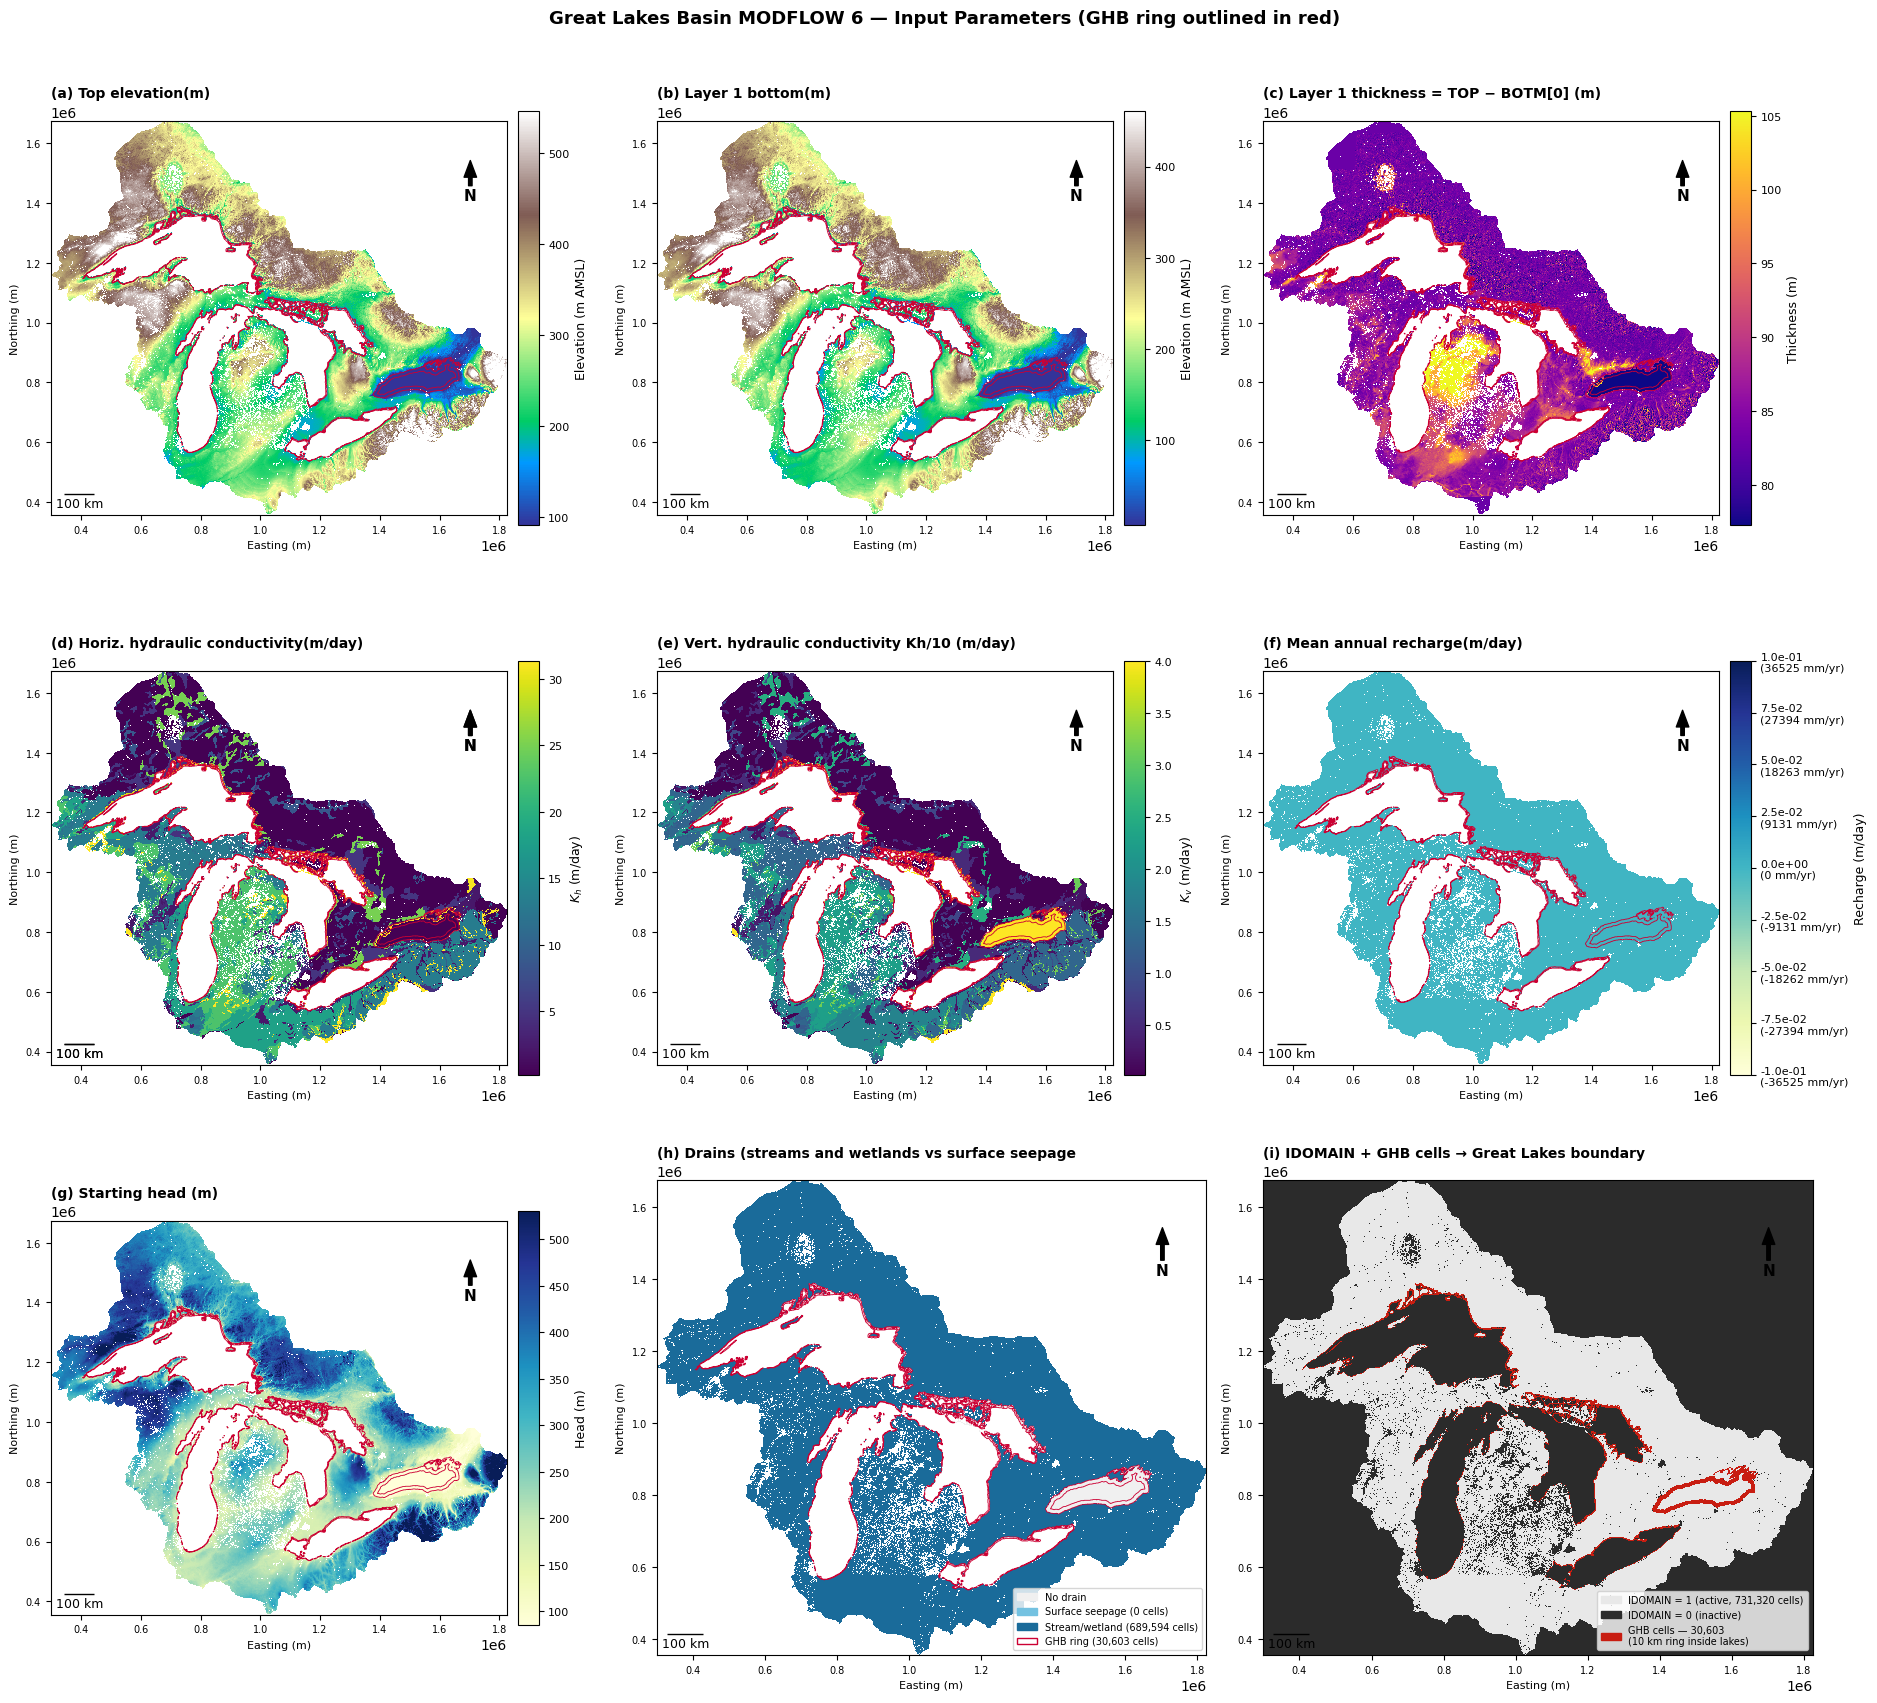

=== MODEL INPUT SUMMARY ===
Active cells total:           731,320
  terrestrial (land):         700,717
  GHB ring (in lake):          30,603

                       terrestrial        |   GHB ring
                  min      med     max    |  min    med    max
TOP            0 3.1e+02 1.1e+03 |      0 1.8e+02 4.4e+02 m
BOTM0        -47 2.2e+02 9.7e+02 |    -39     86 3.5e+02 m
THK1         1.6      85 1.3e+02 |   0.12     88 1.4e+02 m
HK0            0     8.6   1e+02 |      0  1e+02  1e+02 m/day
K33         0.02     1.2      10 |   0.02     10     10 m/day
STRT           0 2.9e+02   1e+03 |      0 1.7e+02  4e+02 m
RCH            0       0       0 |      0      0      0 m/day

DRN cells:  689,594
GHB cells:  30,603


In [145]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib.ticker import FixedLocator
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

# ---------------------------------------------------------
# helpers
# ---------------------------------------------------------
def get_plot_extent(xorigin, yorigin, delr, delc, nrow, ncol):
    return [xorigin,
            xorigin + np.sum(delr),
            yorigin,
            yorigin + np.sum(delc)]

def rec_list_to_mask(rec_list, nrow, ncol):
    mask = np.full((nrow, ncol), np.nan, dtype=float)
    if rec_list is None or len(rec_list) == 0:
        return mask
    for rec in rec_list:
        try:
            k, i, j = rec[0]
            if 0 <= i < nrow and 0 <= j < ncol:
                mask[i, j] = 1.0
        except Exception:
            continue
    return mask

def ghb_df_to_mask(ghb_cells_df, nrow, ncol):
    mask = np.full((nrow, ncol), np.nan, dtype=float)
    if ghb_cells_df is None or len(ghb_cells_df) == 0:
        return mask
    for r in ghb_cells_df.itertuples(index=False):
        i, j = int(r.i), int(r.j)
        if 0 <= i < nrow and 0 <= j < ncol:
            mask[i, j] = 1.0
    return mask

def active_array(arr, idomain2d):
    out = np.array(arr, dtype=float).copy()
    out[idomain2d <= 0] = np.nan
    return out

def pct(arr, lo, hi):
    v = arr[np.isfinite(arr)]
    return (float(np.nanpercentile(v, lo)),
            float(np.nanpercentile(v, hi))) if v.size else (0, 1)

def add_scalebar(ax, length_km=100):
    fp = fm.FontProperties(size=9)
    ax.add_artist(AnchoredSizeBar(
        ax.transData, length_km * 1000,
        f"{length_km} km", "lower left",
        pad=0.3, color="black", frameon=False,
        size_vertical=max(delc[0], delr[0]) * 1.5,
        fontproperties=fp))

def add_north(ax, x=0.92, y=0.90, size=0.09):
    ax.annotate("N", xy=(x, y), xytext=(x, y - size),
                xycoords="axes fraction", textcoords="axes fraction",
                ha="center", va="center",
                fontsize=11, fontweight="bold",
                arrowprops=dict(facecolor="black", edgecolor="black",
                                width=2.5, headwidth=9))

def add_cbar(fig, ax, im, label, fontsize=9):
    cb = fig.colorbar(im, ax=ax, shrink=0.82, pad=0.02)
    cb.set_label(label, fontsize=fontsize)
    cb.ax.tick_params(labelsize=8)
    return cb

def relabel_log_cbar(cb):
    ticks = cb.get_ticks()
    cb.ax.yaxis.set_major_locator(FixedLocator(ticks))
    cb.set_ticklabels([f"{10**t:.2g}" for t in ticks])

def relabel_rch_cbar(cb):
    ticks = cb.get_ticks()
    cb.ax.yaxis.set_major_locator(FixedLocator(ticks))
    cb.set_ticklabels([f"{v:.1e}\n({v*365.25*1000:.0f} mm/yr)"
                       for v in ticks])

# ---------------------------------------------------------
# prepare domain
# ---------------------------------------------------------
extent = get_plot_extent(xorigin, yorigin, delr, delc, nrow, ncol)

idomain2d = idomain[0] if idomain.ndim == 3 else id2d

# GHB cell mask directly from rebuilt GHB cells
ring_mask_2d = np.zeros((nrow, ncol), dtype=bool)
if "ghb_cells_df" in globals():
    for r in ghb_cells_df.itertuples(index=False):
        i, j = int(r.i), int(r.j)
        if 0 <= i < nrow and 0 <= j < ncol:
            ring_mask_2d[i, j] = True

n_ring = int(ring_mask_2d.sum())
print(f"GHB cells identified for overlay: {n_ring:,}")

def outline_ring(ax):
    if n_ring == 0:
        return
    ax.contour(
        ring_mask_2d.astype(float),
        levels=[0.5],
        colors="#cc0033",
        linewidths=0.6,
        extent=extent,
        origin="upper",
    )

# ---------------------------------------------------------
# arrays in MODEL UNITS as they enter MODFLOW 6
# ---------------------------------------------------------
top_plot = active_array(top2d, idomain2d)
bot1_plot = active_array(botm3d[0], idomain2d)
thk1_plot = active_array(top2d - botm3d[0], idomain2d)

hk1_plot = active_array(hk3d[0], idomain2d)
hk1_log  = np.log10(np.where(hk1_plot > 0, hk1_plot, np.nan))

k33_plot = active_array(k33_3d[0], idomain2d)
k33_log  = np.log10(np.where(k33_plot > 0, k33_plot, np.nan))

rch_all  = np.array([rch_spd[p] for p in range(len(rch_spd))], dtype=float)
rch_mean = np.nanmean(rch_all, axis=0)
rch_mday = active_array(rch_mean, idomain2d)

strt1_plot = active_array(strt[0] if strt.ndim == 3 else strt, idomain2d)

idomain_plot = np.where(idomain2d == 1, 1.0, np.nan)

drn_mask = rec_list_to_mask(drn_rec, nrow, ncol)

ghb_mask = ghb_df_to_mask(ghb_cells_df, nrow, ncol) \
           if "ghb_cells_df" in globals() \
           else np.full((nrow, ncol), np.nan, dtype=float)

# ---------------------------------------------------------
# color limits — computed on terrestrial cells only so the
# high-K ring doesn't blow out the land color range
# ---------------------------------------------------------
terrestrial_mask = (idomain2d == 1) & (~ring_mask_2d)

def pct_terrestrial(arr, lo, hi):
    v = arr[terrestrial_mask & np.isfinite(arr)]
    return (float(np.nanpercentile(v, lo)),
            float(np.nanpercentile(v, hi))) if v.size else (0, 1)

top_vmin,  top_vmax  = pct_terrestrial(top_plot,  2, 98)
bot_vmin,  bot_vmax  = pct_terrestrial(bot1_plot, 2, 98)
thk_vmin,  thk_vmax  = pct_terrestrial(thk1_plot, 2, 98)

hk1_log_terr = np.where(terrestrial_mask & (hk3d[0] > 0),
                        np.log10(hk3d[0]), np.nan)
k33_log_terr = np.where(terrestrial_mask & (k33_3d[0] > 0),
                        np.log10(k33_3d[0]), np.nan)

hk1_for_plot = active_array(hk3d[0], idomain2d)

# color range from terrestrial cells only (keeps the high-K ring from blowing out contrast)
hk_terr_vals = hk3d[0][terrestrial_mask]
hk_vmin = float(np.nanpercentile(hk_terr_vals[hk_terr_vals > 0], 2))
hk_vmax = float(np.nanpercentile(hk_terr_vals[hk_terr_vals > 0], 98))

##(e) Kv layer 1 — linear m/day
k33_for_plot = active_array(k33_3d[0], idomain2d)

k33_terr_vals = k33_3d[0][terrestrial_mask]
k33_vmin = float(np.nanpercentile(k33_terr_vals[k33_terr_vals > 0], 2))
k33_vmax = float(np.nanpercentile(k33_terr_vals[k33_terr_vals > 0], 98))


rch_vmin = 0.0
rch_vmax = float(np.nanpercentile(rch_mday[terrestrial_mask], 95))
strt_vmin, strt_vmax = pct_terrestrial(strt1_plot, 2, 98)

# ---------------------------------------------------------
# PLOT — 3x3 grid
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(19, 17))
axes = axes.ravel()
letters = [f"({x})" for x in "abcdefghi"]

def base_ax(ax, letter, title):
    ax.set_title(f"{letter} {title}", loc="left",
                 fontweight="bold", fontsize=10)
    ax.set_xlabel("Easting (m)", fontsize=8)
    ax.set_ylabel("Northing (m)", fontsize=8)
    ax.tick_params(labelsize=7)

# (a) Top elevation
im = axes[0].imshow(np.ma.masked_invalid(top_plot),
                    origin="upper", extent=extent,
                    cmap="terrain", vmin=top_vmin, vmax=top_vmax,
                    interpolation="nearest")
add_cbar(fig, axes[0], im, "Elevation (m AMSL)")
outline_ring(axes[0])
base_ax(axes[0], letters[0], "Top elevation(m)")
add_north(axes[0]); add_scalebar(axes[0])

# (b) Layer 1 bottom
im = axes[1].imshow(np.ma.masked_invalid(bot1_plot),
                    origin="upper", extent=extent,
                    cmap="terrain", vmin=bot_vmin, vmax=bot_vmax,
                    interpolation="nearest")
add_cbar(fig, axes[1], im, "Elevation (m AMSL)")
outline_ring(axes[1])
base_ax(axes[1], letters[1], "Layer 1 bottom(m)")
add_north(axes[1]); add_scalebar(axes[1])

# (c) Layer 1 thickness
im = axes[2].imshow(np.ma.masked_invalid(thk1_plot),
                    origin="upper", extent=extent,
                    cmap="plasma", vmin=thk_vmin, vmax=thk_vmax,
                    interpolation="nearest")
add_cbar(fig, axes[2], im, "Thickness (m)")
outline_ring(axes[2])
base_ax(axes[2], letters[2], "Layer 1 thickness = TOP − BOTM[0] (m)")
add_north(axes[2]); add_scalebar(axes[2])

# (d) Kh layer 1
im = axes[3].imshow(np.ma.masked_invalid(hk1_for_plot),
                    origin="upper", extent=extent,
                    cmap="viridis", vmin=hk_vmin, vmax=hk_vmax,
                    interpolation="nearest")
add_cbar(fig, axes[3], im, r"$K_h$ (m/day)")
outline_ring(axes[3])
base_ax(axes[3], letters[3],
        "Horiz. hydraulic conductivity(m/day)")
add_north(axes[3]); add_scalebar(axes[3])
add_north(axes[3]); add_scalebar(axes[3])

# (e)  Kv layer 1
im = axes[4].imshow(np.ma.masked_invalid(k33_for_plot),
                    origin="upper", extent=extent,
                    cmap="viridis", vmin=k33_vmin, vmax=k33_vmax,
                    interpolation="nearest")
add_cbar(fig, axes[4], im, r"$K_v$ (m/day)")
outline_ring(axes[4])
base_ax(axes[4], letters[4],
        "Vert. hydraulic conductivity Kh/10 (m/day)")
add_north(axes[4]); add_scalebar(axes[4])

# (f) Mean annual recharge
im = axes[5].imshow(np.ma.masked_invalid(rch_mday),
                    origin="upper", extent=extent,
                    cmap="YlGnBu", vmin=rch_vmin, vmax=rch_vmax,
                    interpolation="nearest")
cb = add_cbar(fig, axes[5], im, "Recharge (m/day)")
relabel_rch_cbar(cb)
outline_ring(axes[5])
rch_zero = 100 * np.mean(rch_mday[idomain2d > 0] < 1e-6)
# axes[5].text(0.02, 0.03,
#              f"Zero recharge: {rch_zero:.1f}% of domain",
#              transform=axes[5].transAxes, fontsize=8,
#              color="darkred",
#              bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
base_ax(axes[5], letters[5],
        "Mean annual recharge(m/day)")
add_north(axes[5]); add_scalebar(axes[5])

# (g) Starting head
im = axes[6].imshow(np.ma.masked_invalid(strt1_plot),
                    origin="upper", extent=extent,
                    cmap="YlGnBu",
                    vmin=strt_vmin, vmax=strt_vmax,
                    interpolation="nearest")
add_cbar(fig, axes[6], im, "Head (m)")
outline_ring(axes[6])
base_ax(axes[6], letters[6],
        "Starting head (m)")
add_north(axes[6]); add_scalebar(axes[6])

# (h) DRN cells
drn_type = np.zeros((nrow, ncol), dtype=float)
drn_type[idomain2d <= 0] = np.nan
for rec in drn_rec_clean:
    k, i, j = rec[0]
    drn_type[i, j] = 2.0
for rec in surf_rec:
    k, i, j = rec[0]
    if drn_type[i, j] != 2.0:
        drn_type[i, j] = 1.0

cmap_drn = ListedColormap(["#f0f0f0", "#74c2e1", "#1a6b9a"])
axes[7].imshow(np.ma.masked_invalid(drn_type),
               origin="upper", extent=extent,
               cmap=cmap_drn, vmin=0, vmax=2,
               interpolation="nearest")
outline_ring(axes[7])
axes[7].legend(handles=[
    Patch(color="#f0f0f0", label="No drain"),
    Patch(color="#74c2e1",
          label=f"Surface seepage ({len(surf_rec):,} cells)"),
    Patch(color="#1a6b9a",
          label=f"Stream/wetland ({len(drn_rec_clean):,} cells)"),
    Patch(edgecolor="#cc0033", facecolor="none",
          label=f"GHB ring ({n_ring:,} cells)"),
], loc="lower right", fontsize=7, frameon=True)
base_ax(axes[7], letters[7],
        "Drains (streams and wetlands vs surface seepage")
add_north(axes[7]); add_scalebar(axes[7])

# (i) GHB cells — show as filled ring with terrestrial background
idomain_bg = idomain2d.astype(float)
axes[8].imshow(idomain_bg,
               origin="upper", extent=extent,
               cmap=ListedColormap(["#2b2b2b", "#e8e8e8"]),  # dark grey = inactive, light grey = active
               vmin=0, vmax=1,
               interpolation="nearest")

# GHB cells on top
axes[8].imshow(np.ma.masked_invalid(ghb_mask),
               origin="upper", extent=extent,
               cmap=ListedColormap(["#c81d11"]),
               vmin=0.5, vmax=1.5,
               interpolation="nearest")

axes[8].legend(handles=[
    Patch(color="#e8e8e8", label=f"IDOMAIN = 1 (active, {int((idomain2d == 1).sum()):,} cells)"),
    Patch(color="#2b2b2b", label=f"IDOMAIN = 0 (inactive)"),
    Patch(color="#c81d11",
          label=f"GHB cells — {int(np.isfinite(ghb_mask).sum()):,}\n"
                f"(10 km ring inside lakes)"),
], loc="lower right", fontsize=7, frameon=True)
base_ax(axes[8], letters[8],
        "IDOMAIN + GHB cells → Great Lakes boundary")
add_north(axes[8]); add_scalebar(axes[8])

plt.suptitle(
    "Great Lakes Basin MODFLOW 6 — Input Parameters (GHB ring outlined in red)",
    fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig(r"D:\Users\abolmaal\modelling\Figs\Testing_5\modelinputs_2.jpeg",
            dpi=300, bbox_inches="tight")
plt.show()
# ---------------------------------------------------------
# summary in model units, split by terrestrial vs ring
# ---------------------------------------------------------
terr = terrestrial_mask
ring = ring_mask_2d

print("=== MODEL INPUT SUMMARY ===")
print(f"Active cells total:        {int(np.sum(idomain2d == 1)):>10,}")
print(f"  terrestrial (land):      {int(terr.sum()):>10,}")
print(f"  GHB ring (in lake):      {int(ring.sum()):>10,}")
print()
print("                       terrestrial        |   GHB ring")
print("                  min      med     max    |  min    med    max")
def row(name, arr, unit=""):
    t = arr[terr][np.isfinite(arr[terr])]
    r = arr[ring][np.isfinite(arr[ring])]
    print(f"{name:8s} "
          f"{t.min():>7.2g} {np.median(t):>7.2g} {t.max():>7.2g} "
          f"| {r.min():>6.2g} {np.median(r):>6.2g} {r.max():>6.2g} {unit}")
row("TOP",   top2d,                   "m")
row("BOTM0", botm3d[0],               "m")
row("THK1",  top2d - botm3d[0],       "m")
row("HK0",   hk3d[0],                 "m/day")
row("K33",   k33_3d[0],               "m/day")
row("STRT",  strt[0] if strt.ndim == 3 else strt, "m")
row("RCH",   rch_mean,                "m/day")
print()
print(f"DRN cells:  {len(drn_rec):,}")
print(f"GHB cells:  {int(np.isfinite(ghb_mask).sum()):,}")

In [119]:
print("Active cells total:", int(np.sum(idomain2d == 1)))
print("Inactive cells total:", int(np.sum(idomain2d == 0)))
print("Stream/wetland drains:", len(drn_rec_clean))
print("Surface seepage drains:", len(surf_rec))

Active cells total: 731320
Inactive cells total: 1282793
Stream/wetland drains: 689594
Surface seepage drains: 0


### Sanity Check

In [118]:
# Are lake cells active or inactive in idomain?
print("idomain2d unique values:", np.unique(idomain2d))
print("Active cells total:     ", int((idomain2d == 1).sum()))
print("Inactive cells total:   ", int((idomain2d == 0).sum()))

# Cross-check against the lake mask from the prep step
if "mask2d" in globals():
    lake_cells = (mask2d > 0)
    print("Lake cells (from mask2d):           ", int(lake_cells.sum()))
    print("Lake cells that are ACTIVE in idomain:", int((lake_cells & (idomain2d == 1)).sum()))
    print("Lake cells that are INACTIVE:         ", int((lake_cells & (idomain2d == 0)).sum()))

idomain2d unique values: [0 1]
Active cells total:      731320
Inactive cells total:    1282793
Lake cells (from mask2d):            0
Lake cells that are ACTIVE in idomain: 0
Lake cells that are INACTIVE:          0


In [120]:
print("mask2d dtype:", mask2d.dtype)
print("mask2d shape:", mask2d.shape)
print("Unique values:", np.unique(mask2d)[:20])
print("Value counts:")
vals, counts = np.unique(mask2d, return_counts=True)
for v, c in zip(vals[:10], counts[:10]):
    print(f"  {v:>10.3f}  →  {c:>10,} cells")
print(f"\nTotal cells:         {mask2d.size:,}")
print(f"mask2d == 0:         {(mask2d == 0).sum():,}")
print(f"mask2d > 0:          {(mask2d > 0).sum():,}")
print(f"mask2d is NaN:       {np.isnan(mask2d).sum():,}")

mask2d dtype: float32
mask2d shape: (1319, 1527)
Unique values: [0.]
Value counts:
       0.000  →   2,014,113 cells

Total cells:         2,014,113
mask2d == 0:         2,014,113
mask2d > 0:          0
mask2d is NaN:       0


In [121]:
# Are GHB cells actually adjacent to lake cells?
from scipy.ndimage import binary_dilation

lake_mask = (mask2d == -1)
shoreline_land = binary_dilation(lake_mask) & (idomain2d == 1)

ghb_idx = np.zeros((nrow, ncol), dtype=bool)
for r in ghb_cells_df.itertuples(index=False):
    ghb_idx[int(r.i), int(r.j)] = True

print(f"GHB cells total:                       {ghb_idx.sum():,}")
print(f"GHB cells on shoreline (land∩lake-adj): {(ghb_idx & shoreline_land).sum():,}")
print(f"GHB cells NOT on shoreline:             {(ghb_idx & ~shoreline_land).sum():,}")

GHB cells total:                       30,603
GHB cells on shoreline (land∩lake-adj): 0
GHB cells NOT on shoreline:             30,603


In [ ]:
# 1. What values does your idomain actually contain?
print("idomain unique values:", np.unique(idomain))

# 2. If you're building a flopy MF6 model, check the package you're feeding it to
# (it should be ModflowGwfdis with idomain= ..., NOT a CHD or IBOUND)

In [ ]:
ghb_on_active = 0
ghb_on_inactive = 0
for r in ghb_cells_df.itertuples(index=False):
    i, j = int(r.i), int(r.j)
    if idomain2d[i, j] == 1:
        ghb_on_active += 1
    else:
        ghb_on_inactive += 1

print(f"GHB cells on active (idomain == 1):   {ghb_on_active:,}")
print(f"GHB cells on inactive (idomain == 0): {ghb_on_inactive:,}")

In [ ]:
ghb_on_land    = 0   # GHB on mask2d == 1  → on land, near shoreline
ghb_on_lake    = 0   # GHB on mask2d == -1 → inside lake footprint
ghb_on_outside = 0   # GHB on mask2d == 0  → outside basin (shouldn't happen)

for r in ghb_cells_df.itertuples(index=False):
    i, j = int(r.i), int(r.j)
    m = mask2d[i, j]
    if m == 1:
        ghb_on_land += 1
    elif m == -1:
        ghb_on_lake += 1
    elif m == 0:
        ghb_on_outside += 1

print(f"GHB on LAND (mask2d == 1):    {ghb_on_land:>7,}")
print(f"GHB on LAKE (mask2d == -1):   {ghb_on_lake:>7,}")
print(f"GHB on OUTSIDE (mask2d == 0): {ghb_on_outside:>7,}")

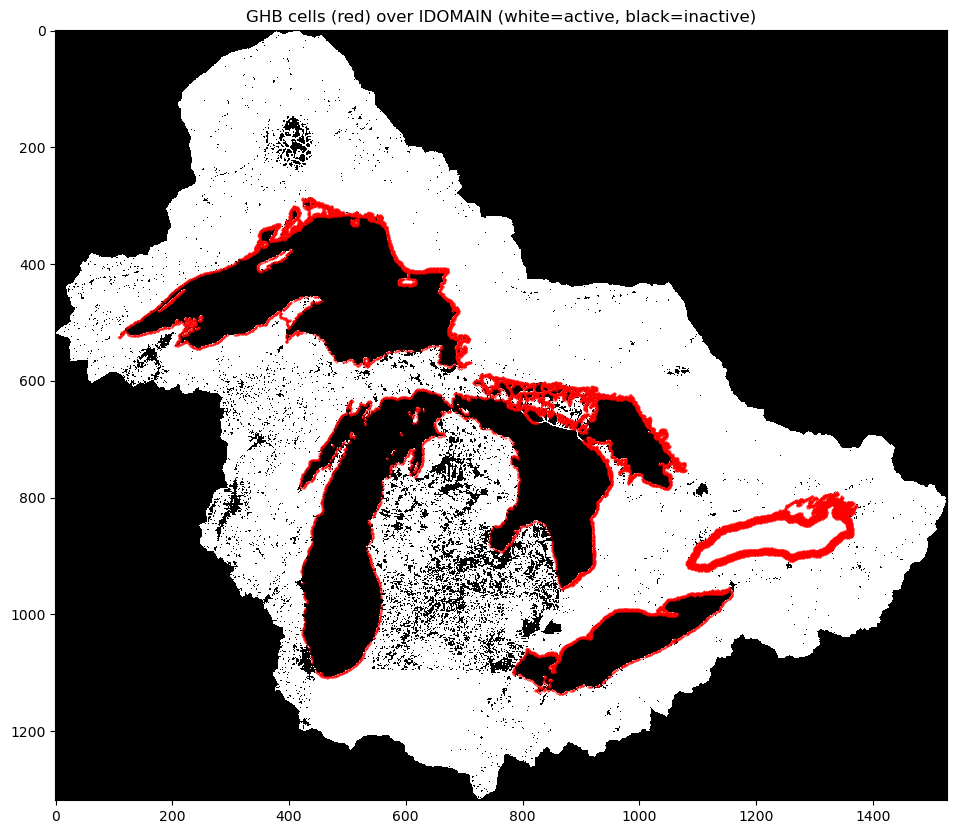

In [146]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(idomain2d, cmap="Greys_r", interpolation="nearest")

# overlay GHB cells in red
for r in ghb_cells_df.itertuples(index=False):
    ax.plot(int(r.j), int(r.i), "r.", markersize=0.5)

ax.set_title("GHB cells (red) over IDOMAIN (white=active, black=inactive)")
plt.show()

In [147]:
# Build a boolean mask of "GHB ring inside lakes": GHB cells where mask2d == -1
ring_mask = np.zeros((nrow, ncol), dtype=bool)
for r in ghb_cells_df.itertuples(index=False):
    i, j = int(r.i), int(r.j)
    if mask2d[i, j] == -1:
        ring_mask[i, j] = True

print(f"GHB ring cells (inside lake footprint): {ring_mask.sum():,}\n")

# Compare land cells vs ring cells for each input
for name, arr in [("TOP",    top2d),
                  ("BOTM0",  botm3d[0]),
                  ("THK1",   top2d - botm3d[0]),
                  ("HK0",    hk3d[0]),
                  ("STRT0",  strt[0] if strt.ndim == 3 else strt)]:
    ring_vals = arr[ring_mask]
    land_vals = arr[(mask2d == 1) & (idomain2d == 1)]
    print(f"{name}:")
    print(f"  GHB-ring:  min={np.nanmin(ring_vals):>10.3g}  "
          f"median={np.nanmedian(ring_vals):>10.3g}  "
          f"max={np.nanmax(ring_vals):>10.3g}")
    print(f"  Land:      min={np.nanmin(land_vals):>10.3g}  "
          f"median={np.nanmedian(land_vals):>10.3g}  "
          f"max={np.nanmax(land_vals):>10.3g}")
    print()

# Also check recharge
rch_ring = rch_mday[ring_mask]
rch_land = rch_mday[(mask2d == 1) & (idomain2d == 1)]
print(f"Recharge (m/day):")
print(f"  GHB-ring:  min={np.nanmin(rch_ring):>10.3g}  "
      f"median={np.nanmedian(rch_ring):>10.3g}  "
      f"max={np.nanmax(rch_ring):>10.3g}")
print(f"  Land:      min={np.nanmin(rch_land):>10.3g}  "
      f"median={np.nanmedian(rch_land):>10.3g}  "
      f"max={np.nanmax(rch_land):>10.3g}")

GHB ring cells (inside lake footprint): 0

TOP:


ValueError: zero-size array to reduction operation fmin which has no identity

In [148]:
from scipy.ndimage import distance_transform_edt

# For each GHB cell that's inside the lake footprint, how far is it from the
# nearest land cell?
land_mask = (mask2d == 1)

# Distance from each non-land cell to the nearest land cell, in cell units
dist_cells = distance_transform_edt(~land_mask)
cell_size_m = float(delr[0])  # assuming uniform spacing
dist_m = dist_cells * cell_size_m

# Sample the distances only at GHB-ring cells
ring_mask_2d = np.zeros((nrow, ncol), dtype=bool)
for r in ghb_cells_df.itertuples(index=False):
    i, j = int(r.i), int(r.j)
    if mask2d[i, j] == -1:
        ring_mask_2d[i, j] = True

ring_distances = dist_m[ring_mask_2d]
print(f"GHB-ring cells: {ring_mask_2d.sum():,}")
print(f"Distance from land (km):")
print(f"  min:    {ring_distances.min()/1000:.2f}")
print(f"  median: {np.median(ring_distances)/1000:.2f}")
print(f"  95th:   {np.percentile(ring_distances, 95)/1000:.2f}")
print(f"  99th:   {np.percentile(ring_distances, 99)/1000:.2f}")
print(f"  max:    {ring_distances.max()/1000:.2f}")

GHB-ring cells: 0
Distance from land (km):


ValueError: zero-size array to reduction operation minimum which has no identity

In [ ]:
## Run this one-liner in your notebook to see what lake_mask actually covers:
print(f"lake_mask total cells:              {lake_mask.sum():,}")
print(f"lake_mask & (mask2d == -1):          {(lake_mask & (mask2d == -1)).sum():,}")
print(f"lake_mask & (idomain2d == 1):        {(lake_mask & (idomain2d == 1)).sum():,}")
print(f"mask2d == -1 total (all lake cells): {(mask2d == -1).sum():,}")
print()
print(f"Lake cells in mask2d but NOT in lake_mask: "
      f"{((mask2d == -1) & ~lake_mask).sum():,}")

## Some sanity checks

In [ ]:
import numpy as np
import pandas as pd

print("=" * 60)
print("SANITY CHECKS BEFORE RUNNING MODFLOW 6")
print("=" * 60)

# ---------------------------------------------------------
# 1) SURFACE SEEPAGE CONDUCTANCE
# ---------------------------------------------------------
print("\n--- 1) Surface seepage conductance ---")
surf_conds = np.array([r[2] for r in surf_drn_rec])
print(f"  Csurf min:    {surf_conds.min():.3e} m²/day")
print(f"  Csurf max:    {surf_conds.max():.3e} m²/day")
print(f"  Csurf median: {np.median(surf_conds):.3e} m²/day")
print(f"  Cells at cap (1e4): {np.sum(surf_conds >= 9999):.0f}")

if surf_conds.max() > 1e6:
    print("  ❌ FAIL — Csurf max > 1e6, TSOIL/SURF_AREA_FRAC fix not applied")
elif surf_conds.max() > 1e5:
    print("  ⚠️  WARNING — Csurf max > 1e5, consider lowering SURF_COND_CAP")
else:
    print("  ✅ PASS — conductance range looks reasonable")

# ---------------------------------------------------------
# 2) DRAIN RECORD COUNTS AND NO DUPLICATES
# ---------------------------------------------------------
print("\n--- 2) DRN record counts ---")
print(f"  Stream/wetland records: {len(drn_rec_clean):,}")
print(f"  Surface seepage records: {len(surf_rec):,}")
print(f"  Total drn_rec: {len(drn_rec):,}")

# check for duplicate (i,j) cells in final drn_rec
ij_list = [(r[0][1], r[0][2]) for r in drn_rec]
ij_set  = set(ij_list)
n_dups  = len(ij_list) - len(ij_set)
print(f"  Duplicate (i,j) cells: {n_dups}")
if n_dups > 0:
    print("  ❌ FAIL — duplicate drain cells will cause MODFLOW budget errors")
else:
    print("  ✅ PASS — no duplicate drain cells")

# ---------------------------------------------------------
# 3) OVERLAP BETWEEN DRN AND GHB
# ---------------------------------------------------------
print("\n--- 3) DRN / GHB overlap ---")
drn_ij = {(r[0][1], r[0][2]) for r in drn_rec}
ghb_ij = {(int(r.i), int(r.j)) for r in ghb_cells_df.itertuples()}
overlap = drn_ij & ghb_ij
print(f"  DRN cells:  {len(drn_ij):,}")
print(f"  GHB cells:  {len(ghb_ij):,}")
print(f"  Overlap:    {len(overlap)}")
if len(overlap) > 0:
    print("  ❌ FAIL — DRN and GHB share cells, remove overlap before running")
else:
    print("  ✅ PASS — no DRN/GHB overlap")

# ---------------------------------------------------------
# 4) GHB STAGE vs CELL TOP
# ---------------------------------------------------------
print("\n--- 4) GHB stage vs land surface (top_cap check) ---")
if "top_cap" not in ghb_cells_df.columns:
    print("  ⚠️  top_cap column missing — GHB stage cap fix not applied")
else:
    rr = ghb_cells_df["i"].to_numpy(dtype=int)
    cc = ghb_cells_df["j"].to_numpy(dtype=int)
    first_per_stages = np.array([
        float(monthly_stages_model.loc[model_months[0], r.stage_name])
        for r in ghb_cells_df.itertuples(index=False)
    ])
    capped_stages = np.array([
        min(float(monthly_stages_model.loc[model_months[0], r.stage_name]),
            float(r.top_cap) - 0.10)
        for r in ghb_cells_df.itertuples(index=False)
    ])
    n_above = np.sum(first_per_stages > top2d[rr, cc])
    n_capped = np.sum(capped_stages < first_per_stages)
    print(f"  GHB cells where raw stage > top2d:   {n_above:,}")
    print(f"  GHB cells where stage was capped:    {n_capped:,}")
    if n_above > 0 and n_capped == 0:
        print("  ❌ FAIL — stage cap fix not active in ghb_spd loop")
    else:
        print("  ✅ PASS — stage cap applied to all cells above land surface")

# ---------------------------------------------------------
# 5) STARTING HEADS WITHIN VALID RANGE
# ---------------------------------------------------------
print("\n--- 5) Starting heads ---")
active = idomain[0] > 0
strt1 = strt[0]
above_top  = np.sum(strt1[active] > top2d[active])
below_bot  = np.sum(strt1[active] < botm3d[0][active])
print(f"  Cells with head > top2d:   {above_top:,}")
print(f"  Cells with head < botm[0]: {below_bot:,}")
print(f"  Head min/max (active): "
      f"{strt1[active].min():.1f} / {strt1[active].max():.1f} m")
if above_top > 0:
    print("  ⚠️  WARNING — some starting heads above land surface")
if below_bot > 0:
    print("  ❌ FAIL — some starting heads below cell bottom, model will fail")
else:
    print("  ✅ PASS — all starting heads above cell bottom")

# ---------------------------------------------------------
# 6) LAYER THICKNESS
# ---------------------------------------------------------
print("\n--- 6) Layer thickness ---")
for k in range(nlay):
    if k == 0:
        thk = top2d - botm3d[0]
    else:
        thk = botm3d[k-1] - botm3d[k]
    thk_active = thk[idomain[k] > 0]
    n_thin = np.sum(thk_active <= 0)
    print(f"  Layer {k+1}: min={thk_active.min():.2f} m  "
          f"max={thk_active.max():.1f} m  "
          f"cells <= 0m: {n_thin}")
    if n_thin > 0:
        print(f"  ❌ FAIL — Layer {k+1} has zero or negative thickness cells")

# ---------------------------------------------------------
# 7) RECHARGE BUDGET VS DRAIN CAPACITY
# ---------------------------------------------------------
print("\n--- 7) Recharge vs drain budget (period 0) ---")
rch0 = rch_spd[0]
active2d = (id2d == 1)

total_rch_m3day = float(np.sum(
    rch0[active2d] * delr[np.where(active2d)[1]] * delc[np.where(active2d)[0]]
))

# surface seepage max possible outflow (if all heads at drain elev)
surf_cond_arr = np.array([r[2] for r in surf_drn_rec])
# max outflow if head were 1 m above drain elevation everywhere
surf_max_out = float(np.sum(surf_cond_arr * 1.0))

print(f"  Total recharge period 0:        {total_rch_m3day:.3e} m³/day")
print(f"  Surface seepage max outflow*:   {surf_max_out:.3e} m³/day")
print(f"  (* if heads were 1m above drain elevation everywhere)")
ratio = surf_max_out / total_rch_m3day if total_rch_m3day > 0 else np.inf
print(f"  Ratio (seepage capacity / recharge): {ratio:.2f}")
if ratio > 100:
    print("  ❌ FAIL — drain capacity >> recharge, model will over-drain")
elif ratio > 10:
    print("  ⚠️  WARNING — drain capacity 10x recharge, watch for drainage")
else:
    print("  ✅ PASS — drain capacity in reasonable range vs recharge")

# ---------------------------------------------------------
# 8) HK RANGE
# ---------------------------------------------------------
print("\n--- 8) Hydraulic conductivity ---")
for k in range(nlay):
    hk_active = hk3d[k][idomain[k] > 0]
    print(f"  Layer {k+1}: min={hk_active.min():.2e}  "
          f"max={hk_active.max():.2e}  "
          f"median={np.median(hk_active):.2e} m/day")

# ---------------------------------------------------------
# 9) STRESS PERIOD COUNT CONSISTENCY
# ---------------------------------------------------------
print("\n--- 9) Stress period consistency ---")
print(f"  perioddata_run:  {len(perioddata_run)} periods")
print(f"  rch_spd:         {len(rch_spd)} periods")
print(f"  ghb_spd:         {len(ghb_spd)} periods")

ok = (len(rch_spd) == len(perioddata_run) == len(ghb_spd))
if not ok:
    print("  ❌ FAIL — period counts do not match")
else:
    print("  ✅ PASS — all packages have same number of stress periods")

# ---------------------------------------------------------
# 10) k33 ANISOTROPY
# ---------------------------------------------------------
print("\n--- 10) Vertical K (k33) anisotropy ---")
if "k33_3d" not in globals():
    print("  ❌ FAIL — k33_3d not defined, NPF will use isotropic K")
else:
    for k in range(nlay):
        hk_act = hk3d[k][idomain[k] > 0]
        kv_act = k33_3d[k][idomain[k] > 0]
        ratio  = hk_act / kv_act
        print(f"  Layer {k+1}: Kh/Kv ratio "
              f"min={ratio.min():.1f}  max={ratio.max():.1f}  "
              f"median={np.median(ratio):.1f}")
    print("  ✅ k33_3d defined")

print("\n" + "=" * 60)
print("SANITY CHECKS COMPLETE")
print("=" * 60)

In [ ]:
# 5) Plot HK in log scale
hk1_plot = np.where(idomain[0] > 0, hk3d[0], np.nan)
hk1_log = np.log10(np.where(hk1_plot > 0, hk1_plot, np.nan))

plt.figure(figsize=(8, 6))
plt.imshow(np.ma.masked_invalid(hk1_log), origin="upper", cmap="viridis")
plt.title("log10(HK) Layer 1")
plt.colorbar(label="log10(m/day)")
plt.show()

# 12) Build and run MODFLOW 6

In [149]:
# Close possible open handles from earlier tests
for varname in ["cbc", "hds", "bud", "headfile", "cellbudgetfile", "hdobj", "cbbobj"]:
    obj = globals().get(varname, None)
    try:
        if obj is not None and hasattr(obj, "close"):
            obj.close()
            print(f"Closed {varname}")
    except Exception as e:
        print(f"Could not close {varname}: {repr(e)}")

if os.path.isdir(sim_ws):
    safe_rmtree(sim_ws)
os.makedirs(sim_ws, exist_ok=True)

sim = flopy.mf6.MFSimulation(sim_name=nameSim, sim_ws=sim_ws, exe_name=exe_path)

tdis = flopy.mf6.ModflowTdis(
    sim,
    time_units="DAYS",
    nper=len(perioddata_run),
    perioddata=perioddata_run,
    start_date_time=START_DATE,
)
# Steady state spin-up in period 0, then transient periods 1+ with same length as perioddata_run
ims = flopy.mf6.ModflowIms(
    sim,
    pname="ims",
    complexity="MODERATE",
    outer_maximum=500,          # increased from 100
    inner_maximum=300,          # increased from 200
    outer_dvclose=1e-3,         # tightened from 1e-2
    inner_dvclose=1e-3,         # tightened from 1e-2
    rcloserecord=1e-3,          # tightened from 1e-2
    linear_acceleration="BICGSTAB",
    under_relaxation="DBD",
    under_relaxation_theta=0.9,  # add damping
    under_relaxation_kappa=0.0001,
    under_relaxation_gamma=0.0,
    print_option="SUMMARY",
    filename=f"{nameModel}.ims",
)

gwf = flopy.mf6.ModflowGwf(sim, modelname=nameModel, save_flows=True)
sim.register_ims_package(ims, [gwf.name])

dis = flopy.mf6.ModflowGwfdis(
    gwf,
    nlay=nlay, nrow=nrow, ncol=ncol,
    delr=delr, delc=delc,
    top=top2d,
    botm=botm3d,
    idomain=idomain,
    xorigin=xorigin, yorigin=yorigin,
)

icelltype = [1] + [0] * (nlay - 1)

npf = flopy.mf6.ModflowGwfnpf(
    gwf,
    icelltype=icelltype,
    k=hk3d,
    k33=k33_3d,
    save_specific_discharge=True,
)

ic = flopy.mf6.ModflowGwfic(gwf, strt=strt)

# ---- CHANGED: period 0 = steady-state spin-up, periods 1+ = transient ----
sto = flopy.mf6.ModflowGwfsto(
    gwf,
    ss=1e-6,
    sy=0.1,
    steady_state=False,
    transient=True,
)


oc = flopy.mf6.ModflowGwfoc(
    gwf,
    head_filerecord=f"{nameModel}.hds",
    budget_filerecord=f"{nameModel}.cbb",
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
    printrecord=[("HEAD", "LAST"), ("BUDGET", "LAST")],
)

drn_rec = drn_rec if "drn_rec" in globals() else []
wet_drn_rec = wet_drn_rec if "wet_drn_rec" in globals() else []

if USE_DRN and len(drn_rec) > 0:
    drn_spd = {per: drn_rec for per in range(len(perioddata_run))}
    drn = flopy.mf6.ModflowGwfdrn(
        gwf,
        pname="DRN",
        filename=f"{nameModel}.drn",
        maxbound=len(drn_rec),
        stress_period_data=drn_spd,
        save_flows=True,
    )
    print("✅ DRN package added:", len(drn_rec), "cells")
    print("   DRN stress periods:", len(drn_spd))
else:
    print("Skipping DRN package")

if USE_GHB:
    if "ghb_spd" not in globals():
        raise ValueError("ghb_spd does not exist. Run Part 10 first.")
    if ghb_spd is None:
        raise ValueError("ghb_spd is None. Check Part 10.")
    if len(ghb_spd) == 0:
        raise ValueError("ghb_spd is empty. Check Part 10.")

if USE_GHB and ghb_spd is not None:
    print("Using GHB stress periods:", len(ghb_spd))
    print("Using GHB maxbound:", max(len(v) for v in ghb_spd.values()))
    if "ghb_cells_df" in globals():
        print("Using GHB lakes:", sorted(ghb_cells_df["lake_name"].unique()))

    ghb = flopy.mf6.ModflowGwfghb(
        gwf,
        pname="GHB_gl",
        filename=f"{nameModel}.ghb",
        boundnames=True,
        print_input=True,
        save_flows=True,
        maxbound=max(len(v) for v in ghb_spd.values()),
        stress_period_data=ghb_spd,
    )
    print("✅ GHB package added")
else:
    print("Skipping GHB package")

rcha = flopy.mf6.ModflowGwfrcha(
    gwf,
    pname="RCHA",
    filename=f"{nameModel}.rcha",
    recharge=rch_spd,
)
print("✅ RCH package added:", len(rch_spd), "periods")

# ---- ADDED: final consistency check before writing ----
print("\n--- Final period count check ---")
print(f"perioddata_run: {len(perioddata_run)}")
print(f"rch_spd:        {len(rch_spd)}")
print(f"ghb_spd:        {len(ghb_spd)}")
print(f"drn_spd:        {len(drn_spd)}")
assert len(rch_spd) == len(perioddata_run), \
    f"rch_spd has {len(rch_spd)} periods, expected {len(perioddata_run)}"
assert len(ghb_spd) == len(perioddata_run), \
    f"ghb_spd has {len(ghb_spd)} periods, expected {len(perioddata_run)}"
assert len(drn_spd) == len(perioddata_run), \
    f"drn_spd has {len(drn_spd)} periods, expected {len(perioddata_run)}"
print("✅ All period counts match — safe to write and run")

def rec_to_set(rec_list):
    out = set()
    for rec in rec_list:
        try:
            k, i, j = rec[0]
            out.add((int(k), int(i), int(j)))
        except Exception:
            pass
    return out

drn_set = rec_to_set(drn_rec)
wet_drn_set = rec_to_set(wet_drn_rec)

ghb_set = set()
if "ghb_spd" in globals() and ghb_spd is not None:
    for per, recs in ghb_spd.items():
        for rec in recs:
            try:
                k, i, j = rec[0]
                ghb_set.add((int(k), int(i), int(j)))
            except Exception:
                pass

print("DRN ∩ wetland DRN:", len(drn_set & wet_drn_set))
print("DRN ∩ GHB:", len(drn_set & ghb_set))
print("wetland DRN ∩ GHB:", len(wet_drn_set & ghb_set))

✅ DRN package added: 689594 cells
   DRN stress periods: 13
Using GHB stress periods: 13
Using GHB maxbound: 30604
Using GHB lakes: ['Erie', 'Huron', 'Michigan', 'Ontario', 'Superior']
✅ GHB package added
✅ RCH package added: 13 periods

--- Final period count check ---
perioddata_run: 13
rch_spd:        13
ghb_spd:        13
drn_spd:        13
✅ All period counts match — safe to write and run
DRN ∩ wetland DRN: 0
DRN ∩ GHB: 0
wetland DRN ∩ GHB: 0


In [150]:
print("perioddata_run:", len(perioddata_run))  # NPR
print("rch_spd:",        len(rch_spd))          # 13
print("ghb_spd:",        len(ghb_spd))          # 13

perioddata_run: 13
rch_spd: 13
ghb_spd: 13


In [151]:
sim.write_simulation()
success, buff = sim.run_simulation()
print("Run success:", success)
if not success:
    with open(os.path.join(sim_ws, f"{nameModel}.lst")) as f:
        lines = f.readlines()
    print("".join(lines[-50:]))

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims...
  writing model Testing_6...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package ic...
    writing package sto...
    writing package oc...
    writing package drn...
    writing package ghb_gl...
    writing package rcha...
FloPy is using the following executable to run the model: ..\helper\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.3 09/29/2025

   MODFLOW 6 compiled Oct 07 2025 23:07:48 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                             Build 20220726_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the 

## 12-1) run the model agan with the head rom the previous model 

In [152]:
#Extract the head from this simulation
import flopy.utils.binaryfile as bf
import numpy as np

head_path = os.path.join(sim_ws, f"{nameModel}.hds")
hds = bf.HeadFile(head_path)
times = hds.get_times()
h_final = hds.get_data(totim=times[-1])

# clean up placeholder values
h_warmstart = h_final.copy()
for k in range(nlay):
    dry = np.abs(h_warmstart[k]) >= 1e20
    h_warmstart[k][dry] = botm3d[k][dry] + 1.0

# FIXED — idomain is 3D so index matches h_warmstart shape
h_warmstart[idomain <= 0] = 0.0

# cap heads at land surface — prevents artesian start
for k in range(nlay):
    active = idomain[k] > 0
    above_top = active & (h_warmstart[k] > top2d)
    h_warmstart[k][above_top] = top2d[above_top] - 0.1
    print(f"Layer {k+1}: capped {above_top.sum():,} cells above land surface")

warmstart_path = os.path.join(
    r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers",
    "warmstart_heads.npy"
)
np.save(warmstart_path, h_warmstart)
print(f"\nWarm start heads saved: {warmstart_path}")
print(f"Shape: {h_warmstart.shape}")
print(f"Layer 1 min/max: "
      f"{h_warmstart[0][idomain[0]>0].min():.1f} / "
      f"{h_warmstart[0][idomain[0]>0].max():.1f} m")

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Users\\abolmaal\\modelling\\Modflow\\Testing_6\\Testing_6.hds'

In [ ]:
# Close possible open handles from earlier tests
for varname in ["cbc", "hds", "bud", "headfile", "cellbudgetfile", "hdobj", "cbbobj"]:
    obj = globals().get(varname, None)
    try:
        if obj is not None and hasattr(obj, "close"):
            obj.close()
            print(f"Closed {varname}")
    except Exception as e:
        print(f"Could not close {varname}: {repr(e)}")

if os.path.isdir(sim_ws):
    safe_rmtree(sim_ws)
os.makedirs(sim_ws, exist_ok=True)

sim = flopy.mf6.MFSimulation(sim_name=nameSim, sim_ws=sim_ws, exe_name=exe_path)

tdis = flopy.mf6.ModflowTdis(
    sim,
    time_units="DAYS",
    nper=len(perioddata_run),
    perioddata=perioddata_run,
    start_date_time=START_DATE,
)
# Steady state spin-up in period 0, then transient periods 1+ with same length as perioddata_run
ims = flopy.mf6.ModflowIms(
    sim,
    pname="ims",
    complexity="MODERATE",
    outer_maximum=500,          # increased from 100
    inner_maximum=300,          # increased from 200
    outer_dvclose=1e-3,         # tightened from 1e-2
    inner_dvclose=1e-3,         # tightened from 1e-2
    rcloserecord=1e-3,          # tightened from 1e-2
    linear_acceleration="BICGSTAB",
    under_relaxation="DBD",
    under_relaxation_theta=0.9,  # add damping
    under_relaxation_kappa=0.0001,
    under_relaxation_gamma=0.0,
    print_option="SUMMARY",
    filename=f"{nameModel}.ims",
)

gwf = flopy.mf6.ModflowGwf(sim, modelname=nameModel, save_flows=True)
sim.register_ims_package(ims, [gwf.name])

dis = flopy.mf6.ModflowGwfdis(
    gwf,
    nlay=nlay, nrow=nrow, ncol=ncol,
    delr=delr, delc=delc,
    top=top2d,
    botm=botm3d,
    idomain=idomain,
    xorigin=xorigin, yorigin=yorigin,
)

icelltype = [1] + [0] * (nlay - 1)

npf = flopy.mf6.ModflowGwfnpf(
    gwf,
    icelltype=icelltype,
    k=hk3d,
    k33=k33_3d,
    save_specific_discharge=True,
)

# Load and use warm start heads
warmstart_path = os.path.join(
    r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers",
    "warmstart_heads.npy"
)
h_warmstart = np.load(warmstart_path)
ic = flopy.mf6.ModflowGwfic(gwf, strt=h_warmstart)
print("✅ IC: warm start heads loaded")
print(f"   Layer 1 min/max: "
      f"{h_warmstart[0][idomain[0]>0].min():.1f} / "
      f"{h_warmstart[0][idomain[0]>0].max():.1f} m")

# ---- CHANGED: period 0 = steady-state spin-up, periods 1+ = transient ----
sto = flopy.mf6.ModflowGwfsto(
    gwf,
    ss=1e-6,
    sy=0.1,
    steady_state=False,
    transient=True,
)


oc = flopy.mf6.ModflowGwfoc(
    gwf,
    head_filerecord=f"{nameModel}.hds",
    budget_filerecord=f"{nameModel}.cbb",
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
    printrecord=[("HEAD", "LAST"), ("BUDGET", "LAST")],
)

drn_rec = drn_rec if "drn_rec" in globals() else []
wet_drn_rec = wet_drn_rec if "wet_drn_rec" in globals() else []

if USE_DRN and len(drn_rec) > 0:
    drn_spd = {per: drn_rec for per in range(len(perioddata_run))}
    drn = flopy.mf6.ModflowGwfdrn(
        gwf,
        pname="DRN",
        filename=f"{nameModel}.drn",
        maxbound=len(drn_rec),
        stress_period_data=drn_spd,
        save_flows=True,
    )
    print("✅ DRN package added:", len(drn_rec), "cells")
    print("   DRN stress periods:", len(drn_spd))
else:
    print("Skipping DRN package")

if USE_GHB:
    if "ghb_spd" not in globals():
        raise ValueError("ghb_spd does not exist. Run Part 10 first.")
    if ghb_spd is None:
        raise ValueError("ghb_spd is None. Check Part 10.")
    if len(ghb_spd) == 0:
        raise ValueError("ghb_spd is empty. Check Part 10.")

if USE_GHB and ghb_spd is not None:
    print("Using GHB stress periods:", len(ghb_spd))
    print("Using GHB maxbound:", max(len(v) for v in ghb_spd.values()))
    if "ghb_cells_df" in globals():
        print("Using GHB lakes:", sorted(ghb_cells_df["lake_name"].unique()))

    ghb = flopy.mf6.ModflowGwfghb(
        gwf,
        pname="GHB_gl",
        filename=f"{nameModel}.ghb",
        boundnames=True,
        print_input=True,
        save_flows=True,
        maxbound=max(len(v) for v in ghb_spd.values()),
        stress_period_data=ghb_spd,
    )
    print("✅ GHB package added")
else:
    print("Skipping GHB package")

rcha = flopy.mf6.ModflowGwfrcha(
    gwf,
    pname="RCHA",
    filename=f"{nameModel}.rcha",
    recharge=rch_spd,
)
print("✅ RCH package added:", len(rch_spd), "periods")

# ---- ADDED: final consistency check before writing ----
print("\n--- Final period count check ---")
print(f"perioddata_run: {len(perioddata_run)}")
print(f"rch_spd:        {len(rch_spd)}")
print(f"ghb_spd:        {len(ghb_spd)}")
print(f"drn_spd:        {len(drn_spd)}")
assert len(rch_spd) == len(perioddata_run), \
    f"rch_spd has {len(rch_spd)} periods, expected {len(perioddata_run)}"
assert len(ghb_spd) == len(perioddata_run), \
    f"ghb_spd has {len(ghb_spd)} periods, expected {len(perioddata_run)}"
assert len(drn_spd) == len(perioddata_run), \
    f"drn_spd has {len(drn_spd)} periods, expected {len(perioddata_run)}"
print("✅ All period counts match — safe to write and run")

def rec_to_set(rec_list):
    out = set()
    for rec in rec_list:
        try:
            k, i, j = rec[0]
            out.add((int(k), int(i), int(j)))
        except Exception:
            pass
    return out

drn_set = rec_to_set(drn_rec)
wet_drn_set = rec_to_set(wet_drn_rec)

ghb_set = set()
if "ghb_spd" in globals() and ghb_spd is not None:
    for per, recs in ghb_spd.items():
        for rec in recs:
            try:
                k, i, j = rec[0]
                ghb_set.add((int(k), int(i), int(j)))
            except Exception:
                pass

print("DRN ∩ wetland DRN:", len(drn_set & wet_drn_set))
print("DRN ∩ GHB:", len(drn_set & ghb_set))
print("wetland DRN ∩ GHB:", len(wet_drn_set & ghb_set))

In [ ]:
# just write and run
sim.write_simulation()
success, buff = sim.run_simulation()
print("Run success:", success)
if not success:
    with open(os.path.join(sim_ws, f"{nameModel}.lst")) as f:
        lines = f.readlines()
    print("".join(lines[-30:]))

## 12-2) Diagnose the water budget 

In [ ]:
import flopy
import pandas as pd
import numpy as np
import os

# ---------------------------------------------------------
# MODFLOW 6 budget from listing file
# ---------------------------------------------------------
lst_path = os.path.join(sim_ws, f"{nameModel}.lst")

# MF6 uses Mf6ListBudget, not MfListBudget
mf_list = flopy.utils.Mf6ListBudget(lst_path)
df_flux, df_vol = mf_list.get_dataframes(start_datetime=START_DATE, diff=True)

print("=== FLUX BUDGET (m³/day) ===")
print(df_flux.to_string())

print("\n=== PERCENT DISCREPANCY ===")
# discrepancy column is usually named 'PERCENT_DISCREPANCY' or similar
disc_cols = [c for c in df_flux.columns if "DISCREPANCY" in c.upper() or "PERCENT" in c.upper()]
if disc_cols:
    print(df_flux[disc_cols])
else:
    print("Discrepancy column not found — printing all columns:")
    print(df_flux.columns.tolist())

In [ ]:
print("Period 1 storage (M m³/day):",
      df_flux["sto-ss"].iloc[0] / 1e6)
print("Period 13 storage (M m³/day):",
      df_flux["sto-ss"].iloc[-1] / 1e6)
print("Cumulative storage loss (km³):",
      df_flux["sto-ss"].sum() / 1e9)
print("Drain/recharge ratio:",
      df_flux["drn"].abs().mean() / df_flux["rcha"].mean())

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# BUDGET ANALYSIS
# ---------------------------------------------------------
print("=== WATER BUDGET ANALYSIS ===\n")

# Total IN each period
total_in  = df_flux["rcha"] + df_flux["ghb"].clip(lower=0)
total_out = df_flux["drn"].abs() + df_flux["ghb"].clip(upper=0).abs()
net       = df_flux["rcha"] + df_flux["ghb"] + df_flux["drn"]  # + sto
sto       = df_flux["sto-ss"]

print("Period-by-period net flux (positive = aquifer gaining water):")
summary = pd.DataFrame({
    "recharge":   df_flux["rcha"] / 1e6,
    "GHB_in":     df_flux["ghb"] / 1e6,
    "DRN_out":    df_flux["drn"] / 1e6,
    "storage":    sto / 1e6,
    "net_ex_sto": (df_flux["rcha"] + df_flux["ghb"] + df_flux["drn"]) / 1e6,
}, index=df_flux.index)
summary.index = [str(d.date()) for d in summary.index]
print(summary.to_string())

print(f"\nCumulative storage loss over run: "
      f"{sto.sum()/1e9:.2f} km³")
print(f"Mean net flux (excl. storage):    "
      f"{(df_flux['rcha'] + df_flux['ghb'] + df_flux['drn']).mean()/1e6:.1f} M m³/day")

# ---------------------------------------------------------
# PLOT BUDGET COMPONENTS
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

dates = df_flux.index

# top panel — fluxes
ax = axes[0]
ax.bar(dates, df_flux["rcha"]/1e6,    label="Recharge in",      color="steelblue", alpha=0.8)
ax.bar(dates, df_flux["ghb"]/1e6,     label="GHB net",           color="green",     alpha=0.6)
ax.bar(dates, df_flux["drn"]/1e6,     label="Drain out",         color="firebrick", alpha=0.8)
ax.bar(dates, df_flux["sto-ss"]/1e6,  label="Storage change",    color="orange",    alpha=0.6)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Flux (M m³/day)")
ax.set_title("Water budget components")
ax.legend(loc="upper right", fontsize=9)

# bottom panel — cumulative storage
ax2 = axes[1]
cum_sto = df_flux["sto-ss"].cumsum() / 1e9
ax2.plot(dates, cum_sto, color="orange", linewidth=2, marker="o")
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_ylabel("Cumulative storage change (km³)")
ax2.set_title("Cumulative aquifer storage change — negative = draining")
ax2.fill_between(dates, cum_sto, 0,
                 where=(cum_sto < 0), alpha=0.3, color="red",
                 label="Storage loss")
ax2.fill_between(dates, cum_sto, 0,
                 where=(cum_sto >= 0), alpha=0.3, color="green",
                 label="Storage gain")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(sim_ws, "budget_analysis_2.png"), dpi=200)
plt.show()

# ---------------------------------------------------------
# DIAGNOSE WHETHER DRAIN OR RECHARGE IS THE ISSUE
# ---------------------------------------------------------
print("\n=== DIAGNOSIS ===")
mean_rch = df_flux["rcha"].mean()
mean_drn = df_flux["drn"].abs().mean()
mean_ghb = df_flux["ghb"].mean()
mean_sto = df_flux["sto-ss"].mean()

print(f"Mean recharge:       {mean_rch/1e6:>10.1f} M m³/day  (IN)")
print(f"Mean GHB:            {mean_ghb/1e6:>10.1f} M m³/day  (IN)")
print(f"Mean drain outflow:  {mean_drn/1e6:>10.1f} M m³/day  (OUT)")
print(f"Mean storage change: {mean_sto/1e6:>10.1f} M m³/day  (OUT = losing storage)")
print(f"\nDrain/Recharge ratio: {mean_drn/mean_rch:.2f}")
print(f"  < 1.0 = drains removing less than recharge (stable)")
print(f"  > 1.0 = drains removing more than recharge (draining)")

if mean_drn > (mean_rch + mean_ghb):
    print("\n⚠️  DRAIN OUTFLOW EXCEEDS ALL INPUTS")
    print("   The model is mining storage. Two options:")
    print("   1) Reduce SURF_COND_CAP further (try 5e3 or 1e3)")
    print("   2) Check recharge — may be underestimated in Shield cells")
else:
    print("\n✅ Inputs exceed drain outflow — storage loss is a spin-up effect")
    print("   Run more stress periods — water table should stabilize")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import flopy.utils.binaryfile as bf
import os

print("=== SPATIAL DIAGNOSIS OF STORAGE LOSS ===\n")

# reload heads
head_path = os.path.join(sim_ws, f"{nameModel}.hds")
hds = bf.HeadFile(head_path)
times = hds.get_times()

h_first = hds.get_data(totim=times[0])
h_last  = hds.get_data(totim=times[-1])

# head change layer 1
dh = np.array(h_last[0], dtype=float) - np.array(h_first[0], dtype=float)
dh[idomain[0] <= 0] = np.nan
dh[np.abs(dh) > 1e10] = np.nan

print(f"Head change layer 1:")
print(f"  min:              {np.nanmin(dh):.1f} m")
print(f"  max:              {np.nanmax(dh):.1f} m")
print(f"  mean:             {np.nanmean(dh):.1f} m")
print(f"  Cells losing > 10 m:  {np.sum(dh < -10):,}")
print(f"  Cells losing > 50 m:  {np.sum(dh < -50):,}")
print(f"  Cells gaining > 1 m:  {np.sum(dh >  1):,}")

# ---------------------------------------------------------
# BUILD SURFACE SEEPAGE CONDUCTANCE MAP — must be outside if block
# ---------------------------------------------------------
surf_cond_map = np.zeros((nrow, ncol), dtype=float)
for rec in surf_rec:
    k, i, j = rec[0]
    surf_cond_map[i, j] = rec[2]

# ---------------------------------------------------------
# RECHARGE PERIOD 0
# ---------------------------------------------------------
rch0 = np.array(rch_spd[0], dtype=float)
rch0[id2d <= 0] = np.nan

# ---------------------------------------------------------
# DIAGNOSE PROBLEM CELLS
# ---------------------------------------------------------
loss_mask = (dh < -50) & (idomain[0] > 0)
print(f"\nIn cells losing > 50 m of head:")
print(f"  Count: {loss_mask.sum():,}")

if loss_mask.sum() > 0:
    print(f"  Recharge min/max: "
          f"{np.nanmin(rch0[loss_mask]):.2e} / "
          f"{np.nanmax(rch0[loss_mask]):.2e} m/day")
    print(f"  Recharge mean:    {np.nanmean(rch0[loss_mask]):.2e} m/day")

    hk_loss = hk3d[0][loss_mask]
    print(f"  HK min/max:       "
          f"{hk_loss.min():.2e} / {hk_loss.max():.2e} m/day")

    sc_loss = surf_cond_map[loss_mask]
    print(f"  Surf seepage cond min/max: "
          f"{sc_loss.min():.2e} / {sc_loss.max():.2e} m²/day")
    print(f"  Surf seepage cond mean:    {sc_loss.mean():.2e} m²/day")

# ---------------------------------------------------------
# CELL-LEVEL DRAIN VS RECHARGE RATIO
# ---------------------------------------------------------
print("\n=== CELL-LEVEL DRAIN VS RECHARGE ===")

ratio_map = np.full((nrow, ncol), np.nan)
for rec in surf_rec:
    k, i, j = rec[0]
    cond = rec[2]
    rch_cell = float(rch0[i, j]) if np.isfinite(rch0[i, j]) else 0.0
    area = float(delr[j] * delc[i])
    rch_flux = rch_cell * area
    drain_cap = cond * 1.0
    if rch_flux > 0:
        ratio_map[i, j] = drain_cap / rch_flux
    else:
        ratio_map[i, j] = np.inf

n_zero_rch = np.sum(~np.isfinite(ratio_map) & (surf_cond_map > 0))
n_high     = np.sum(np.isfinite(ratio_map) & (ratio_map > 100))
print(f"Surface seepage cells with ZERO recharge:    {n_zero_rch:,}")
print(f"Surface seepage cells with drain/rch > 100: {n_high:,}")

if n_zero_rch > 0:
    print(f"\n⚠️  {n_zero_rch:,} active drain cells have NO recharge input")
    print(f"   These cells will drain to the bottom regardless of conductance")
    print(f"   FIX: exclude zero-recharge cells from surface seepage")

# ---------------------------------------------------------
# PLOTS
# ---------------------------------------------------------
extent = [xorigin,
          xorigin + np.sum(delr),
          yorigin,
          yorigin + np.sum(delc)]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# 1) head change
lim = np.nanpercentile(np.abs(dh[np.isfinite(dh)]), 98)
lim = max(lim, 1.0)
im0 = axes[0].imshow(np.ma.masked_invalid(dh),
                     origin="upper", extent=extent,
                     cmap="RdBu", vmin=-lim, vmax=lim)
plt.colorbar(im0, ax=axes[0], label="Head change (m)")
axes[0].set_title("Head change layer 1\n(last - first period)")

# 2) recharge period 0
rch_plot = rch0.copy()
rch_plot[id2d <= 0] = np.nan
rch_vmax = np.nanpercentile(rch_plot[id2d > 0], 95)
im1 = axes[1].imshow(np.ma.masked_invalid(rch_plot),
                     origin="upper", extent=extent,
                     cmap="Blues", vmin=0, vmax=rch_vmax)
plt.colorbar(im1, ax=axes[1], label="Recharge (m/day)")
axes[1].set_title("Recharge period 0")

# 3) surface seepage conductance
im2 = axes[2].imshow(
    np.ma.masked_where(surf_cond_map <= 0, surf_cond_map),
    origin="upper", extent=extent,
    cmap="Oranges", vmin=0, vmax=1e4)
plt.colorbar(im2, ax=axes[2], label="Csurf (m²/day)")
axes[2].set_title("Surface seepage conductance")

# 4) drain/recharge ratio — highlight zero-recharge drain cells
ratio_plot = ratio_map.copy()
ratio_plot[~np.isfinite(ratio_plot)] = np.nan
zero_rch_drain = np.where(~np.isfinite(ratio_map) & (surf_cond_map > 0), 1.0, np.nan)

axes[3].imshow(np.ma.masked_invalid(ratio_plot),
               origin="upper", extent=extent,
               cmap="YlOrRd", vmin=0, vmax=200)
axes[3].imshow(np.ma.masked_invalid(zero_rch_drain),
               origin="upper", extent=extent,
               cmap="Reds", alpha=0.9)
axes[3].set_title("Drain/recharge ratio\n(red = zero recharge cells)")

plt.tight_layout()
plt.savefig(os.path.join(sim_ws, "head_change_diagnosis.png"), dpi=200)
plt.show()

print("\nKey numbers to report:")
print(f"  Total active cells:              {int(np.sum(id2d==1)):,}")
print(f"  Surface seepage cells:           {len(surf_rec):,}")
print(f"  Zero-recharge drain cells:       {n_zero_rch:,}")
print(f"  Percent of domain with no rch:   "
      f"{100*n_zero_rch/max(len(surf_rec),1):.1f}%")

In [ ]:
# Check what conductance values are actually in surf_rec
if "surf_rec" in globals():
    conds = [r[2] for r in surf_rec]
    print(f"surf_rec length: {len(surf_rec):,}")
    print(f"Cond min: {min(conds):.1f}")
    print(f"Cond max: {max(conds):.1f}")
    print(f"Cells with cond <= 1000: {sum(1 for c in conds if c <= 1000):,}")
    print(f"Cells with cond <= 100:  {sum(1 for c in conds if c <= 100):,}")
else:
    print("surf_rec not in memory — cell 42 was not run this session")

## 13) Optional post-processing

In [ ]:
print("Final DTW min/max:", np.nanmin(dtw_final), np.nanmax(dtw_final))
neg_count = np.sum(np.isfinite(dtw_final) & (dtw_final < 0))
pos_count = np.sum(np.isfinite(dtw_final) & (dtw_final > 0))
print("Negative cells:", int(neg_count))
print("Positive cells:", int(pos_count))

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import flopy


# =========================================================
# 1) Paths to model outputs
# =========================================================
hds_path = Path(sim_ws) / f"{nameModel}.hds"
cbb_path = Path(sim_ws) / f"{nameModel}.cbb"
lst_path = Path(sim_ws) / f"{nameModel}.lst"

print("HDS exists:", hds_path.exists(), hds_path)
print("CBB exists:", cbb_path.exists(), cbb_path)
print("LST exists:", lst_path.exists(), lst_path)

assert hds_path.exists(), f"Head file not found: {hds_path}"


# =========================================================
# 2) Helper functions
# =========================================================
def get_extent(xorigin, yorigin, delr, delc, nrow, ncol):
    """
    Build plotting extent from model origin + cell sizes.
    """
    if np.ndim(delr) == 0:
        width = ncol * float(delr)
    else:
        width = float(np.sum(delr))

    if np.ndim(delc) == 0:
        height = nrow * float(delc)
    else:
        height = float(np.sum(delc))

    return [xorigin, xorigin + width, yorigin, yorigin + height]


def mask_model_array(arr, idomain_layer=None, huge=1e20):
    """
    Mask MODFLOW placeholder values such as +/-1e30 and inactive cells.
    """
    a = np.array(arr, dtype=float)

    # mask huge positive/negative placeholder values
    a[np.abs(a) >= huge] = np.nan

    # mask inactive cells if provided
    if idomain_layer is not None:
        a = np.where(np.asarray(idomain_layer) > 0, a, np.nan)

    return a


def robust_limits(arr, qlow=2, qhigh=98, symmetric=False):
    a = np.asarray(arr, dtype=float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return 0.0, 1.0

    vmin = np.nanpercentile(a, qlow)
    vmax = np.nanpercentile(a, qhigh)

    if symmetric:
        vmax_abs = max(abs(vmin), abs(vmax))
        return -vmax_abs, vmax_abs

    return float(vmin), float(vmax)


def get_date_labels(nper, months=None):
    """
    If months exists, label plots as YYYY-MM; otherwise use SP numbers.
    """
    if months is not None and len(months) >= nper:
        return [pd.to_datetime(m).strftime("%Y-%m") for m in months[:nper]]
    return [f"SP {i+1}" for i in range(nper)]


def get_water_table(head3d, idomain3d, huge=1e20):
    """
    Water table = first valid head from the top active layer downward.
    """
    nlay, nrow, ncol = head3d.shape
    wt = np.full((nrow, ncol), np.nan, dtype=float)

    for k in range(nlay):
        hk = mask_model_array(head3d[k], idomain_layer=idomain3d[k], huge=huge)
        take = np.isnan(wt) & np.isfinite(hk)
        wt[take] = hk[take]

    return wt


def extract_head_series(hdobj, kstpkper_list, layer, row, col, idomain3d, huge=1e20):
    """
    Extract a head time series at one model cell.
    """
    vals = []
    for kp in kstpkper_list:
        h = hdobj.get_data(kstpkper=kp)
        v = float(h[layer, row, col])

        if abs(v) >= huge or idomain3d[layer, row, col] <= 0:
            vals.append(np.nan)
        else:
            vals.append(v)

    return np.array(vals, dtype=float)


# =========================================================
# 3) Open head file and inspect saved times
# =========================================================
hdobj = flopy.utils.HeadFile(hds_path)
kstpkper_list = hdobj.get_kstpkper()
times = hdobj.get_times()

print("Number of saved times:", len(times))
print("kstpkper list:", kstpkper_list)

extent = get_extent(xorigin, yorigin, delr, delc, nrow, ncol)
date_labels = get_date_labels(len(kstpkper_list), months=months if "months" in globals() else None)


# =========================================================
# 4) Quick diagnostics: raw vs masked ranges
# =========================================================
print("\n--- HEAD DIAGNOSTICS ---")
for i, kp in enumerate(kstpkper_list):
    h = hdobj.get_data(kstpkper=kp)
    h0_raw = np.array(h[0], dtype=float)
    h0 = mask_model_array(h[0], idomain_layer=idomain[0], huge=1e20)

    print(f"{date_labels[i]}:")
    print("   raw min/max   =", np.nanmin(h0_raw), np.nanmax(h0_raw))
    if np.isfinite(h0).any():
        print("   masked min/max=", np.nanmin(h0), np.nanmax(h0))
        print("   finite count  =", np.isfinite(h0).sum())
    else:
        print("   masked array has no finite values")


# =========================================================
# 5) Summary statistics table for layer 1 heads
# =========================================================
stats = []
for i, kp in enumerate(kstpkper_list):
    h = hdobj.get_data(kstpkper=kp)
    h0 = mask_model_array(h[0], idomain_layer=idomain[0], huge=1e20)

    stats.append({
        "stress_period": i + 1,
        "label": date_labels[i],
        "min_head_L1": np.nanmin(h0),
        "max_head_L1": np.nanmax(h0),
        "mean_head_L1": np.nanmean(h0),
        "std_head_L1": np.nanstd(h0),
    })

df_stats = pd.DataFrame(stats)
print("\n--- LAYER 1 HEAD STATS ---")
print(df_stats)


# =========================================================
# 6) Plot layer 1 heads for selected stress periods
# =========================================================
# choose which stress periods to show
plot_ids = [0, 5, 11]   # first, middle, last for a 12-month run
plot_ids = [i for i in plot_ids if i < len(kstpkper_list)]

head_arrays = []
for idx in plot_ids:
    h = hdobj.get_data(kstpkper=kstpkper_list[idx])
    h0 = mask_model_array(h[0], idomain_layer=idomain[0], huge=1e20)
    head_arrays.append(h0)

vmin, vmax = robust_limits(head_arrays, qlow=2, qhigh=98)
print("\nHead plot vmin/vmax:", vmin, vmax)

fig, axes = plt.subplots(1, len(plot_ids), figsize=(6 * len(plot_ids), 5), squeeze=False)

for ax, idx, arr in zip(axes.flat, plot_ids, head_arrays):
    im = ax.imshow(
        np.ma.masked_invalid(arr),
        origin="upper",
        extent=extent,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(f"Layer 1 head\n{date_labels[idx]}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    plt.colorbar(im, ax=ax, shrink=0.8, label="Head (m)")

plt.tight_layout()
plt.show()


# =========================================================
# 7) Plot water table for selected stress periods
# =========================================================
wt_arrays = []
for idx in plot_ids:
    h = hdobj.get_data(kstpkper=kstpkper_list[idx])
    wt = get_water_table(h, idomain, huge=1e20)
    wt_arrays.append(wt)

vmin, vmax = robust_limits(wt_arrays, qlow=2, qhigh=98)
print("Water table plot vmin/vmax:", vmin, vmax)

fig, axes = plt.subplots(1, len(plot_ids), figsize=(6 * len(plot_ids), 5), squeeze=False)

for ax, idx, arr in zip(axes.flat, plot_ids, wt_arrays):
    im = ax.imshow(
        np.ma.masked_invalid(arr),
        origin="upper",
        extent=extent,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(f"Water table\n{date_labels[idx]}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    plt.colorbar(im, ax=ax, shrink=0.8, label="Water table (m)")

plt.tight_layout()
plt.show()


# =========================================================
# 8) Plot head change from first to last stress period
# =========================================================
h_first = hdobj.get_data(kstpkper=kstpkper_list[0])
h_last  = hdobj.get_data(kstpkper=kstpkper_list[-1])

h_first_L1 = mask_model_array(h_first[0], idomain_layer=idomain[0], huge=1e20)
h_last_L1  = mask_model_array(h_last[0],  idomain_layer=idomain[0], huge=1e20)

dh = h_last_L1 - h_first_L1

finite_dh = dh[np.isfinite(dh)]
if finite_dh.size > 0:
    lim = np.nanpercentile(np.abs(finite_dh), 98)
else:
    lim = 1.0

plt.figure(figsize=(8, 6))
plt.imshow(
    np.ma.masked_invalid(dh),
    origin="upper",
    extent=extent,
    cmap="RdBu_r",
    vmin=-lim,
    vmax=lim,
)
plt.colorbar(shrink=0.8, label="Head change (m)")
plt.title(f"Layer 1 head change\n{date_labels[0]} to {date_labels[-1]}")
plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()
plt.show()

print("\nHead change min/max (m):", np.nanmin(dh), np.nanmax(dh))



# =========================================================
# 10) Save final figures
# =========================================================
fig_dir = Path(sim_ws) / "figures"
fig_dir.mkdir(exist_ok=True)

# final water table
wt_last = get_water_table(h_last, idomain, huge=1e20)

plt.figure(figsize=(8, 6))
plt.imshow(
    np.ma.masked_invalid(wt_last),
    origin="upper",
    extent=extent,
    cmap="viridis",
    vmin=np.nanpercentile(wt_last[np.isfinite(wt_last)], 2),
    vmax=np.nanpercentile(wt_last[np.isfinite(wt_last)], 98),
)
plt.colorbar(shrink=0.8, label="Water table (m)")
plt.title(f"Final water table\n{date_labels[-1]}")
plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()
plt.savefig(fig_dir / "final_water_table.png", dpi=300, bbox_inches="tight")
plt.show()

# head change
plt.figure(figsize=(8, 6))
plt.imshow(
    np.ma.masked_invalid(dh),
    origin="upper",
    extent=extent,
    cmap="RdBu_r",
    vmin=-lim,
    vmax=lim,
)
plt.colorbar(shrink=0.8, label="Head change (m)")
plt.title(f"Layer 1 head change\n{date_labels[0]} to {date_labels[-1]}")
plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()
plt.savefig(fig_dir / "head_change_layer1.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved figures to:", fig_dir)

In [ ]:
import os
import numpy as np
import pandas as pd
import flopy

# ------------------------------------------------------------
# READ HEAD OUTPUT AFTER A SUCCESSFUL RUN
# ------------------------------------------------------------
headfile = os.path.join(sim_ws, f"{nameModel}.hds")

if not os.path.exists(headfile):
    raise FileNotFoundError(
        f"Head file not found: {headfile}\n"
        "Make sure Cell 12 finished with Run success: True before plotting."
    )

hds = flopy.utils.HeadFile(headfile)

# all output times
times = hds.get_times()
print("Number of output times:", len(times))
print("First/last output time:", times[0], times[-1])

# read all heads into one array: shape = (ntime, nlay, nrow, ncol)
head = np.array([hds.get_data(totim=t) for t in times], dtype=float)

# dates matching TDIS monthly periods
dates = pd.date_range(start=START_DATE, periods=head.shape[0], freq="MS")

print("head shape:", head.shape)
print("dates:", dates[0], "to", dates[-1])

# optional plot index for selected maps
max_maps = min(6, head.shape[0])
plot_idx = np.linspace(0, head.shape[0] - 1, max_maps, dtype=int)

# quick sanity check
print("Head min/max:", np.nanmin(np.where(np.abs(head) < 1e20, head, np.nan)),
      np.nanmax(np.where(np.abs(head) < 1e20, head, np.nan)))

In [ ]:
# Force reload head file
for var in ["head", "dates", "dtw_all", "dtw_final"]:
    if var in globals():
        del globals()[var]

head_path = os.path.join(sim_ws, f"{nameModel}.hds")
hds = bf.HeadFile(head_path)
times = hds.get_times()
head = np.array([hds.get_data(totim=t) for t in times], dtype=float)
dates = pd.date_range(start=START_DATE, periods=head.shape[0], freq="MS")

top = np.array(gwf.dis.top.array, dtype=float)
dtw_final = get_depth_to_water(head[-1], idomain, top, clip_negative=False)

active = idomain[0] > 0
print("DTW distribution in active cells:")
for pct in [1, 5, 25, 50, 75, 95, 99]:
    val = np.nanpercentile(dtw_final[active], pct)
    print(f"  p{pct:2d}: {val:8.1f} m")

print(f"\nPercent artesian (DTW < 0):        "
      f"{100*np.mean(dtw_final[active] < 0):.1f}%")
print(f"Percent in normal range (-10,200): "
      f"{100*np.mean((dtw_final[active] >= -10) & (dtw_final[active] <= 200)):.1f}%")

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import geopandas as gpd
import flopy
import flopy.utils.binaryfile as bf
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

# ============================================================
# SETTINGS
# ============================================================
SCALEBAR_KM = 100
N_SHOW_MAX  = 6

boundary_shp = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Ibound\extended_Bdry_final_GLB_Albers.shp"

out_fig_ts    = r"D:\Users\abolmaal\modelling\Figs\depthtowatertable.png"
out_fig_maps  = r"D:\Users\abolmaal\modelling\Figs\depthtowater_maps_diverging.png"
out_fig_final = r"D:\Users\abolmaal\modelling\Figs\depthtowater_final_diverging.png"

# Fixed colorbar range in metres
# Negative = water table above land (wetlands), positive = below land
FIXED_RANGE = (-2, 30)

# ============================================================
# FORCE RELOAD — clear all stale variables
# ============================================================
for var in ["head", "dates", "dtw_all", "dtw_final", "dtw_sel"]:
    if var in globals():
        del globals()[var]

head_path = os.path.join(sim_ws, f"{nameModel}.hds")
hds = bf.HeadFile(head_path)
times = hds.get_times()
head = np.array([hds.get_data(totim=t) for t in times], dtype=float)
print("Loaded head array:", head.shape)

# rebuild dates to match head array exactly
dates = pd.date_range(start=START_DATE, periods=head.shape[0], freq="MS")
print("Dates:", dates[0].strftime("%Y-%m"), "to", dates[-1].strftime("%Y-%m"))
print("head periods:", head.shape[0], "| dates:", len(dates))

N_SHOW = min(N_SHOW_MAX, head.shape[0])

# ============================================================
# HELPERS
# ============================================================
top = np.array(gwf.dis.top.array, dtype=float)

def get_depth_to_water(head_t, idomain, top, clip_negative=False):
    wt = get_water_table(head_t, idomain)
    dtw = np.array(top, dtype=float) - wt
    dtw[~np.isfinite(wt)] = np.nan
    if clip_negative:
        dtw = np.where(np.isfinite(dtw), np.maximum(dtw, 0.0), np.nan)
    return dtw

def add_north_arrow(ax, x=0.92, y=0.90, size=0.10):
    ax.annotate("N",
        xy=(x, y), xytext=(x, y - size),
        xycoords="axes fraction", textcoords="axes fraction",
        ha="center", va="center", fontsize=12, fontweight="bold",
        arrowprops=dict(facecolor="black", edgecolor="black",
                        width=3, headwidth=10))

def add_scale_bar(ax, length_km=100, loc="lower left"):
    fontprops = fm.FontProperties(size=10)
    scalebar = AnchoredSizeBar(
        ax.transData, length_km * 1000.0, f"{length_km} km",
        loc=loc, pad=0.4, color="black", frameon=False,
        size_vertical=max(delc[0], delr[0]) * 2.0,
        fontproperties=fontprops)
    ax.add_artist(scalebar)

# ============================================================
# MODEL BOUNDARY
# ============================================================
gdf_bdry = gpd.read_file(boundary_shp)
try:
    if getattr(gwf.modelgrid, "crs", None) is not None:
        gdf_bdry = gdf_bdry.to_crs(gwf.modelgrid.crs)
except Exception:
    pass

plot_idx = np.linspace(0, head.shape[0] - 1, N_SHOW, dtype=int)

# ============================================================
# COLOR NORM — use fixed range
# ============================================================
dtw_vmin, dtw_vmax = FIXED_RANGE
dtw_norm = TwoSlopeNorm(vmin=dtw_vmin, vcenter=0.0, vmax=dtw_vmax)

# ============================================================
# 1) FINAL DEPTH-TO-WATER MAP
# ============================================================
dtw_final = get_depth_to_water(head[-1], idomain, top, clip_negative=False)

fig, ax = plt.subplots(figsize=(9, 7))
pmv = flopy.plot.PlotMapView(model=gwf, ax=ax, layer=0)
pcm = pmv.plot_array(
    np.clip(dtw_final, dtw_vmin, dtw_vmax),
    cmap="RdBu", norm=dtw_norm)

gdf_bdry.boundary.plot(ax=ax, color="black", linewidth=0.8)
ax.grid(False)
ax.set_title(f"Final depth to water\n{dates[-1].strftime('%Y-%m')}")
ax.set_xlabel("X")
ax.set_ylabel("Y")
add_north_arrow(ax)
add_scale_bar(ax, length_km=SCALEBAR_KM, loc="lower left")

cbar = fig.colorbar(pcm, ax=ax, shrink=0.82, extend="both")
cbar.set_label("Depth to water (m)")
plt.tight_layout()
plt.savefig(out_fig_final, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 2) DEPTH-TO-WATER MAPS AT DIFFERENT TIMES
# ============================================================
dtw_sel = [
    get_depth_to_water(head[i], idomain, top, clip_negative=False)
    for i in plot_idx
]

nplots = len(plot_idx)
ncols  = 3
nrows  = int(np.ceil(nplots / ncols))

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5*ncols, 4.8*nrows),
                         constrained_layout=True)
axes = np.atleast_1d(axes).ravel()
panel_labels = ["a", "b", "c", "d", "e", "f"]

for k, (ax, i, arr) in enumerate(zip(axes, plot_idx, dtw_sel)):
    pmv = flopy.plot.PlotMapView(model=gwf, ax=ax, layer=0)
    pcm = pmv.plot_array(
        np.clip(arr, dtw_vmin, dtw_vmax),
        cmap="RdBu", norm=dtw_norm)

    gdf_bdry.boundary.plot(ax=ax, color="black", linewidth=0.7)
    ax.grid(False)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(f"({panel_labels[k]}) {dates[i].strftime('%Y-%m')}",
                 loc="left", fontweight="bold")
    add_north_arrow(ax, x=0.90, y=0.88, size=0.09)
    add_scale_bar(ax, length_km=SCALEBAR_KM, loc="lower left")

for j in range(len(plot_idx), len(axes)):
    axes[j].axis("off")

cbar = fig.colorbar(pcm, ax=axes.tolist(), shrink=0.82, extend="both")
cbar.set_label("Depth to water (m)")
plt.savefig(out_fig_maps, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 3) BASIN-AVERAGE DEPTH TO WATER THROUGH TIME
# ============================================================
dtw_all = np.array([
    get_depth_to_water(head[i], idomain, top, clip_negative=False)
    for i in range(head.shape[0])
])

# clip extreme artesian values before computing percentiles
# so the time series reflects the meaningful part of the domain
dtw_clipped = np.clip(dtw_all, -50, 500)

mean_dtw = np.nanmean(dtw_clipped, axis=(1, 2))
p05_dtw  = np.nanpercentile(dtw_clipped,  5, axis=(1, 2))
p25_dtw  = np.nanpercentile(dtw_clipped, 25, axis=(1, 2))
p75_dtw  = np.nanpercentile(dtw_clipped, 75, axis=(1, 2))
p95_dtw  = np.nanpercentile(dtw_clipped, 95, axis=(1, 2))

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.fill_between(dates, p25_dtw, p75_dtw,
                alpha=0.25, color="steelblue", label="25–75 percentile")
ax.fill_between(dates, p05_dtw, p95_dtw,
                alpha=0.15, color="steelblue", label="5–95 percentile")
ax.plot(dates, mean_dtw, linewidth=2.0, color="steelblue",
        label="Mean depth to water")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

ax.set_xlabel("Date")
ax.set_ylabel("Depth to water (m)")
ax.set_title("Basin depth to water through time")
ax.legend()

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=2 if len(dates) <= 24 else 12))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(out_fig_ts, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print("Saved maps:")
print(out_fig_final)
print(out_fig_maps)
print(out_fig_ts)

active = idomain[0] > 0
print(f"\nFinal DTW stats (active cells, unclipped):")
for pct in [1, 5, 25, 50, 75, 95, 99]:
    print(f"  p{pct:2d}: {np.nanpercentile(dtw_final[active], pct):8.1f} m")
print(f"Percent artesian (DTW < 0): "
      f"{100*np.mean(dtw_final[active] < 0):.1f}%")
print(f"Colorbar limits: {dtw_vmin} to {dtw_vmax} m")

In [ ]:
# Check recharge across ALL periods at problem cells
rch_all_periods = np.array([rch_spd[p] for p in range(len(rch_spd))])

# mean annual recharge at each cell
rch_mean = np.mean(rch_all_periods, axis=0)
rch_mean[id2d <= 0] = np.nan

# identify cells that are in surf_rec but have very low mean annual recharge
surf_cond_map = np.zeros((nrow, ncol), dtype=float)
for rec in surf_rec:
    k, i, j = rec[0]
    surf_cond_map[i, j] = rec[2]

low_rch_drain = (surf_cond_map > 0) & (rch_mean < 1e-5)
print(f"Surface seepage cells with mean annual recharge < 1e-5 m/day: "
      f"{low_rch_drain.sum():,}")
print(f"Mean annual recharge in those cells: "
      f"{rch_mean[low_rch_drain].mean():.2e} m/day")

In [ ]:
# Check head change in zero-recharge vs recharge areas
import numpy as np
import flopy.utils.binaryfile as bf

head_path = os.path.join(sim_ws, f"{nameModel}.hds")
hds = bf.HeadFile(head_path)
times = hds.get_times()
h_first = hds.get_data(totim=times[0])
h_last  = hds.get_data(totim=times[-1])

dh = np.array(h_last[0], dtype=float) - np.array(h_first[0], dtype=float)
dh[idomain[0] <= 0] = np.nan
dh[np.abs(dh) > 1e10] = np.nan

# mean annual recharge
rch_all = np.array([rch_spd[p] for p in range(len(rch_spd))], dtype=float)
rch_mean = np.nanmean(rch_all, axis=0)
rch_mean[id2d <= 0] = np.nan

# surface seepage mask
surf_mask_2d = np.zeros((nrow, ncol), dtype=bool)
for rec in surf_rec:
    k, i, j = rec[0]
    surf_mask_2d[i, j] = True

# categorize cells
has_drain    = surf_mask_2d & (idomain[0] > 0)
no_drain     = (~surf_mask_2d) & (idomain[0] > 0)
# exclude GHB and stream cells from no_drain
for rec in drn_rec_clean:
    k, i, j = rec[0]
    no_drain[i, j] = False
for r in ghb_cells_df.itertuples(index=False):
    no_drain[int(r.i), int(r.j)] = False

print("=== HEAD CHANGE BY DRAIN STATUS ===")
print(f"Cells WITH surface seepage drain:")
print(f"  count:     {has_drain.sum():,}")
print(f"  dh mean:   {np.nanmean(dh[has_drain]):.2f} m")
print(f"  dh min:    {np.nanmin(dh[has_drain]):.2f} m")

print(f"\nCells WITHOUT any drain (no surf seep, no stream, no GHB):")
print(f"  count:     {no_drain.sum():,}")
print(f"  dh mean:   {np.nanmean(dh[no_drain]):.2f} m")
print(f"  dh min:    {np.nanmin(dh[no_drain]):.2f} m")

print(f"\nMean recharge in no-drain cells: "
      f"{np.nanmean(rch_mean[no_drain]):.2e} m/day")
print(f"Mean recharge in drain cells:    "
      f"{np.nanmean(rch_mean[has_drain]):.2e} m/day")

# plot
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
extent = [xorigin, xorigin + np.sum(delr),
          yorigin, yorigin + np.sum(delc)]

lim = np.nanpercentile(np.abs(dh[np.isfinite(dh)]), 98)

im0 = axes[0].imshow(np.ma.masked_invalid(dh),
                     origin="upper", extent=extent,
                     cmap="RdBu", vmin=-lim, vmax=lim)
plt.colorbar(im0, ax=axes[0], label="Head change (m)")
axes[0].set_title("Head change layer 1")

no_drain_plot = np.where(no_drain, 1.0, np.nan)
axes[1].imshow(np.ma.masked_invalid(np.where(idomain[0]>0, 0.3, np.nan)),
               origin="upper", extent=extent,
               cmap="Greys", vmin=0, vmax=1, alpha=0.3)
axes[1].imshow(np.ma.masked_invalid(no_drain_plot),
               origin="upper", extent=extent,
               cmap="Reds", alpha=0.8)
axes[1].set_title(f"Cells with NO drain\n({no_drain.sum():,} cells)")

rch_plot = np.where(idomain[0] > 0, rch_mean * 365.25 * 1000, np.nan)
im2 = axes[2].imshow(np.ma.masked_invalid(rch_plot),
                     origin="upper", extent=extent,
                     cmap="YlGnBu", vmin=0,
                     vmax=np.nanpercentile(rch_plot[id2d>0], 95))
plt.colorbar(im2, ax=axes[2], label="Mean annual recharge (mm/yr)")
axes[2].set_title("Mean annual recharge")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Check starting depth to water — is it already deep before the model runs?
active = idomain[0] > 0

strt_dtw = top2d - strt[0]   # depth to water at t=0
strt_dtw[~active] = np.nan

print("=== STARTING DEPTH TO WATER ===")
print(f"Min:    {np.nanmin(strt_dtw):.1f} m")
print(f"Max:    {np.nanmax(strt_dtw):.1f} m")
print(f"Mean:   {np.nanmean(strt_dtw):.1f} m")
print(f"Cells with DTW > 100 m at start: {np.sum(strt_dtw > 100):,}")
print(f"Cells with DTW > 300 m at start: {np.sum(strt_dtw > 300):,}")

# where are the large DTW values at the start?
large_dtw_mask = (strt_dtw > 200) & active

print(f"\nIn cells where starting DTW > 200 m:")
print(f"  Count: {large_dtw_mask.sum():,}")
print(f"  top2d mean:  {top2d[large_dtw_mask].mean():.1f} m")
print(f"  strt mean:   {strt[0][large_dtw_mask].mean():.1f} m")
print(f"  DTW mean:    {strt_dtw[large_dtw_mask].mean():.1f} m")

rch_all = np.array([rch_spd[p] for p in range(len(rch_spd))], dtype=float)
rch_mean = np.nanmean(rch_all, axis=0)
print(f"  Recharge mean: {rch_mean[large_dtw_mask].mean():.2e} m/day")

# plot starting DTW
extent = [xorigin, xorigin + np.sum(delr),
          yorigin, yorigin + np.sum(delc)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# starting DTW
im0 = axes[0].imshow(np.ma.masked_invalid(strt_dtw),
                     origin="upper", extent=extent,
                     cmap="RdBu_r", vmin=-50, vmax=200)
plt.colorbar(im0, ax=axes[0], label="DTW (m)")
axes[0].set_title("Starting depth to water\n(top2d - strt[0])")

# top2d
im1 = axes[1].imshow(np.ma.masked_invalid(
                         np.where(active, top2d, np.nan)),
                     origin="upper", extent=extent,
                     cmap="terrain")
plt.colorbar(im1, ax=axes[1], label="m")
axes[1].set_title("Top elevation (DEM)")

# starting head
im2 = axes[2].imshow(np.ma.masked_invalid(
                         np.where(active, strt[0], np.nan)),
                     origin="upper", extent=extent,
                     cmap="YlGnBu")
plt.colorbar(im2, ax=axes[2], label="m")
axes[2].set_title("Starting head (strt[0])")

plt.tight_layout()
plt.show()

In [ ]:
dtw_final = get_depth_to_water(head[-1], idomain, top, clip_negative=False)

neg_mask = np.isfinite(dtw_final) & (dtw_final < 0)
print("Negative DTW cells:", int(neg_mask.sum()))
print("Percent negative:", 100 * neg_mask.sum() / np.sum(np.isfinite(dtw_final)))
print("Most negative DTW:", np.nanmin(dtw_final))

In [ ]:
ghb_mask_bool = np.zeros((nrow, ncol), dtype=bool)
for r in ghb_cells_df.itertuples(index=False):
    ghb_mask_bool[int(r.i), int(r.j)] = True

drn_mask_bool = np.zeros((nrow, ncol), dtype=bool)
for rec in drn_rec:
    k, i, j = rec[0]
    drn_mask_bool[int(i), int(j)] = True

print("Negative + GHB:", int((neg_mask & ghb_mask_bool).sum()))
print("Negative + DRN:", int((neg_mask & drn_mask_bool).sum()))
print("Negative away from both:", int((neg_mask & ~ghb_mask_bool & ~drn_mask_bool).sum()))

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import geopandas as gpd
import flopy
import flopy.utils.binaryfile as bf
from matplotlib.colors import TwoSlopeNorm, LogNorm
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ============================================================
# SETTINGS
# ============================================================
SCALEBAR_KM  = 100
SAVE_DPI     = 300
FIG_DIR      = r"D:\Users\abolmaal\modelling\Figs\Presentation"
os.makedirs(FIG_DIR, exist_ok=True)

boundary_shp = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Ibound\extended_Bdry_final_GLB_Albers.shp"

# ============================================================
# RELOAD HEADS — always fresh
# ============================================================
for var in ["head", "dates", "dtw_all"]:
    if var in globals():
        del globals()[var]

head_path = os.path.join(sim_ws, f"{nameModel}.hds")
hds       = bf.HeadFile(head_path)
times     = hds.get_times()
head      = np.array([hds.get_data(totim=t) for t in times], dtype=float)
dates     = pd.date_range(start=START_DATE, periods=head.shape[0], freq="MS")
top_arr   = np.array(gwf.dis.top.array, dtype=float)
active    = idomain[0] > 0

print(f"Loaded {head.shape[0]} stress periods: {dates[0].strftime('%Y-%m')} to {dates[-1].strftime('%Y-%m')}")

gdf_bdry = gpd.read_file(boundary_shp)
try:
    if getattr(gwf.modelgrid, "crs", None) is not None:
        gdf_bdry = gdf_bdry.to_crs(gwf.modelgrid.crs)
except Exception:
    pass

extent = [xorigin,
          xorigin + np.sum(delr),
          yorigin,
          yorigin + np.sum(delc)]

# ============================================================
# HELPERS
# ============================================================
def get_wt(head_t):
    return get_water_table(head_t, idomain)

def get_dtw(head_t):
    wt  = get_wt(head_t)
    dtw = top_arr - wt
    dtw[~np.isfinite(wt)] = np.nan
    return dtw

def mask_active(arr):
    out = np.array(arr, dtype=float)
    out[~active] = np.nan
    return out

def add_arrow(ax, x=0.92, y=0.90, size=0.09):
    ax.annotate("N", xy=(x,y), xytext=(x, y-size),
                xycoords="axes fraction", textcoords="axes fraction",
                ha="center", va="center", fontsize=11, fontweight="bold",
                arrowprops=dict(facecolor="black", edgecolor="black",
                                width=2.5, headwidth=9))

def add_bar(ax, km=100):
    fp = fm.FontProperties(size=9)
    ax.add_artist(AnchoredSizeBar(
        ax.transData, km*1000, f"{km} km", "lower left",
        pad=0.3, color="black", frameon=False,
        size_vertical=max(delc[0], delr[0])*1.5,
        fontproperties=fp))

def add_boundary(ax, lw=0.7):
    gdf_bdry.boundary.plot(ax=ax, color="black", linewidth=lw)

def style_ax(ax):
    ax.set_xlabel("Easting (m)", fontsize=9)
    ax.set_ylabel("Northing (m)", fontsize=9)
    ax.tick_params(labelsize=8)

# precompute DTW for all periods
print("Computing DTW for all periods...")
dtw_all = np.array([get_dtw(head[i]) for i in range(head.shape[0])])
dtw_clipped = np.clip(dtw_all, -10, 200)

# ============================================================
# FIGURE 1 — Model domain overview
# 2x2: HK, recharge, DRN mask, GHB mask
# ============================================================
print("Plotting Figure 1 — Model domain overview...")

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.ravel()

# a) log10 HK layer 1
hk1 = np.where(active, hk3d[0], np.nan)
hk1_log = np.log10(np.where(hk1 > 0, hk1, np.nan))
im0 = axes[0].imshow(np.ma.masked_invalid(hk1_log),
                     origin="upper", extent=extent,
                     cmap="viridis", interpolation="nearest")
add_boundary(axes[0])
cb = plt.colorbar(im0, ax=axes[0], shrink=0.85)
cb.set_label("log₁₀(K) (m/day)", fontsize=9)
axes[0].set_title("(a) Hydraulic conductivity — Layer 1",
                  fontweight="bold", fontsize=11)
add_arrow(axes[0]); add_bar(axes[0]); style_ax(axes[0])

# b) Mean annual recharge
rch_all = np.array([rch_spd[p] for p in range(len(rch_spd))], dtype=float)
rch_mean = np.nanmean(rch_all, axis=0) * 365.25 * 1000   # mm/yr
rch_mean[~active] = np.nan
im1 = axes[1].imshow(np.ma.masked_invalid(rch_mean),
                     origin="upper", extent=extent,
                     cmap="YlGnBu", vmin=0,
                     vmax=np.nanpercentile(rch_mean[active], 95),
                     interpolation="nearest")
add_boundary(axes[1])
cb = plt.colorbar(im1, ax=axes[1], shrink=0.85)
cb.set_label("Mean annual recharge (mm/yr)", fontsize=9)
axes[1].set_title("(b) Mean annual recharge",
                  fontweight="bold", fontsize=11)
add_arrow(axes[1]); add_bar(axes[1]); style_ax(axes[1])

# c) DRN cells by type
drn_type = np.zeros((nrow, ncol), dtype=float)
drn_type[~active] = np.nan
for rec in drn_rec_clean:
    k, i, j = rec[0]
    drn_type[i, j] = 1.0   # stream/wetland
for rec in surf_rec:
    k, i, j = rec[0]
    if drn_type[i, j] != 1.0:
        drn_type[i, j] = 0.5   # surface seepage

from matplotlib.colors import ListedColormap
cmap_drn = ListedColormap(["#f0f0f0", "#74c2e1", "#1a6b9a"])
im2 = axes[2].imshow(np.ma.masked_invalid(drn_type),
                     origin="upper", extent=extent,
                     cmap=cmap_drn, vmin=0, vmax=1,
                     interpolation="nearest")
add_boundary(axes[2])
legend_els = [
    mpatches.Patch(color="#f0f0f0", label="No drain"),
    mpatches.Patch(color="#74c2e1", label="Surface seepage"),
    mpatches.Patch(color="#1a6b9a", label="Stream/wetland"),
]
axes[2].legend(handles=legend_els, loc="lower right",
               fontsize=8, frameon=True)
axes[2].set_title("(c) Drain package cells",
                  fontweight="bold", fontsize=11)
add_arrow(axes[2]); add_bar(axes[2]); style_ax(axes[2])

# d) GHB cells
ghb_plot = np.full((nrow, ncol), np.nan)
for r in ghb_cells_df.itertuples(index=False):
    ghb_plot[int(r.i), int(r.j)] = 1.0
bg = np.where(active, 0.3, np.nan)
axes[3].imshow(np.ma.masked_invalid(bg),
               origin="upper", extent=extent,
               cmap="Greys", vmin=0, vmax=1,
               alpha=0.2, interpolation="nearest")
axes[3].imshow(np.ma.masked_invalid(ghb_plot),
               origin="upper", extent=extent,
               cmap=ListedColormap(["#2ca02c"]),
               vmin=0.5, vmax=1.5,
               interpolation="nearest")
add_boundary(axes[3])
axes[3].legend(handles=[mpatches.Patch(color="#2ca02c",
               label=f"GHB — {len(ghb_cells_df):,} cells")],
               loc="lower right", fontsize=8, frameon=True)
axes[3].set_title("(d) General-head boundary (Great Lakes)",
                  fontweight="bold", fontsize=11)
add_arrow(axes[3]); add_bar(axes[3]); style_ax(axes[3])

plt.suptitle("Great Lakes Basin Groundwater Model — Input Parameters",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Fig1_model_inputs.png"),
            dpi=SAVE_DPI, bbox_inches="tight")
plt.show()
print("Saved Fig1_model_inputs.png")

# ============================================================
# FIGURE 2 — Seasonal depth to water (6 snapshots)
# ============================================================
print("Plotting Figure 2 — Seasonal DTW maps...")

plot_idx   = np.linspace(0, head.shape[0]-1, 6, dtype=int)
dtw_vmin, dtw_vmax = -5, 50
dtw_norm   = TwoSlopeNorm(vmin=dtw_vmin, vcenter=0.0, vmax=dtw_vmax)

fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
axes = axes.ravel()
labels = list("abcdef")

for k, (ax, idx) in enumerate(zip(axes, plot_idx)):
    arr = np.clip(dtw_all[idx], dtw_vmin, dtw_vmax)
    pmv = flopy.plot.PlotMapView(model=gwf, ax=ax, layer=0)
    pcm = pmv.plot_array(arr, cmap="RdBu", norm=dtw_norm)
    add_boundary(ax)
    ax.set_title(f"({labels[k]}) {dates[idx].strftime('%Y-%m')}",
                 fontweight="bold", fontsize=11, loc="left")
    ax.set_xlabel("Easting (m)", fontsize=8)
    ax.set_ylabel("Northing (m)", fontsize=8)
    ax.tick_params(labelsize=7)
    add_arrow(ax, x=0.90, y=0.88, size=0.08)
    add_bar(ax)

cbar = fig.colorbar(pcm, ax=axes.tolist(), shrink=0.6,
                    extend="both", orientation="vertical")
cbar.set_label("Depth to water (m)\n+ = below surface   − = above surface",
               fontsize=10)

plt.suptitle("Simulated Depth to Water Table — Great Lakes Basin",
             fontsize=13, fontweight="bold")
plt.savefig(os.path.join(FIG_DIR, "Fig2_dtw_seasonal.png"),
            dpi=SAVE_DPI, bbox_inches="tight")
plt.show()
print("Saved Fig2_dtw_seasonal.png")

# ============================================================
# FIGURE 3 — Water budget time series
# ============================================================
print("Plotting Figure 3 — Water budget...")

mf_list = flopy.utils.Mf6ListBudget(
    os.path.join(sim_ws, f"{nameModel}.lst"))
df_flux, _ = mf_list.get_dataframes(
    start_datetime=START_DATE, diff=True)

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# top — flux components
ax = axes[0]
ax.bar(df_flux.index, df_flux["rcha"]/1e6,
       label="Recharge", color="#4C72B0", alpha=0.85, width=20)
ax.bar(df_flux.index, df_flux["ghb"].clip(lower=0)/1e6,
       label="GHB inflow", color="#55A868", alpha=0.85, width=20)
ax.bar(df_flux.index, df_flux["drn"]/1e6,
       label="Drain outflow", color="#C44E52", alpha=0.85, width=20)
ax.bar(df_flux.index, df_flux["sto-ss"]/1e6,
       label="Storage change", color="#52197D", alpha=0.85, width=20)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Flux (M m³/day)", fontsize=10)
ax.set_title("(a) Water budget components", fontweight="bold",
             fontsize=11, loc="left")
ax.legend(fontsize=9, ncol=4, loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, fontsize=8)

# bottom — basin DTW time series
ax2 = axes[1]
mean_dtw = np.nanmean(dtw_clipped, axis=(1, 2))
p25_dtw  = np.nanpercentile(dtw_clipped, 25, axis=(1, 2))
p75_dtw  = np.nanpercentile(dtw_clipped, 75, axis=(1, 2))
p05_dtw  = np.nanpercentile(dtw_clipped,  5, axis=(1, 2))
p95_dtw  = np.nanpercentile(dtw_clipped, 95, axis=(1, 2))

ax2.fill_between(dates, p25_dtw, p75_dtw,
                 alpha=0.30, color="#4C72B0", label="25–75th percentile")
ax2.fill_between(dates, p05_dtw, p95_dtw,
                 alpha=0.15, color="#4C72B0", label="5–95th percentile")
ax2.plot(dates, mean_dtw, linewidth=2.0,
         color="#4C72B0", label="Basin mean DTW")
ax2.axhline(0, color="black", linewidth=0.8,
            linestyle="--", alpha=0.6, label="Land surface")
ax2.set_ylabel("Depth to water (m)", fontsize=10)
ax2.set_xlabel("Date", fontsize=10)
ax2.set_title("(b) Basin-average depth to water table",
              fontweight="bold", fontsize=11, loc="left")
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, fontsize=8)

plt.suptitle("Great Lakes Basin — Simulated Groundwater Budget & Water Table",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Fig3_budget_timeseries.png"),
            dpi=SAVE_DPI, bbox_inches="tight")
plt.show()
print("Saved Fig3_budget_timeseries.png")

# ============================================================
# FIGURE 4 — Head change first to last period
# ============================================================
print("Plotting Figure 4 — Head change...")

dh = (np.array(head[-1][0], dtype=float)
    - np.array(head[0][0],  dtype=float))
dh[~active] = np.nan
dh[np.abs(dh) > 1e10] = np.nan

lim = np.nanpercentile(np.abs(dh[np.isfinite(dh)]), 98)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left — head change map
norm_dh = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)
im = axes[0].imshow(np.ma.masked_invalid(dh),
                    origin="upper", extent=extent,
                    cmap="RdBu", norm=norm_dh,
                    interpolation="nearest")
add_boundary(axes[0])
cb = plt.colorbar(im, ax=axes[0], shrink=0.85, extend="both")
cb.set_label("Head change (m)", fontsize=9)
axes[0].set_title(f"(a) Layer 1 head change\n"
                  f"{dates[0].strftime('%Y-%m')} → "
                  f"{dates[-1].strftime('%Y-%m')}",
                  fontweight="bold", fontsize=11)
add_arrow(axes[0]); add_bar(axes[0]); style_ax(axes[0])

# right — histogram of head change
dh_vals = dh[np.isfinite(dh) & active]
axes[1].hist(dh_vals, bins=80, color="#4C72B0",
             alpha=0.8, edgecolor="none",
             range=(-lim, lim))
axes[1].axvline(0, color="black", linewidth=1.2, linestyle="--")
axes[1].axvline(np.nanmean(dh_vals), color="red",
                linewidth=1.5, linestyle="-",
                label=f"Mean = {np.nanmean(dh_vals):.2f} m")
axes[1].set_xlabel("Head change (m)", fontsize=10)
axes[1].set_ylabel("Number of cells", fontsize=10)
axes[1].set_title("(b) Distribution of head change",
                  fontweight="bold", fontsize=11)
axes[1].legend(fontsize=9)

plt.suptitle("Simulated Head Change — Great Lakes Basin Groundwater Model",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Fig4_head_change.png"),
            dpi=SAVE_DPI, bbox_inches="tight")
plt.show()
print("Saved Fig4_head_change.png")

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*50)
print("All figures saved to:", FIG_DIR)
print("="*50)
print(f"  Fig1_model_inputs.png   — HK, recharge, drains, GHB")
print(f"  Fig2_dtw_seasonal.png   — 6 seasonal DTW maps")
print(f"  Fig3_budget_timeseries.png — budget + basin DTW")
print(f"  Fig4_head_change.png    — head change map + histogram")

### 13-2) plot head changes

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.colors import TwoSlopeNorm
import flopy
import flopy.utils.binaryfile as bf

# ============================================================
# SETTINGS
# ============================================================
boundary_shp = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Ibound\extended_Bdry_final_GLB_Albers.shp"
save_fig = True
out_fig = r"D:\Users\abolmaal\modelling\Figs\avg_dtw_avg_recharge_studyperiod.png"

# if head is not already loaded
if "head" not in globals():
    head_path = os.path.join(sim_ws, f"{nameModel}.hds")
    hds = bf.HeadFile(head_path)
    times = hds.get_times()
    head = np.array([hds.get_data(totim=t) for t in times], dtype=float)
    print("Loaded head array:", head.shape)

# top from model
top = np.array(gwf.dis.top.array, dtype=float)

# ============================================================
# HELPERS
# ============================================================
def get_water_table(head3d, idomain3d, huge=1e20):
    nlay, nrow, ncol = head3d.shape
    wt = np.full((nrow, ncol), np.nan, dtype=float)

    for k in range(nlay):
        hk = np.array(head3d[k], dtype=float)
        hk[np.abs(hk) >= huge] = np.nan
        hk[idomain3d[k] <= 0] = np.nan

        take = np.isnan(wt) & np.isfinite(hk)
        wt[take] = hk[take]

    return wt

def get_depth_to_water(head_t, idomain, top, clip_negative=False):
    wt = get_water_table(head_t, idomain)
    dtw = np.array(top, dtype=float) - wt
    dtw[~np.isfinite(wt)] = np.nan

    if clip_negative:
        dtw = np.where(np.isfinite(dtw), np.maximum(dtw, 0.0), np.nan)

    return dtw

def robust_limits(arr, qlow=2, qhigh=98, symmetric=False):
    a = np.asarray(arr, dtype=float)
    a = a[np.isfinite(a)]

    if a.size == 0:
        return 0.0, 1.0

    vmin = float(np.nanpercentile(a, qlow))
    vmax = float(np.nanpercentile(a, qhigh))

    if symmetric:
        vmax_abs = max(abs(vmin), abs(vmax))
        return -vmax_abs, vmax_abs

    return vmin, vmax

def get_extent(xorigin, yorigin, delr, delc, nrow, ncol):
    if np.ndim(delr) == 0:
        width = ncol * float(delr)
    else:
        width = float(np.sum(delr))

    if np.ndim(delc) == 0:
        height = nrow * float(delc)
    else:
        height = float(np.sum(delc))

    return [xorigin, xorigin + width, yorigin, yorigin + height]

# ============================================================
# 1) AVERAGE DEPTH TO WATER
# ============================================================
dtw_all = np.array([
    get_depth_to_water(head[i], idomain, top, clip_negative=False)
    for i in range(head.shape[0])
])

avg_dtw = np.nanmean(dtw_all, axis=0)

# optional: mask inactive cells again
avg_dtw = np.where(idomain[0] > 0, avg_dtw, np.nan)

# ============================================================
# 2) AVERAGE RECHARGE
# ============================================================
if isinstance(rch_spd, dict):
    rch_arrays = []
    for per in sorted(rch_spd.keys()):
        arr = np.array(rch_spd[per], dtype=float)

        # if recharge is given as 3D, use top layer / first slice
        if arr.ndim == 3:
            arr = arr[0]

        rch_arrays.append(arr)

    rch_all = np.array(rch_arrays, dtype=float)

else:
    arr = np.array(rch_spd, dtype=float)
    if arr.ndim == 3:
        rch_all = arr
    elif arr.ndim == 2:
        rch_all = arr[np.newaxis, :, :]
    else:
        raise ValueError("rch_spd has an unsupported shape")

avg_rch = np.nanmean(rch_all, axis=0)
avg_rch = np.where(idomain[0] > 0, avg_rch, np.nan)

# ============================================================
# 3) COLOR LIMITS
# ============================================================
dtw_vmin, dtw_vmax = robust_limits(avg_dtw, qlow=2, qhigh=98, symmetric=True)
dtw_norm = TwoSlopeNorm(vmin=dtw_vmin, vcenter=0.0, vmax=dtw_vmax)

rch_vmin, rch_vmax = robust_limits(avg_rch, qlow=2, qhigh=98, symmetric=False)

# ============================================================
# 4) BOUNDARY
# ============================================================
gdf_bdry = gpd.read_file(boundary_shp)
try:
    if getattr(gwf.modelgrid, "crs", None) is not None:
        gdf_bdry = gdf_bdry.to_crs(gwf.modelgrid.crs)
except Exception:
    pass

extent = get_extent(xorigin, yorigin, delr, delc, nrow, ncol)

# ============================================================
# 5) PLOT
# ============================================================
# ============================================================
# 5) PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# ---- Average DTW
ax = axes[0]
im1 = ax.imshow(
    np.ma.masked_invalid(avg_dtw),
    origin="upper",
    extent=extent,
    cmap="RdBu",
    norm=dtw_norm,
)
gdf_bdry.boundary.plot(ax=ax, color="black", linewidth=0.8)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.text(
    0.02, 0.98, "a)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=14, fontweight="bold"
)
cbar1 = fig.colorbar(im1, ax=ax, shrink=0.82, extend="both")
cbar1.set_label("Average depth to water (m)")

# ---- Average Recharge
ax = axes[1]
im2 = ax.imshow(
    np.ma.masked_invalid(avg_rch),
    origin="upper",
    extent=extent,
    cmap="Blues",
    vmin=rch_vmin,
    vmax=rch_vmax,
)
gdf_bdry.boundary.plot(ax=ax, color="black", linewidth=0.8)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.text(
    0.02, 0.98, "b)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=14, fontweight="bold"
)
cbar2 = fig.colorbar(im2, ax=ax, shrink=0.82, extend="max")
cbar2.set_label("Average recharge (m/day)")

plt.show()

if save_fig:
    fig.savefig(out_fig, dpi=300, bbox_inches="tight")
    print("Saved:", out_fig)

# ============================================================
# 6) SUMMARY
# ============================================================
print("Average DTW min/max:", np.nanmin(avg_dtw), np.nanmax(avg_dtw))
print("Average recharge min/max:", np.nanmin(avg_rch), np.nanmax(avg_rch))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import seaborn as sns

# ------------------------------------------------------------
# seaborn style
# ------------------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")

# keep subbasins ordered by mean change
order = df_sub[SUBBASIN_FIELD].tolist()
# ============================================================
# USER INPUTS
# ============================================================
SUBBASIN_SHP = r"S:\Data\GIS_Data\Downloaded\USGS_GLbasins\Lake_outlines\greatlakes_subbasins\greatlakes_subbasins.shp"
SUBBASIN_FIELD = "merge"   # from your screenshot

OUT_FIG_BAR = r"D:\Users\abolmaal\modelling\Figs\dtw_change_by_subbasin_bar.png"
OUT_FIG_BOX = r"D:\Users\abolmaal\modelling\Figs\dtw_change_by_subbasin_box.png"

# ============================================================
# HELPERS
# ============================================================
def apply_basic_active_mask(arr):
    out = np.array(arr, dtype=float).copy()

    if "idomain" in globals():
        idomain2d = idomain[0] if idomain.ndim == 3 else idomain
        out[idomain2d <= 0] = np.nan
    elif "id2d" in globals():
        out[id2d <= 0] = np.nan

    return out

def get_cell_centers(xorigin, yorigin, delr, delc, nrow, ncol):
    delr_arr = np.asarray(delr, dtype=float)
    delc_arr = np.asarray(delc, dtype=float)

    if delr_arr.ndim == 0:
        delr_arr = np.full(ncol, float(delr_arr))
    if delc_arr.ndim == 0:
        delc_arr = np.full(nrow, float(delc_arr))

    x_edges = np.concatenate(([xorigin], xorigin + np.cumsum(delr_arr)))
    total_height = float(np.sum(delc_arr))
    y_top = yorigin + total_height
    y_edges = np.concatenate(([y_top], y_top - np.cumsum(delc_arr)))

    xc = x_edges[:-1] + delr_arr / 2.0
    yc = y_edges[:-1] - delc_arr / 2.0

    Xc, Yc = np.meshgrid(xc, yc)
    return Xc, Yc

# ============================================================
# 1) DEPTH-TO-WATER CHANGE
# positive = deeper water table
# negative = shallower water table
# ============================================================
dtw_first = get_depth_to_water(head[0], idomain, top, clip_negative=False)
dtw_last  = get_depth_to_water(head[-1], idomain, top, clip_negative=False)

# only apply active-cell mask first
ddtw = apply_basic_active_mask(dtw_last - dtw_first)

print("DTW change min/max:", np.nanmin(ddtw), np.nanmax(ddtw))
print("Finite DTW-change cells:", int(np.isfinite(ddtw).sum()))

# ============================================================
# 2) BUILD CELL-CENTER POINTS IN GREAT LAKES ALBERS
# ============================================================
TARGET_CRS = "EPSG:3174"   # NAD_1983_Great_Lakes_Basin_Albers

Xc, Yc = get_cell_centers(xorigin, yorigin, delr, delc, nrow, ncol)

valid = np.isfinite(ddtw)

df_cells = pd.DataFrame({
    "row": np.where(valid)[0],
    "col": np.where(valid)[1],
    "x": Xc[valid],
    "y": Yc[valid],
    "ddtw": ddtw[valid],
})

print("Cells with finite DTW change:", len(df_cells))

gdf_cells = gpd.GeoDataFrame(
    df_cells,
    geometry=gpd.points_from_xy(df_cells["x"], df_cells["y"])
)

# force CRS explicitly
gdf_cells = gdf_cells.set_crs(TARGET_CRS, allow_override=True)

print("Cell CRS:", gdf_cells.crs)
print("Cell bounds:", gdf_cells.total_bounds)

# ============================================================
# 3) READ SUBBASINS AND PROJECT TO GREAT LAKES ALBERS
# ============================================================
sub = gpd.read_file(SUBBASIN_SHP)

if SUBBASIN_FIELD not in sub.columns:
    raise ValueError(f"Field '{SUBBASIN_FIELD}' not found in {SUBBASIN_SHP}")

print("Original subbasin CRS:", sub.crs)

if sub.crs is None:
    raise ValueError(
        "Subbasin shapefile has no CRS defined. "
        "Define its projection first in ArcGIS, then rerun."
    )

# project polygons to Great Lakes Albers
sub = sub.to_crs(TARGET_CRS)

print("Projected subbasin CRS:", sub.crs)
print("Subbasin bounds:", sub.total_bounds)

sub = sub[[SUBBASIN_FIELD, "geometry"]].copy()
sub = sub.dropna(subset=["geometry"]).reset_index(drop=True)

print("Subbasin names:", sub[SUBBASIN_FIELD].tolist())

# ============================================================
# 4) SPATIAL JOIN
# ============================================================
gdf_join = gpd.sjoin(
    gdf_cells,
    sub,
    how="left",
    predicate="within"
)

print("Joined cells:", len(gdf_join))
print("Matched cells:", int(gdf_join[SUBBASIN_FIELD].notna().sum()))
print("Unmatched cells:", int(gdf_join[SUBBASIN_FIELD].isna().sum()))
# ============================================================
# 5) SUMMARIZE BY SUBBASIN
# ============================================================
df_sub = (
    gdf_join
    .groupby(SUBBASIN_FIELD)["ddtw"]
    .agg(
        n_cells="count",
        mean_ddtw="mean",
        median_ddtw="median",
        std_ddtw="std",
        q25_ddtw=lambda x: np.nanpercentile(x, 25),
        q75_ddtw=lambda x: np.nanpercentile(x, 75),
    )
    .reset_index()
    .sort_values("mean_ddtw")
    .reset_index(drop=True)
)

print(df_sub)

# ============================================================
# 6) BAR PLOT — mean DTW change by subbasin
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5.5))

sns.barplot(
    data=df_sub,
    x=SUBBASIN_FIELD,
    y="mean_ddtw",
    order=order,
    color="#2C7FB8",
    edgecolor="black",
    ax=ax
)

# add your std as manual error bars
xpos = np.arange(len(df_sub))
ax.errorbar(
    xpos,
    df_sub["mean_ddtw"].values,
    yerr=df_sub["std_ddtw"].fillna(0).values,
    fmt="none",
    ecolor="black",
    elinewidth=1.6,
    capsize=5,
    capthick=1.6,
    zorder=5
)

ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("")
ax.set_ylabel("Change in depth to water (m)")
ax.set_xticklabels(order, rotation=45, ha="right")
# ax.text(
#     0.02, 0.98, "a)",
#     transform=ax.transAxes,
#     ha="left", va="top",
#     fontsize=14, fontweight="bold"
# )

plt.tight_layout()
plt.savefig(OUT_FIG_BAR, dpi=300, bbox_inches="tight")
plt.show()

#

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import flopy
import flopy.utils.binaryfile as bf

# ============================================================
# SETTINGS
# ============================================================
out_fig = r"D:\Users\abolmaal\modelling\Figs\Figure_4_3_recharge_DTW_timeseries.png"
save_fig = True

# ============================================================
# LOAD HEADS IF NEEDED
# ============================================================
if "head" not in globals():
    head_path = os.path.join(sim_ws, f"{nameModel}.hds")
    hds = bf.HeadFile(head_path)
    times = hds.get_times()
    head = np.array([hds.get_data(totim=t) for t in times], dtype=float)
    print("Loaded head array:", head.shape)

if "dates" not in globals():
    dates = pd.date_range(start=START_DATE, periods=head.shape[0], freq="MS")

top = np.array(gwf.dis.top.array, dtype=float)

# ============================================================
# HELPERS
# ============================================================
def get_water_table(head3d, idomain3d, huge=1e20):
    nlay, nrow, ncol = head3d.shape
    wt = np.full((nrow, ncol), np.nan, dtype=float)

    for k in range(nlay):
        hk = np.array(head3d[k], dtype=float)
        hk[np.abs(hk) >= huge] = np.nan
        hk[idomain3d[k] <= 0] = np.nan

        take = np.isnan(wt) & np.isfinite(hk)
        wt[take] = hk[take]

    return wt

def get_depth_to_water(head_t, idomain, top, clip_negative=False):
    wt = get_water_table(head_t, idomain)
    dtw = np.array(top, dtype=float) - wt
    dtw[~np.isfinite(wt)] = np.nan

    if clip_negative:
        dtw = np.where(np.isfinite(dtw), np.maximum(dtw, 0.0), np.nan)

    return dtw

# ============================================================
# 1) RECHARGE TIME SERIES
# ============================================================
if isinstance(rch_spd, dict):
    per_keys = sorted(rch_spd.keys())
    rch_stack = []

    for per in per_keys:
        arr = np.array(rch_spd[per], dtype=float)
        if arr.ndim == 3:
            arr = arr[0]
        rch_stack.append(arr)

    rch_stack = np.array(rch_stack, dtype=float)

else:
    arr = np.array(rch_spd, dtype=float)
    if arr.ndim == 2:
        rch_stack = arr[np.newaxis, :, :]
    elif arr.ndim == 3:
        rch_stack = arr
    else:
        raise ValueError("rch_spd has unsupported dimensions.")

rch_stack = np.where(idomain[0][np.newaxis, :, :] > 0, rch_stack, np.nan)

mean_rch = np.nanmean(rch_stack, axis=(1, 2))
p25_rch  = np.nanpercentile(rch_stack, 25, axis=(1, 2))
p75_rch  = np.nanpercentile(rch_stack, 75, axis=(1, 2))

# ============================================================
# 2) DEPTH-TO-WATER TIME SERIES
# ============================================================
dtw_all = np.array([
    get_depth_to_water(head[i], idomain, top, clip_negative=False)
    for i in range(head.shape[0])
])

dtw_all = np.where(idomain[0][np.newaxis, :, :] > 0, dtw_all, np.nan)

mean_dtw = np.nanmean(dtw_all, axis=(1, 2))
p05_dtw  = np.nanpercentile(dtw_all, 5, axis=(1, 2))
p25_dtw  = np.nanpercentile(dtw_all, 25, axis=(1, 2))
p75_dtw  = np.nanpercentile(dtw_all, 75, axis=(1, 2))
p95_dtw  = np.nanpercentile(dtw_all, 95, axis=(1, 2))

# ============================================================
# 3) PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

# ------------------------------------------------------------
# a) Basin-average recharge through time
# ------------------------------------------------------------
ax = axes[0]
ax.fill_between(dates, p25_rch, p75_rch, alpha=0.25, label="25–75 percentile")
ax.plot(dates, mean_rch, linewidth=2.2, label="Mean recharge")

ax.set_xlabel("Date")
ax.set_ylabel("Recharge (m/day)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
ax.text(
    0.02, 0.98, "a)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=14, fontweight="bold"
)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2 if len(dates) <= 24 else 12))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# ------------------------------------------------------------
# b) Basin-average depth to water through time
# ------------------------------------------------------------
ax = axes[1]
ax.fill_between(dates, p25_dtw, p75_dtw, alpha=0.25, label="25–75 percentile")
ax.fill_between(dates, p05_dtw, p95_dtw, alpha=0.15, label="5–95 percentile")
ax.plot(dates, mean_dtw, linewidth=2.2, label="Mean depth to water")

ax.set_xlabel("Date")
ax.set_ylabel("Depth to water (m)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
ax.text(
    0.02, 0.98, "b)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=14, fontweight="bold"
)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2 if len(dates) <= 24 else 12))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.show()

if save_fig:
    fig.savefig(out_fig, dpi=300, bbox_inches="tight")
    print("Saved:", out_fig)

# ============================================================
# 4) SUMMARY
# ============================================================
print("Recharge mean min/max:", np.nanmin(mean_rch), np.nanmax(mean_rch))
print("DTW mean min/max:", np.nanmin(mean_dtw), np.nanmax(mean_dtw))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

# ============================================================
# OPTIONAL: tune these
# ============================================================
# only show cells with average decline more negative than this threshold
# change to -25, -50, or -100 depending on how strong you want hotspots to look
HOTSPOT_SHOW_THRESHOLD = -50.0

# persistence contour levels as fraction of maximum persistence
PERSIST_CONTOURS = [0.6, 0.8]

# ============================================================
# PREPARE MODIFIED ARRAYS
# ============================================================
# panel a: show only negative/stress areas
avg_ddtw_hot = np.array(avg_ddtw, dtype=float).copy()

# mask non-stress cells
avg_ddtw_hot[avg_ddtw_hot > HOTSPOT_SHOW_THRESHOLD] = np.nan

# for red-only plot, convert to positive hotspot magnitude
# example: -300 m change becomes +300 hotspot magnitude
avg_ddtw_hot_mag = -avg_ddtw_hot

# persistence limits
persist_max = np.nanmax(hotspot_persistence)

# boundary
gdf_bdry = gpd.read_file(boundary_shp)
try:
    if getattr(gwf.modelgrid, "crs", None) is not None:
        gdf_bdry = gdf_bdry.to_crs(gwf.modelgrid.crs)
except Exception:
    pass

# color limits
if np.isfinite(avg_ddtw_hot_mag).any():
    hot_vmin = np.nanpercentile(avg_ddtw_hot_mag[np.isfinite(avg_ddtw_hot_mag)], 2)
    hot_vmax = np.nanpercentile(avg_ddtw_hot_mag[np.isfinite(avg_ddtw_hot_mag)], 98)
else:
    hot_vmin, hot_vmax = 0.0, 1.0

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# ------------------------------------------------------------
# a) Average hotspot magnitude
# ------------------------------------------------------------
ax = axes[0]
im1 = ax.imshow(
    np.ma.masked_invalid(avg_ddtw_hot_mag),
    origin="upper",
    extent=extent,
    cmap="Reds",
    vmin=hot_vmin,
    vmax=hot_vmax,
)

gdf_bdry.boundary.plot(ax=ax, color="black", linewidth=1.0)
ax.grid(False)
# optional contours around strongest hotspot cores
try:
    core_levels = np.nanpercentile(
        avg_ddtw_hot_mag[np.isfinite(avg_ddtw_hot_mag)],
        [75, 90]
    )
    ax.contour(
        np.ma.masked_invalid(avg_ddtw_hot_mag),
        levels=core_levels,
        colors=["darkred", "black"],
        linewidths=[0.9, 1.1],
        origin="upper",
        extent=extent,
    )
except Exception:
    pass

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.text(
    0.02, 0.98, "a)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=14, fontweight="bold"
)

cbar1 = fig.colorbar(im1, ax=ax, shrink=0.84, extend="max")
cbar1.set_label("Hotspot magnitude (m)")

# ------------------------------------------------------------
# b) Hotspot persistence
# ------------------------------------------------------------
ax = axes[1]
im2 = ax.imshow(
    np.ma.masked_invalid(hotspot_persistence),
    origin="upper",
    extent=extent,
    cmap="Reds",
    vmin=0,
    vmax=persist_max,
)

gdf_bdry.boundary.plot(ax=ax, color="black", linewidth=1.0)
ax.grid(False)
# contour persistent hotspot cores
try:
    contour_vals = [persist_max * x for x in PERSIST_CONTOURS if persist_max * x > 0]
    if len(contour_vals) > 0:
        ax.contour(
            np.ma.masked_invalid(hotspot_persistence),
            levels=contour_vals,
            colors=["darkred"] * len(contour_vals),
            linewidths=1.0,
            origin="upper",
            extent=extent,
        )
except Exception:
    pass

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.text(
    0.02, 0.98, "b)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=14, fontweight="bold"
)

cbar2 = fig.colorbar(im2, ax=ax, shrink=0.84, extend="max")
cbar2.set_label("Number of hotspot months")

plt.show()

if save_fig:
    out_fig_mod = r"D:\Users\abolmaal\modelling\Figs\Figure_4_4_hotspot_persistence_modified.png"
    fig.savefig(out_fig_mod, dpi=300, bbox_inches="tight")
    print("Saved:", out_fig_mod)